在02 reproducibility中，主要摸索了绘图的一些技巧，虽然探索了同样本中individual之间的变异性，衡量标准采用的是cosine similarity，但会不可避免地丢失幅度信息，并没有对单个trial一个个检查。

Question1: 究竟有哪些稳定的神经差异需要解释？
- 响应强弱：对于同一个神经元，不同菌株的响应是否存在**稳定**的幅度差异？是否大部分菌株都引起类似方向的变化，只是程度不同？
- 响应组合：菌株引起的神经元响应组合差异是否稳定
- 响应时程：钙信号时程也不能直接等同于放电时程，且NLS的钙信号延迟更大，但响应短暂或者持续的差异是否稳定

对于探索性研究，可以查看完整曲线及独立重复 → 用少量事件对应的阶段读数概括 → 回到原始曲线检查这个概括是否忠实。这样，我们才能直到化学数据需要解释什么

Question2：哪些化学变化与这些明确的神经现象对应？
不能把完整神经矩阵和完整化学矩阵压成两个距离矩阵后才开始解释，这虽然可以从大体上看出关系，但关系很弱，且无法解释。我们需要从现象出发，比如某个神经元的持续响应，在菌株之间存在可靠差异，这种差异是否随某个可信的化学特征，或一小组定义清楚的化学变化而变化？

可以用一个散点图表示：横轴为某项化学变化，纵轴为神经读数，每个点标识一个 Axxx，并显示神经重复的不确定性。这里希望回答：这项化学特征是什么？原始测量可靠吗？关系是否由一两个菌株驱动？同一趋势是否在不同菌群中出现？回到原始神经曲线，是否仍然看得到它？
但这里的目标并不是找到一个分子解释一个神经元，而是找到一种能够清楚描述、由原始数据支持的神经—化学关系，再判断它是否能进一步定位到具体成分。我们仍可用完整神经矩阵和完整化学矩阵的RSA作为辅助，但“整体化学差异没有很好对应整体神经差异”不必成为进入这一步的门槛

Question3：这种对应是在解释化学差异，还是只在重复菌株分类？
我们不仅有chemical LC-MS的数据，也有种属信息以及16S rna tree数据，但把它们再变成第三、第四个 RDM显然不能对问题进行更深的探索，我们可以凭借这个找到能够区分解释的比较：
- 亲缘较近，但相关化学特征不同：神经响应是否也随化学差异而变化？
- 亲缘较远，但相关化学特征相近：神经响应是否出现相近的表现？
- 同一个菌属内部有足够变化：神经—化学关系在属内是否仍能观察到？
这可以更好地认识到“这条关系不只是某个菌属恰好同时具有高化学读数和高神经响应。”或者 “这条关系目前主要是菌属之间的差异，在属内没有足够支持。”

An abstract for the conference:
可以将目标收敛为：建立线虫对肠道细菌相关刺激的神经群体表征图谱，确定其中可重复的菌株差异信息，并检验哪些化学特征能够解释这些差异。把主问题从“两个空间能否对应”改成“神经表征保留了什么信息”

仍旧可以从RDM出发，回答的问题是：化学上相似的菌株，是否也引起相似的神经响应？但RSA虽然擅长描述刺激之间的表征关系，但并不能直接指出哪些神经元或者哪些化学化学特征支撑了这种对应，可以把问题拆成三个有前后关系的层次：
1. 表征是否有刺激差异信息 -> 留出动物的响应，更接近同菌株而非其他菌株的参考响应
2. 差异以什么形式存在 -> 差异主要来自整体响应强度、神经元组合，还是慢时间结构？不同特征表示在相同留出条件下的比较
3. 差异与什么化学属性有关 -> 化学组成能否预测上述神经差异，而不只是预测共同响应？

响应重复性好，不等于 RDM 的重复性也好, 响应相当于共同响应+菌株差异+噪声，只要共同成分足够大，同菌株甚至不同菌株之间的 cosine 都可能很高
在继续解释整体神经 RDM 前，补充一个针对性检查：按动物独立拆分，分别构建两套覆盖同一菌株集合的 RDM，检查其差异结构是否稳定。即RDM的重复性检查

可以先做leave one worm out，看留出individual的响应是否更接同菌株的参考响应，这里使用指标 匹配优势，即与同菌株参考相似性-与其他菌株参考的相似性


chemical information  如何表征？目前的样本为 Bacterial spent medium 丰度反映的是培养后上清液中的剩余/累积水平。
我们的目的是同培养条件、独立培养批次得到的菌株化学变化参考谱，用于解释菌株层面的神经响应差异。
我们拿到的结果是基于medium做的fold change matrix，理论上可以通过值是否大于1判断是否上调与下调（关于medium原本确实的结果，目前暂不知道如何处理），我是将fold-change后取log2，之前甚至zscore后求PCA，显然改变了化学的结构，PCA降维，取前10个PC；

处理方案：保留有符号的单分子变化谱，分开数值与检测状态，以透明的距离作为基准，再检查共变结构并寻找具体化学解释。

基础表示：有符号的 log₂FC 定义 $L_{ik}=\log_2FC_{ik}.$
对于可可靠解释的 FC，零表示与培养基水平相同，正值表示富集，负值表示耗减。这一表示同时保留分子身份、变化方向和变化程度。

总体化学距离作为基准：可靠单分子 log₂FC 的差异，在固定的 \(p\) 个可靠特征上，可以先计算：
$$
d_0(i,j)
=
\sqrt{\frac{1}{p}\sum_{k=1}^{p}(L_{ik}-L_{jk})^2}.
$$

针对性检查：是否被一个大共变组支配？先看各分子对平方距离的贡献，再看是否存在稳定的共变组。如果存在，可以增加一个组等权对照：先在组内平均各分子的平方差异，再在组间等权汇总。这可以回答总体关系是否主要因为某一种共同变化模式恰好包含很多被测分子？

关于类别与前体、产物关系，用于解释，不把分子混成一个值：类别可以用于排列热图、组织结果、建立类别内的子空间距离，但不宜直接平均成“类别活性”。 类别内先平均，可能让一个分子的富集与另一个分子的耗减互相抵消。

对于有明确依据的前体 \(P\) 与产物 \(Q\)，可以额外考察： L_Q-L_P,将其描述为一个产物相对于前体的变化对比；前提是两者的 FC 都可靠。

300 株菌可以用于描述化学谱本身；神经—化学对应分析只使用双方都有、身份与条件能够匹配的菌株。

分析上：整体关联使用上述基准 RDM，并报告有限的处理敏感性。统计检验需要尊重菌株和实验设计，不能把 RDM 上三角的每个距离都当成独立样本。

具体解释或预测保留单分子特征，评价时留出菌株，而不是把同一份化学谱复制给多只动物后当成多个独立化学样本。根据神经数据选择分子、类别、权重或 PC 数时，选择过程也需要与评价数据分开。RSA 方法研究明确区分了对新个体与新刺激的泛化，并强调对可拟合模型使用适当的交叉验证

该notebook用来可视化神经—化学整体比较，核心问题是菌株之间的神经差异，是否对应化学差异？可以有低维图，但主要证据应来自原始神经与化学 RDM 的比较，并保留效应大小与不确定性。RSA 本身比较的是刺激间的表征关系，不要求两个空间有相同坐标，也不依赖二维图看起来是否相似。

# 构建Neural RDM 与 Chemical RDM

将响应整理为神经元类别 × 时间 bin 的菌株平均向量，再计算 cosine distance。主要描述响应组合及相对时程差异，整体正比例放大不会改变距离。

In [75]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Bacterial-stimulus RDM: each feature is one neuron class × one time bin.
N_BINS = 5  # Choose 8 (all bins) or 5 (first five bins).
DATE_WEIGHTING = "equal"  # As in 02 panel A; "animal" pools dates with equal animal weights.
MIN_SHARED_CLASSES = 1  # Minimum coverage, not a statistical reliability threshold.
ONSET, OFFSET = 5, 15  # Original volume indices; offset is exclusive.
BIN_POINTS = 5
VOLUME_INTERVAL_S = 1.0  # One time_point is a complete volume, sampled every 1 s.
# 8 bins: original indices 5–44, relative window [0, 40) s.
# 5 bins: original indices 5–29, relative window [0, 25) s.
NEURON_CLASSES = (
    "ASK", "ADL", "ASI", "AWA", "AWB", "ASG", "ADF", "ASH", "ASJ",
    "ASEL", "ASER", "AWCON", "AWCOFF",
)
BILATERAL_CLASSES = NEURON_CLASSES[:9]
DROP_NEURONS = {"AFDL", "AFDR", "BAGL", "BAGR", "CEPR", "URXR"}

if N_BINS not in (5, 8):
    raise ValueError("N_BINS must be 5 or 8")
if DATE_WEIGHTING not in ("equal", "animal"):
    raise ValueError("DATE_WEIGHTING must be 'equal' or 'animal'")
if not 1 <= MIN_SHARED_CLASSES <= len(NEURON_CLASSES):
    raise ValueError("MIN_SHARED_CLASSES must be between 1 and 13")

ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "data/106bac.parquet").is_file()), None,
)
if ROOT is None:
    raise FileNotFoundError("Run this notebook inside the bacteria_analysis project")
NEURAL_PATH = ROOT / "data/106bac.parquet"
BIN_ORDER = tuple(
    f"{start:02d}-{start + BIN_POINTS - 1:02d}"
    for start in range(ONSET, ONSET + N_BINS * BIN_POINTS, BIN_POINTS)
)
FEATURE_COLUMNS = pd.MultiIndex.from_product(
    [NEURON_CLASSES, BIN_ORDER], names=["neuron_class", "time_bin"],
)


def load_neural_vectors(path):
    """Return (sample_id, date, worm_key) × (neuron_class, time_bin) ΔF/F0."""
    # Read only the requested window/columns; dictionary encoding bounds memory use.
    raw = pd.read_parquet(
        path, engine="pyarrow",
        columns=["date", "worm_key", "segment_index", "stim_name", "neuron",
                 "time_point", "delta_F_over_F0", "start_time", "end_time"],
        filters=[("time_point", ">=", ONSET),
                 ("time_point", "<", ONSET + N_BINS * BIN_POINTS)],
        read_dictionary=["date", "worm_key", "stim_name", "neuron"],
    )
    if raw.empty:
        raise ValueError("No observations in the selected time window")
    if not raw["start_time"].eq(ONSET).all() or not raw["end_time"].eq(OFFSET).all():
        raise ValueError("Stimulus markers differ from ONSET/OFFSET")
    stimuli = pd.Series(raw["stim_name"].unique(), dtype="string")
    sample_lookup = dict(zip(stimuli, stimuli.str.extract(r"^(A\d{3})", expand=False)))
    raw["sample_id"] = raw["stim_name"].map(sample_lookup).astype("category")
    if raw["sample_id"].isna().any():
        raise ValueError("Some stim_name values lack an Axxx sample identifier")
    raw = raw.loc[~raw["neuron"].isin(DROP_NEURONS)].copy()
    neuron_map = {cls + side: cls for cls in BILATERAL_CLASSES for side in ("L", "R")}
    raw["neuron_class"] = raw["neuron"].map(lambda n: neuron_map.get(n, n)).astype("category")
    unexpected = set(raw["neuron_class"].unique()) - set(NEURON_CLASSES)
    if unexpected:
        raise ValueError(f"Unexpected neuron classes: {unexpected}")
    raw["delta_F_over_F0"] = raw["delta_F_over_F0"].replace([np.inf, -np.inf], np.nan)
    keys = ["sample_id", "date", "worm_key", "segment_index", "neuron_class", "time_point"]
    # Average L/R within each trial/volume; use the available side if one is missing.
    trials = raw.groupby(keys, as_index=False, observed=True)["delta_F_over_F0"].mean()
    del raw
    # Trials are averaged within animals; animals are identified by (date, worm_key).
    animals = trials.groupby(
        [k for k in keys if k != "segment_index"], as_index=False, observed=True,
    )["delta_F_over_F0"].mean()
    point_to_bin = {
        point: label for label, start in zip(
            BIN_ORDER, range(ONSET, ONSET + N_BINS * BIN_POINTS, BIN_POINTS)
        ) for point in range(start, start + BIN_POINTS)
    }
    # Bin means use available volumes, consistent with 02; missing features stay NaN.
    binned = animals.assign(time_bin=animals["time_point"].map(point_to_bin)).groupby(
        ["sample_id", "date", "worm_key", "neuron_class", "time_bin"],
        as_index=False, observed=True,
    )["delta_F_over_F0"].mean()
    for column in ["sample_id", "date", "worm_key", "neuron_class"]:
        binned[column] = binned[column].astype(str)
    return binned.pivot(
        index=["sample_id", "date", "worm_key"], columns=["neuron_class", "time_bin"],
        values="delta_F_over_F0",
    ).reindex(columns=FEATURE_COLUMNS).sort_index()


def neural_cosine_distance(cube, min_shared_classes=1):
    """Input: stimulus × neuron class × bin; output: distance and shared-class count.

    Each pair uses classes with all selected bins finite in both stimuli.
    Flatten class × bin without centering/scaling: retain signs and relative
    amplitudes, but cosine discards overall positive response gain.
    Different pairs may use different classes; inspect coverage before later RSA.
    Zero-norm / insufficient-coverage pairs remain NaN, including on the diagonal.
    """
    cube = np.asarray(cube, dtype=float)
    if cube.ndim != 3:
        raise ValueError("Expected stimulus × neuron class × bin")
    n = len(cube)
    complete = np.isfinite(cube).all(axis=2)
    distance = np.full((n, n), np.nan)
    shared_counts = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(i, n):
            shared = complete[i] & complete[j]
            shared_counts[i, j] = shared_counts[j, i] = shared.sum()
            if shared.sum() < min_shared_classes:
                continue
            first, second = cube[i, shared].ravel(), cube[j, shared].ravel()
            norm_first, norm_second = np.linalg.norm(first), np.linalg.norm(second)
            if norm_first == 0 or norm_second == 0:
                continue
            similarity = np.clip((first / norm_first) @ (second / norm_second), -1, 1)
            distance[i, j] = distance[j, i] = 0.0 if i == j else 1.0 - similarity
    return distance, shared_counts


neural_vectors = load_neural_vectors(NEURAL_PATH)
neural_date_profiles = neural_vectors.groupby(level=["sample_id", "date"]).mean()
if DATE_WEIGHTING == "equal":
    neural_profiles = neural_date_profiles.groupby(level="sample_id").mean()
else:
    neural_profiles = neural_vectors.groupby(level="sample_id").mean()
neural_profiles = neural_profiles.reindex(columns=FEATURE_COLUMNS).sort_index()
neural_cube = neural_profiles.to_numpy(dtype=float).reshape(
    len(neural_profiles), len(NEURON_CLASSES), N_BINS,
)
distances, shared_counts = neural_cosine_distance(neural_cube, MIN_SHARED_CLASSES)
# Both axes are bacterial sample IDs, ready for explicit alignment to chemical data.
neural_rdm = pd.DataFrame(distances, index=neural_profiles.index, columns=neural_profiles.index)
neural_shared_classes = pd.DataFrame(
    shared_counts, index=neural_profiles.index, columns=neural_profiles.index,
)
neural_rdm.attrs.update(
    raw_file=str(NEURAL_PATH), n_bins=N_BINS, bins=BIN_ORDER,
    volume_interval_s=VOLUME_INTERVAL_S, onset_index=ONSET, offset_index_exclusive=OFFSET,
    neuron_classes=NEURON_CLASSES, bilateral_classes=BILATERAL_CLASSES,
    excluded_neurons=sorted(DROP_NEURONS), date_weighting=DATE_WEIGHTING,
    aggregation=("L/R within trial; trials within animal; volumes within bin; "
                 + ("animals within date; dates" if DATE_WEIGHTING == "equal" else "animals across dates")),
    missing_values="Available-observation means; pairwise complete neuron classes; no imputation",
    min_shared_classes=MIN_SHARED_CLASSES, distance="1 - cosine similarity; no centering/scaling",
)
print(f"Neural profiles: {neural_profiles.shape} (bacteria × neuron/bin features)")
print(f"RDM: {neural_rdm.shape}; {N_BINS} bins, relative window [0, {N_BINS * BIN_POINTS * VOLUME_INTERVAL_S:g}) s")
upper = np.triu_indices(len(neural_rdm), k=1)
print(f"Undefined off-diagonal pairs: {np.isnan(distances[upper]).sum()}")
display(neural_rdm.iloc[:5, :5], neural_shared_classes.iloc[:5, :5])


Neural profiles: (106, 65) (bacteria × neuron/bin features)
RDM: (106, 106); 5 bins, relative window [0, 25) s
Undefined off-diagonal pairs: 0


sample_id,A001,A002,A005,A006,A007
sample_id,,,,,
A001,0.000000,0.120149,0.058703,0.061439,0.085082
A002,0.120149,0.000000,0.069502,0.054393,0.043805
A005,0.058703,0.069502,0.000000,0.066653,0.064646
A006,0.061439,0.054393,0.066653,0.000000,0.036546
A007,0.085082,0.043805,0.064646,0.036546,0.000000


sample_id,A001,A002,A005,A006,A007
sample_id,,,,,
A001,13,13,13,13,13
A002,13,13,13,13,13
A005,13,13,13,13,13
A006,13,13,13,13,13
A007,13,13,13,13,13


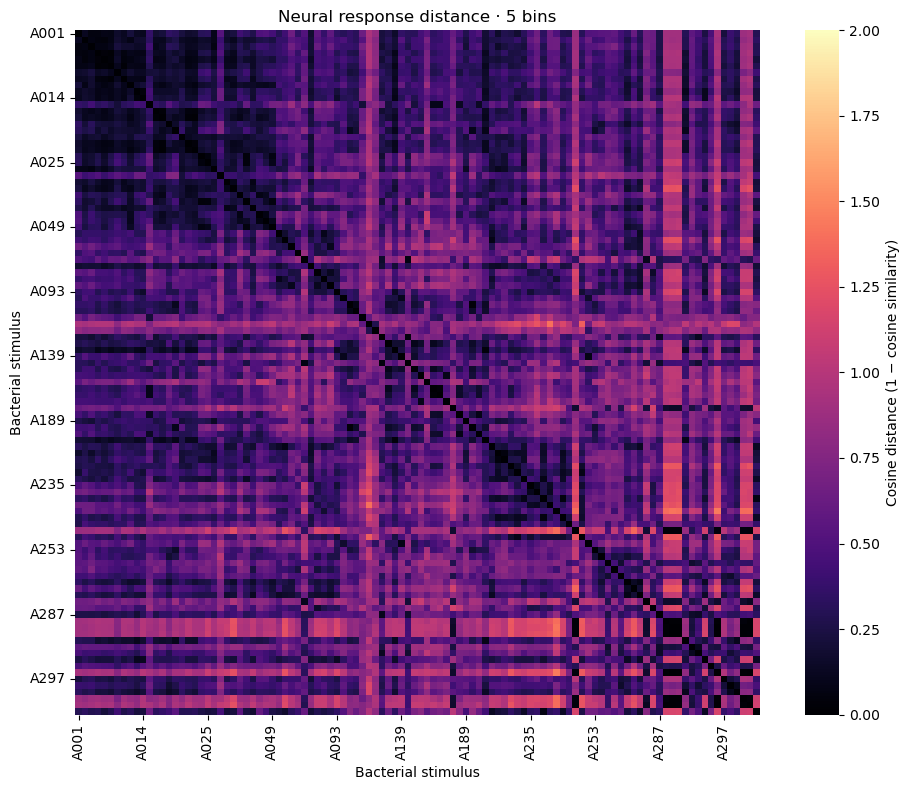

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.get_cmap("magma").copy()
ax.set_facecolor("#dddddd")

sns.heatmap(
    neural_rdm,
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=2,
    square=True,
    xticklabels=10,
    yticklabels=10,
    cbar_kws={"label": "Cosine distance (1 − cosine similarity)"},
)

ax.set(
    title=f"Neural response distance · {N_BINS} bins",
    xlabel="Bacterial stimulus",
    ylabel="Bacterial stimulus",
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Observation: 目前没有进行排序，菌种顺序间存在cluster，与以前的可视化结果相符

接下来是构建chemical RDM：保留单分子、有符号的 log₂FC，用 RMS 距离比较整个变化谱；不先做类别平均或 PCA 截断

In [53]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from IPython.display import display

# Cell 4: d(i,j) = sqrt(mean_k((log2FC[i,k] - log2FC[j,k])**2)).
# Rows: bacterial sample IDs. Columns: individual metabolites, equally weighted.
# None uses numerically valid features as an EXPLORATORY baseline, not verified QC.
# Replace with a fixed list of column names once reliable metabolites are identified.
RELIABLE_METABOLITES = None

CHEMICAL_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "data/matrix.xlsx").is_file()), None,
)
if CHEMICAL_ROOT is None:
    raise FileNotFoundError("Run this notebook inside the bacteria_analysis project")
CHEMICAL_PATH = CHEMICAL_ROOT / "data/matrix.xlsx"


def chemical_rms_distance(fold_changes, reliable_metabolites=None):
    """Return log2 profiles, RMS-distance RDM, and feature-selection audit.

    Select one fixed feature set across ALL supplied samples. No pairwise deletion,
    imputation, pseudocount, clipping, z-scoring, PCA, or class averaging.
    Numerical validity is separate from detection status, which FC alone cannot establish.
    """
    if fold_changes.empty:
        raise ValueError("The selected fold-change matrix is empty")
    if not fold_changes.index.is_unique or not fold_changes.columns.is_unique:
        raise ValueError("Sample IDs and metabolite names must be unique")
    numeric = fold_changes.apply(pd.to_numeric, errors="coerce").astype(float)
    values = numeric.to_numpy()
    finite = np.isfinite(values)
    valid = finite & (values > 0)
    if reliable_metabolites is None:
        requested = np.ones(len(numeric.columns), dtype=bool)
    else:
        if isinstance(reliable_metabolites, str):
            raise ValueError("Provide metabolite names as a list, not a single string")
        reliable_metabolites = list(reliable_metabolites)
        unknown = pd.Index(reliable_metabolites).difference(numeric.columns)
        if len(unknown):
            raise ValueError(f"Unknown metabolite names: {unknown.tolist()}")
        requested = numeric.columns.isin(reliable_metabolites)
    audit = pd.DataFrame(
        {
            "in_candidate_set": requested,
            "n_missing_or_non_numeric": numeric.isna().sum(axis=0).to_numpy(),
            "n_infinite": np.isinf(values).sum(axis=0),
            "n_nonpositive": (finite & (values <= 0)).sum(axis=0),
            "valid_in_all_samples": valid.all(axis=0),
        }, index=numeric.columns,
    )
    audit.index.name = "metabolite"
    audit["included"] = audit["in_candidate_set"] & audit["valid_in_all_samples"]
    selected = numeric.loc[:, audit["included"]]
    if selected.shape[1] == 0:
        raise ValueError("No candidate metabolites have positive, finite FC in every selected sample")
    profiles = np.log2(selected)
    # sqrt(sum of squared differences / p); avoids an n × n × p intermediate.
    distances = squareform(pdist(profiles.to_numpy(), metric="euclidean")) / np.sqrt(selected.shape[1])
    rdm = pd.DataFrame(distances, index=profiles.index, columns=profiles.index)
    rdm.attrs.update(
        distance="RMS difference of log2FC", n_features=profiles.shape[1],
        metabolites=profiles.columns.tolist(), sample_ids=profiles.index.tolist(),
        transform="log2 only", feature_weighting="equal per metabolite",
        feature_selection="Candidate set intersected with positive finite FC in every selected sample",
        reliability=("Unverified; numerical-validity-only exploratory baseline"
                     if reliable_metabolites is None else "User-specified reliable-metabolite list"),
        detection_status="Unknown from FC matrix alone; not inferred from numerical validity",
    )
    return profiles, rdm, audit


chemical_fc_all = pd.read_excel(CHEMICAL_PATH, sheet_name=0, index_col=0)
chemical_fc_all.index = chemical_fc_all.index.astype(str).str.strip()
chemical_fc_all.index.name = "sample_id"
chemical_fc_all.columns = chemical_fc_all.columns.astype(str).str.strip()
if not chemical_fc_all.index.is_unique or not chemical_fc_all.columns.is_unique:
    raise ValueError("Duplicate sample IDs or metabolite names in matrix.xlsx")
if not chemical_fc_all.index.str.fullmatch(r"A\d{3}").all():
    raise ValueError("Expected Axxx sample IDs in matrix.xlsx")

# Use the shared bacteria in neural-RDM order. This aligns IDs only; matching
# culture/stimulus conditions remains an experimental assumption to verify.
# Run the neural-distance cell first; no neural responses are recalculated here.
if "neural_rdm" not in globals():
    raise RuntimeError("Run the neural-distance cell first to define the bacterial sample set")
chemical_sample_ids = neural_rdm.index[neural_rdm.index.isin(chemical_fc_all.index)]
chemical_unmatched_neural_ids = neural_rdm.index[~neural_rdm.index.isin(chemical_fc_all.index)]
chemical_fc = chemical_fc_all.loc[chemical_sample_ids]
chemical_profiles, chemical_rdm, chemical_feature_audit = chemical_rms_distance(
    chemical_fc, RELIABLE_METABOLITES,
)
chemical_rdm.attrs.update(raw_file=str(CHEMICAL_PATH), sheet=0, sample_scope="Neural/chemical ID intersection")
neural_rdm_chemical = neural_rdm.loc[chemical_sample_ids, chemical_sample_ids].copy()

print(f"Chemical profiles: {chemical_profiles.shape} (bacteria × fixed metabolites)")
print(f"Chemical RDM: {chemical_rdm.shape}; units: log2FC; d=0 means identical profiles")
print(f"Excluded candidate features with invalid FC: "
      f"{(chemical_feature_audit['in_candidate_set'] & ~chemical_feature_audit['valid_in_all_samples']).sum()}")
print(f"Neural samples absent from chemical data: {chemical_unmatched_neural_ids.tolist()}")
print(f"Feature reliability: {chemical_rdm.attrs['reliability']}")
display(chemical_rdm.iloc[:5, :5])
display(chemical_feature_audit.loc[~chemical_feature_audit["included"]])


Chemical profiles: (106, 380) (bacteria × fixed metabolites)
Chemical RDM: (106, 106); units: log2FC; d=0 means identical profiles
Excluded candidate features with invalid FC: 0
Neural samples absent from chemical data: []
Feature reliability: Unverified; numerical-validity-only exploratory baseline


sample_id,A001,A002,A005,A006,A007
sample_id,,,,,
A001,0.000000,1.902656,2.364359,2.335983,2.797601
A002,1.902656,0.000000,2.105892,2.044412,2.783310
A005,2.364359,2.105892,0.000000,1.968539,2.248284
A006,2.335983,2.044412,1.968539,0.000000,2.486471
A007,2.797601,2.783310,2.248284,2.486471,0.000000


,in_candidate_set,n_missing_or_non_numeric,n_infinite,n_nonpositive,valid_in_all_samples,included
metabolite,,,,,,


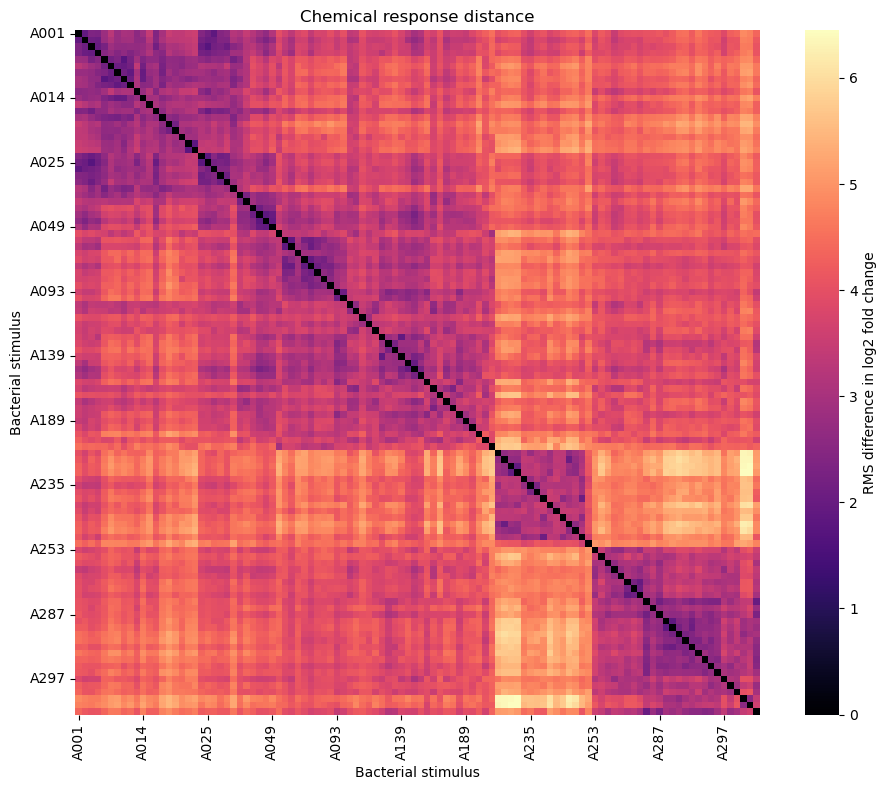

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preserve chemical_rdm's sample order, already aligned to the neural RDM.
# RMS log2FC distance is nonnegative and has no fixed upper bound.
CHEMICAL_VMAX = None  # None uses the observed maximum; set a value to fix the color scale.

fig_chemical, ax_chemical = plt.subplots(figsize=(10, 8))
ax_chemical.set_facecolor("#dddddd")  # Undefined distances, if present, appear gray.

sns.heatmap(
    chemical_rdm,
    ax=ax_chemical,
    cmap="magma",
    vmin=0,
    vmax=CHEMICAL_VMAX,
    square=True,
    xticklabels=10,
    yticklabels=10,
    cbar_kws={"label": "RMS difference in log2 fold change"},
)
ax_chemical.set(
    title="Chemical response distance",
    xlabel="Bacterial stimulus",
    ylabel="Bacterial stimulus",
)
ax_chemical.tick_params(axis="x", labelrotation=90)
ax_chemical.tick_params(axis="y", labelrotation=0)
fig_chemical.tight_layout()
plt.show()


目前构建了两个RDM：
| 数据 | 每株菌的表示                                    | 用于 embedding 的距离                                       |
| -- | ----------------------------------------- | ------------------------------------------------------ |
| 神经 | $13\times N_{bins}$ 维平均响应向量（当前 5 bins：65 维） $\mathbf x_i$ | $D^N_{ij}=\sqrt{2[1-\cos(\mathbf x_i,\mathbf x_j)]}$ |
| 化学 | 固定分子集合（当前仅检查数值有效性）的 log₂FC 向量 $\mathbf L_i$       | $D^C_{ij}=\sqrt{\frac1p\sum_k(L_{ik}-L_{jk})^2} $    |

对RDM 进行embedding可以固定为
$$
D^{N}_{ij}
=
\sqrt{2\left(1-\cos(\mathbf x_i,\mathbf x_j)\right)
},\qquad \mathbf x_i\in\mathbb R^{13\times N_{bins}},
$$
其中近零范数响应应单独处理，不能强行解释其方向相似性。

化学测使用前面讨论的可靠特征结合：

$$
D^{C}_{ij}
=
\sqrt{
\frac1p\sum_{k=1}^{p}(L_{ik}-L_{jk})^2
}.
$$

单看RDM其实不怎么像


# MDS 与 HMDS


对于Euclidean MDS，使用metric MDS：
寻找每株菌的低维坐标 $\mathbf z_i$，让坐标间欧氏距离尽量接近输入距离：
$$
\min_{\{\mathbf z_i\}}
\sum_{i<j}
\left[D_{ij}-\|\mathbf z_i-\mathbf z_j\|_2\right]^2.
$$

## MDS

,n_samples,n_pairs,raw_stress,relative_rmse,pearson_r,spearman_rho,best_n_iter,hit_max_iter
Neural,106,5565,424.605272,0.267424,0.840830,0.844691,403,False
Chemical,106,5565,7912.271504,0.297488,0.847531,0.845247,381,False


relative_rmse = sqrt(sum((embedded - input)^2) / sum(input^2)); smaller is better.
Distance correlations are descriptive; bacterial pairs are not independent replicates.
Colors summarize chemical PCo1 only; similar colors do not imply similar full chemical profiles.


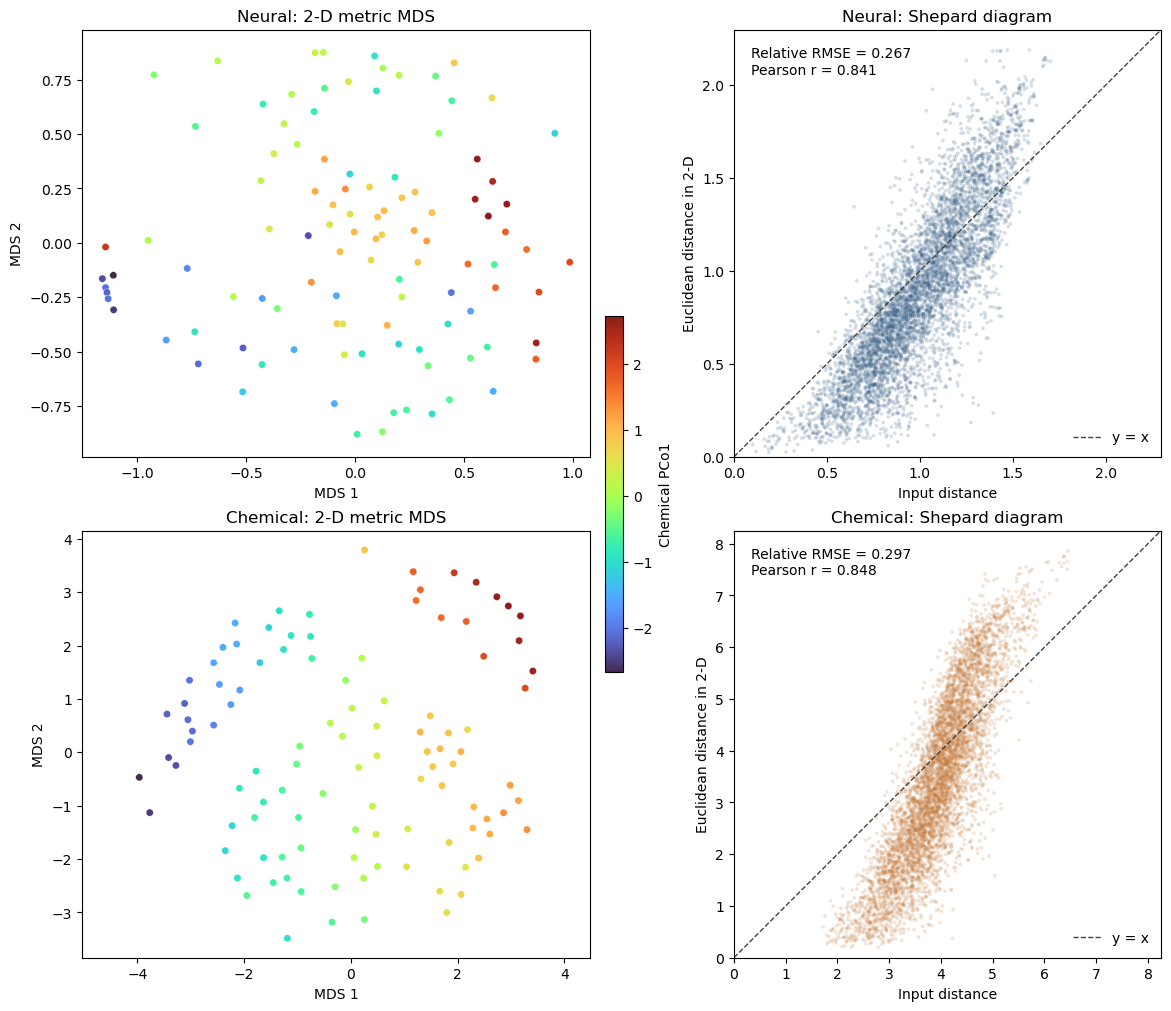

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
from sklearn.manifold import MDS
from IPython.display import display

# Two independent 2-D metric MDS fits on the same bacterial sample set.
MDS_SEED = 20260918
MDS_N_INIT = 16
MDS_MAX_ITER = 1000
MDS_EPS = 1e-9
MDS_LABEL_POINTS = False  # True labels every bacterium; may crowd a large atlas.
# Fixed chemical reference determines color; each embedding keeps its own distances.
from pathlib import Path
import sys
import importlib
color_root = next(root for root in (Path.cwd(), Path.cwd().parent)
                  if (root / 'notebook/chemical_colors.py').is_file())
if str(color_root / 'notebook') not in sys.path:
    sys.path.insert(0, str(color_root / 'notebook'))
import chemical_colors
importlib.reload(chemical_colors)
from chemical_colors import build_chemical_colors, mpl_colors, plotly_colors, mpl_colorbar_kwargs
if 'chemical_color_mapping' not in globals() or 'scores' not in chemical_color_mapping:
    if 'chemical_rdm' not in globals():
        raise RuntimeError('Run 化学 RDM 单元 then the color setup in 二维 MDS 单元 or 化学配色单元; no neural fit is needed')
    chemical_color_mapping = build_chemical_colors(chemical_rdm)
# Reuse this frozen mapping even when plotting a different RDM or sample order.
# Run 化学配色单元 explicitly to replace the reference or colormap.


def fit_metric_mds(rdm):
    """Fit a precomputed distance matrix; return model, coordinates, pairs, diagnostics."""
    if not rdm.index.is_unique or not rdm.index.equals(rdm.columns):
        raise ValueError("RDM rows and columns must contain identical, unique IDs in the same order")
    distances = rdm.to_numpy(dtype=float, copy=True)
    if len(distances) < 3:
        raise ValueError("At least three bacteria are required for this 2-D diagnostic")
    if not np.isfinite(distances).all():
        raise ValueError("MDS requires finite distances; inspect missing/zero-norm responses. No pairs are imputed")
    if (distances < -1e-12).any() or not np.allclose(distances, distances.T, atol=1e-12, rtol=0):
        raise ValueError("MDS requires nonnegative, symmetric distances")
    if not np.allclose(np.diag(distances), 0, atol=1e-12, rtol=0):
        raise ValueError("The RDM diagonal must be zero")
    # Correct floating-point roundoff only; retain off-diagonal zeros as real distances.
    distances = np.maximum((distances + distances.T) / 2, 0)
    np.fill_diagonal(distances, 0)
    upper = np.triu_indices(len(distances), k=1)
    target = distances[upper]
    if not np.any(target > 0):
        raise ValueError("All distances are zero; embedding diagnostics are undefined")
    # scikit-learn >= 1.8 API; optimize raw metric stress, with reproducible random starts.
    model = MDS(
        n_components=2, metric_mds=True, metric="precomputed",
        init="random", n_init=MDS_N_INIT, random_state=MDS_SEED,
        max_iter=MDS_MAX_ITER, eps=MDS_EPS, n_jobs=1, normalized_stress=False,
    )
    coordinates = pd.DataFrame(
        model.fit_transform(distances), index=rdm.index, columns=["MDS1", "MDS2"],
    )
    embedded = pdist(coordinates.to_numpy(), metric="euclidean")
    residual = embedded - target
    raw_stress = float(residual @ residual)  # Sum over i<j, excluding self-distances.
    # Explicit target-normalized RMS error; this is not sklearn's normalized Stress-1.
    relative_rmse = np.sqrt(raw_stress / (target @ target))
    variable = np.ptp(target) > 0 and np.ptp(embedded) > 0
    diagnostics = {
        "n_samples": len(rdm), "n_pairs": len(target), "raw_stress": raw_stress,
        "relative_rmse": relative_rmse,
        "pearson_r": np.corrcoef(target, embedded)[0, 1] if variable else np.nan,
        "spearman_rho": float(spearmanr(target, embedded).statistic) if variable else np.nan,
        "best_n_iter": model.n_iter_, "hit_max_iter": model.n_iter_ >= MDS_MAX_ITER,
    }
    pairs = pd.DataFrame({
        "sample_i": rdm.index.to_numpy()[upper[0]],
        "sample_j": rdm.index.to_numpy()[upper[1]],
        "input_distance": target, "embedded_distance": embedded, "residual": residual,
    })
    coordinates.attrs.update(
        method="2-D metric MDS", seed=MDS_SEED, n_init=MDS_N_INIT,
        max_iter=MDS_MAX_ITER, eps=MDS_EPS,
    )
    return model, coordinates, pairs, diagnostics


# Neural input is 1-cosine from 神经 RDM 单元; convert to the chord-distance expression
# defined above. Pair-specific missing-class masks do not guarantee Euclidean geometry.
mds_sample_ids = chemical_rdm.index
mds_neural_cosine = neural_rdm.loc[mds_sample_ids, mds_sample_ids]
if not np.isfinite(mds_neural_cosine.to_numpy()).all():
    raise ValueError("Neural RDM has undefined pairs; inspect response norms and shared-class coverage")
if (mds_neural_cosine.to_numpy() < 0).any() or (mds_neural_cosine.to_numpy() > 2).any():
    raise ValueError("Expected neural_rdm = 1 - cosine similarity, in [0, 2]")
mds_input_rdms = {
    "Neural": np.sqrt(2 * mds_neural_cosine),
    "Chemical": chemical_rdm.copy(),
}
mds_models, mds_coordinates, mds_shepard_pairs = {}, {}, {}
mds_diagnostics = {}
for name, rdm in mds_input_rdms.items():
    model, coordinates, pairs, diagnostics = fit_metric_mds(rdm)
    mds_models[name] = model
    mds_coordinates[name] = coordinates
    mds_shepard_pairs[name] = pairs
    mds_diagnostics[name] = diagnostics
mds_diagnostics = pd.DataFrame.from_dict(mds_diagnostics, orient="index")
display(mds_diagnostics)
print("relative_rmse = sqrt(sum((embedded - input)^2) / sum(input^2)); smaller is better.")
print("Distance correlations are descriptive; bacterial pairs are not independent replicates.")
if mds_diagnostics["hit_max_iter"].any():
    print("At least one best fit reached MDS_MAX_ITER; inspect convergence before interpreting it.")

fig_mds, axes_mds = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for row, (name, color) in enumerate((("Neural", "#325B84"), ("Chemical", "#C47839"))):
    coordinates, pairs = mds_coordinates[name], mds_shepard_pairs[name]
    ax_map, ax_shepard = axes_mds[row]
    mds_sample_scatter = ax_map.scatter(
        coordinates["MDS1"], coordinates["MDS2"], s=28, alpha=0.9,
        **mpl_colors(chemical_color_mapping, coordinates.index), edgecolors="white", linewidths=0.35,
    )
    if MDS_LABEL_POINTS:
        for sample, point in coordinates.iterrows():
            ax_map.annotate(sample, (point["MDS1"], point["MDS2"]), fontsize=6,
                            xytext=(3, 3), textcoords="offset points")
    ax_map.set(title=f"{name}: 2-D metric MDS", xlabel="MDS 1", ylabel="MDS 2")
    ax_map.set_aspect("equal", adjustable="datalim")
    ax_shepard.scatter(pairs["input_distance"], pairs["embedded_distance"],
                       s=7, alpha=0.2, color=color, edgecolors="none", rasterized=True)
    limit = 1.05 * pairs[["input_distance", "embedded_distance"]].to_numpy().max()
    ax_shepard.plot([0, limit], [0, limit], "--", color="#444444", linewidth=1, label="y = x")
    ax_shepard.set(
        title=f"{name}: Shepard diagram", xlabel="Input distance",
        ylabel="Euclidean distance in 2-D", xlim=(0, limit), ylim=(0, limit),
    )
    ax_shepard.set_aspect("equal", adjustable="box")
    ax_shepard.text(0.04, 0.96,
        f"Relative RMSE = {mds_diagnostics.loc[name, 'relative_rmse']:.3f}\n"
        f"Pearson r = {mds_diagnostics.loc[name, 'pearson_r']:.3f}",
        transform=ax_shepard.transAxes, va="top", fontsize=10,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
    )
    ax_shepard.legend(loc="lower right", frameon=False)
fig_mds.colorbar(
    mds_sample_scatter, ax=axes_mds[:, 0].tolist(), fraction=0.035, pad=0.03,
    **mpl_colorbar_kwargs(chemical_color_mapping),
)
print(chemical_color_mapping['note'])
plt.show()
# Axis orientation is arbitrary and fits are independent: matching visual orientation
# or apparent clusters is not a test of neural-chemical correspondence.


2D embedding的shepard diagram明显偏离y=x的线
尝试一下3D embedding

In [56]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Run 二维 MDS 单元 first: reuse its validated input distances, fitting settings and chemical reference colors.
# Only the embedding dimension changes; the 2-D fits and raw data remain untouched.
if "mds_input_rdms" not in globals() or "chemical_color_mapping" not in globals():
    raise RuntimeError("Run 二维 MDS 单元 first to prepare the distances and chemical reference color mapping")

mds3d_models, mds3d_coordinates, mds3d_shepard_pairs, mds3d_diagnostics = {}, {}, {}, {}
for name, rdm in mds_input_rdms.items():
    model3d = MDS(
        n_components=3, metric_mds=True, metric="precomputed",
        init="random", n_init=MDS_N_INIT, random_state=MDS_SEED,
        max_iter=MDS_MAX_ITER, eps=MDS_EPS, n_jobs=1, normalized_stress=False,
    )
    coordinates3d = pd.DataFrame(
        model3d.fit_transform(rdm.to_numpy(dtype=float, copy=True)),
        index=rdm.index, columns=["MDS1", "MDS2", "MDS3"],
    )
    coordinates3d.attrs.update(
        method="3-D metric MDS", seed=MDS_SEED, n_init=MDS_N_INIT,
        max_iter=MDS_MAX_ITER, eps=MDS_EPS,
    )
    upper3d = np.triu_indices(len(rdm), k=1)
    target3d = rdm.to_numpy()[upper3d]
    embedded3d = pdist(coordinates3d.to_numpy())
    residual3d = embedded3d - target3d
    stress3d = float(residual3d @ residual3d)
    mds3d_models[name] = model3d
    mds3d_coordinates[name] = coordinates3d
    mds3d_shepard_pairs[name] = pd.DataFrame({
        "sample_i": rdm.index.to_numpy()[upper3d[0]],
        "sample_j": rdm.index.to_numpy()[upper3d[1]],
        "input_distance": target3d, "embedded_distance": embedded3d,
        "residual": residual3d,
    })
    mds3d_diagnostics[name] = {
        "raw_stress": stress3d,
        "relative_rmse": np.sqrt(stress3d / (target3d @ target3d)),
        "best_n_iter": model3d.n_iter_, "hit_max_iter": model3d.n_iter_ >= MDS_MAX_ITER,
    }
mds3d_diagnostics = pd.DataFrame.from_dict(mds3d_diagnostics, orient="index")
mds_dimension_comparison = pd.concat(
    {"2D": mds_diagnostics[mds3d_diagnostics.columns], "3D": mds3d_diagnostics},
    names=["dimension", "representation"],
)
display(mds_dimension_comparison)
if mds3d_diagnostics["hit_max_iter"].any():
    print("A 3-D best fit reached MDS_MAX_ITER; inspect convergence before interpretation.")
print("Lower relative RMSE means better distance reconstruction, not evidence of a biological 3-D manifold.")

fig_mds3d = make_subplots(
    rows=2, cols=2, specs=[[{"type": "scene"}, {"type": "xy"}]] * 2,
    column_widths=[0.55, 0.45], horizontal_spacing=0.09, vertical_spacing=0.12,
    subplot_titles=("Neural: 3-D metric MDS", "Neural: Shepard diagram",
                    "Chemical: 3-D metric MDS", "Chemical: Shepard diagram"),
)
# Reuse the same fixed chemical PCo1 colors as the 2-D embedding.
for row, (name, pair_color) in enumerate((("Neural", "#325B84"), ("Chemical", "#C47839")), start=1):
    coords3d, pairs3d = mds3d_coordinates[name], mds3d_shepard_pairs[name]
    colors3d = plotly_colors(chemical_color_mapping, coords3d.index)
    colors3d.update(size=4, opacity=0.9, showscale=row == 2)
    colors3d['colorbar'].update(x=.48, len=.35, y=.2, thickness=12)
    fig_mds3d.add_trace(go.Scatter3d(
        x=coords3d["MDS1"], y=coords3d["MDS2"], z=coords3d["MDS3"],
        mode="markers", text=coords3d.index,
        customdata=chemical_color_mapping["scores"].reindex(coords3d.index).to_numpy(),
        marker=colors3d,
        hovertemplate="%{text}<br>Chemical PCo1: %{customdata:.3f}<br>MDS1: %{x:.3f}<br>MDS2: %{y:.3f}<br>MDS3: %{z:.3f}<extra></extra>",
        showlegend=False,
    ), row=row, col=1)
    fig_mds3d.update_scenes(
        xaxis_title="MDS 1", yaxis_title="MDS 2", zaxis_title="MDS 3",
        aspectmode="data", camera={"projection": {"type": "orthographic"}}, row=row, col=1,
    )
    fig_mds3d.add_trace(go.Scatter(
        x=pairs3d["input_distance"], y=pairs3d["embedded_distance"], mode="markers",
        marker={"size": 4, "color": pair_color, "opacity": 0.25},
        customdata=pairs3d[["sample_i", "sample_j"]].to_numpy(),
        hovertemplate="%{customdata[0]} / %{customdata[1]}<br>Input: %{x:.3f}<br>3-D: %{y:.3f}<extra></extra>",
        showlegend=False,
    ), row=row, col=2)
    limit3d = 1.05 * pairs3d[["input_distance", "embedded_distance"]].to_numpy().max()
    fig_mds3d.add_trace(go.Scatter(
        x=[0, limit3d], y=[0, limit3d], mode="lines", name="y = x",
        line={"color": "#444444", "dash": "dash", "width": 1},
        showlegend=False, hoverinfo="skip",
    ), row=row, col=2)
    fig_mds3d.update_xaxes(title_text="Input distance", range=[0, limit3d], row=row, col=2)
    fig_mds3d.update_yaxes(
        title_text="Euclidean distance in 3-D", range=[0, limit3d],
        scaleanchor="x" if row == 1 else "x2", scaleratio=1, row=row, col=2,
    )
    fig_mds3d.add_annotation(
        x=0.04 * limit3d, y=0.96 * limit3d, xanchor="left", showarrow=False,
        text=f"Relative RMSE = {mds3d_diagnostics.loc[name, 'relative_rmse']:.3f}",
        bgcolor="rgba(255,255,255,0.85)", row=row, col=2,
    )
fig_mds3d.update_layout(
    template="plotly_white", height=950, margin={"l": 15, "r": 25, "t": 60, "b": 30},
    title_text="3-D metric MDS · same continuous chemical reference colors as 2-D · hover for sample IDs",
)
print(chemical_color_mapping['note'])
fig_mds3d.show()


raw_stress  relative_rmse  best_n_iter  \
dimension representation                                            
2D        Neural           424.605272       0.267424          403   
          Chemical        7912.271504       0.297488          381   
3D        Neural           184.332024       0.176201          348   
          Chemical        4051.773021       0.212883         1000   

                          hit_max_iter  
dimension representation                
2D        Neural                 False  
          Chemical               False  
3D        Neural                 False  
          Chemical                True

A 3-D best fit reached MDS_MAX_ITER; inspect convergence before interpretation.
Lower relative RMSE means better distance reconstruction, not evidence of a biological 3-D manifold.
Colors summarize chemical PCo1 only; similar colors do not imply similar full chemical profiles.


拟合 2 到 20 维；每个维度尝试 16 组随机初始坐标，保留 stress 最小的结果。每组初始化最多优化 5000 次，收敛容差为 1e-9。


Neural:  2D finished in 1.36 s
Neural:  3D finished in 2.15 s
Neural:  4D finished in 2.08 s
Neural:  5D finished in 2.18 s
Neural:  6D finished in 3.24 s
Neural:  7D finished in 2.93 s
Neural:  8D finished in 2.90 s
Neural:  9D finished in 6.11 s
Neural: 10D finished in 6.63 s
Neural: 15D finished in 10.53 s
Neural: 20D finished in 8.87 s
Chemical:  2D finished in 1.81 s
Chemical:  3D finished in 4.15 s
Chemical:  4D finished in 7.92 s
Chemical:  5D finished in 7.58 s
Chemical:  6D finished in 11.18 s
Chemical:  7D finished in 13.94 s
Chemical:  8D finished in 12.45 s
Chemical:  9D finished in 13.59 s
Chemical: 10D finished in 13.85 s
Chemical: 15D finished in 15.39 s
Chemical: 20D finished in 15.40 s


raw_stress  relative_rmse  best_n_iter  \
representation dimension                                            
Neural         2           424.605272       0.267424          403   
               3           184.332024       0.176201          348   
               4            86.851783       0.120948          639   
               5            43.202741       0.085303          466   
               6            20.886625       0.059312          628   
               7            11.016134       0.043075          586   
               8             5.785775       0.031217         1122   
               9             3.673906       0.024876         1012   
               10            2.452742       0.020325         1385   
               15            0.484976       0.009038         3505   
               20            0.107102       0.004247         2686   
Chemical       2          7912.271504       0.297488          381   
               3          4051.188779       0.212868         1156   
               4          2477.189837       0.166455         3960   
               5          1660.890077       0.136298         2628   
               6          1173.363338       0.114560         4083   
               7           876.919205       0.099037         4880   
               8           674.669617       0.086869         2905   
               9           532.623065       0.077184         4701   
               10          428.285087       0.069213         3811   
               15          182.785030       0.045216         4317   
               20           95.302053       0.032649         4776   

                          hit_max_iter  elapsed_seconds  
representation dimension                                 
Neural         2                 False         1.357796  
               3                 False         2.151172  
               4                 False         2.082342  
               5                 False         2.177457  
               6                 False         3.238418  
               7                 False         2.931909  
               8                 False         2.898681  
               9                 False         6.109228  
               10                False         6.634886  
               15                False        10.533469  
               20                False         8.869468  
Chemical       2                 False         1.807463  
               3                 False         4.150725  
               4                 False         7.923846  
               5                 False         7.584315  
               6                 False        11.184720  
               7                 False        13.942868  
               8                 False        12.448581  
               9                 False        13.590466  
               10                False        13.845037  
               15                False        15.390462  
               20                False        15.395714

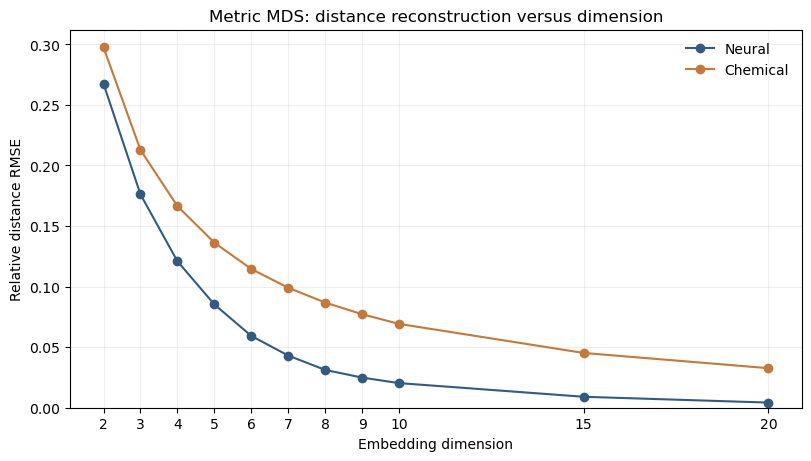

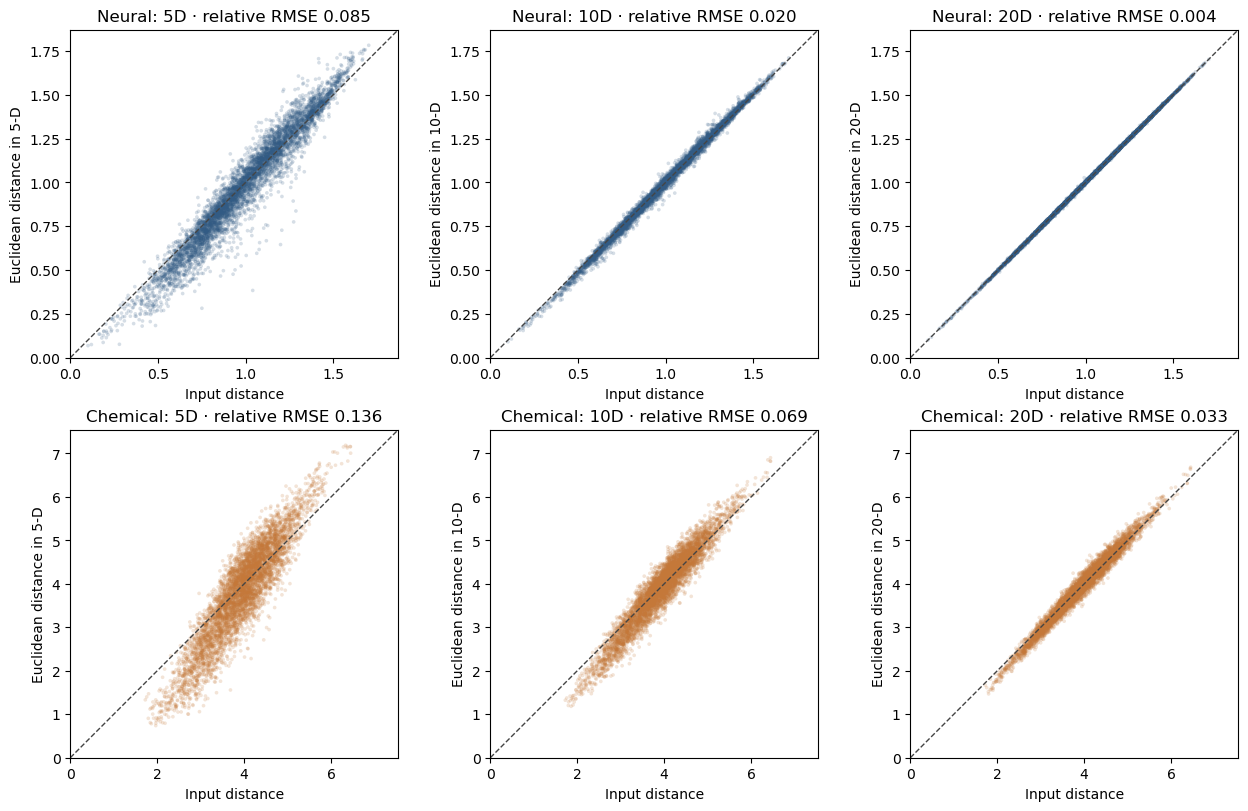

Compare distance reconstruction, not apparent clusters. Independent random fits can reach different local minima.


In [57]:
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from sklearn.manifold import MDS
from IPython.display import display

# Run 二维 MDS 单元 first. Refit every dimension with the same settings for comparison.
MDS_SWEEP_DIMS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
MDS_SWEEP_SHEPARD_DIMS = [5, 10, 20]
MDS_SWEEP_MAX_ITER = 5000  # The previous chemical 3-D fit reached 1000 iterations.
MDS_SWEEP_N_INIT = 16
MDS_SWEEP_SEED = 20260918
MDS_SWEEP_EPS = 1e-9

if "mds_input_rdms" not in globals():
    raise RuntimeError("Run 二维 MDS 单元 first to prepare the validated input distances")
mds_sweep_dims = sorted(set(MDS_SWEEP_DIMS))
max_dimension = min(len(rdm) - 1 for rdm in mds_input_rdms.values())
if not mds_sweep_dims or any(not isinstance(d, int) or not 1 <= d <= max_dimension for d in mds_sweep_dims):
    raise ValueError(f"MDS_SWEEP_DIMS must contain integers between 1 and {max_dimension}")
if not MDS_SWEEP_SHEPARD_DIMS or not set(MDS_SWEEP_SHEPARD_DIMS).issubset(mds_sweep_dims):
    raise ValueError("MDS_SWEEP_SHEPARD_DIMS must be a nonempty subset of MDS_SWEEP_DIMS")

mds_sweep_models, mds_sweep_coordinates, mds_sweep_distances = {}, {}, {}
mds_sweep_targets, mds_sweep_records = {}, []
for name, rdm in mds_input_rdms.items():
    values = rdm.to_numpy(dtype=float, copy=True)
    upper = np.triu_indices(len(rdm), k=1)
    target = values[upper]
    mds_sweep_targets[name] = target
    for dimension in mds_sweep_dims:
        started = perf_counter()
        model = MDS(
            n_components=dimension, metric_mds=True, metric="precomputed",
            init="random", n_init=MDS_SWEEP_N_INIT, random_state=MDS_SWEEP_SEED,
            max_iter=MDS_SWEEP_MAX_ITER, eps=MDS_SWEEP_EPS,
            n_jobs=1, normalized_stress=False,
        )
        coordinates = pd.DataFrame(
            model.fit_transform(values), index=rdm.index,
            columns=[f"MDS{k + 1}" for k in range(dimension)],
        )
        elapsed = perf_counter() - started
        coordinates.attrs.update(
            method="metric MDS", dimension=dimension, seed=MDS_SWEEP_SEED,
            n_init=MDS_SWEEP_N_INIT, max_iter=MDS_SWEEP_MAX_ITER, eps=MDS_SWEEP_EPS,
        )
        embedded = pdist(coordinates.to_numpy())
        residual = embedded - target
        stress = float(residual @ residual)
        mds_sweep_models[name, dimension] = model
        mds_sweep_coordinates[name, dimension] = coordinates
        mds_sweep_distances[name, dimension] = embedded
        mds_sweep_records.append({
            "representation": name, "dimension": dimension,
            "raw_stress": stress, "relative_rmse": np.sqrt(stress / (target @ target)),
            "best_n_iter": model.n_iter_, "hit_max_iter": model.n_iter_ >= MDS_SWEEP_MAX_ITER,
            "elapsed_seconds": elapsed,
        })
        print(f"{name}: {dimension:2d}D finished in {elapsed:.2f} s", flush=True)

mds_sweep_diagnostics = pd.DataFrame(mds_sweep_records).set_index(["representation", "dimension"])
display(mds_sweep_diagnostics)

# A smaller training reconstruction error does not validate an intrinsic biological dimension.
# All dimensions use the same pairs and denominator: sqrt(sum(residual**2) / sum(target**2)).
fig_mds_dimensions, ax_mds_dimensions = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
mds_sweep_colors = {"Neural": "#325B84", "Chemical": "#C47839"}
for name in mds_input_rdms:
    table = mds_sweep_diagnostics.loc[name]
    ax_mds_dimensions.plot(table.index, table["relative_rmse"], "o-",
                           color=mds_sweep_colors[name], label=name)
    capped = table["hit_max_iter"]
    if capped.any():
        ax_mds_dimensions.scatter(table.index[capped], table.loc[capped, "relative_rmse"],
                                  marker="x", s=110, color="crimson", zorder=5)
ax_mds_dimensions.set(
    xlabel="Embedding dimension", ylabel="Relative distance RMSE",
    title="Metric MDS: distance reconstruction versus dimension",
    xticks=mds_sweep_dims, ylim=(0, None),
)
ax_mds_dimensions.legend(frameon=False)
ax_mds_dimensions.grid(alpha=0.2)
plt.show()
if mds_sweep_diagnostics["hit_max_iter"].any():
    print("Red crosses mark best fits that reached the iteration limit; convergence needs inspection.")

fig_mds_high_shepard, axes_mds_high_shepard = plt.subplots(
    len(mds_input_rdms), len(MDS_SWEEP_SHEPARD_DIMS),
    figsize=(4.2 * len(MDS_SWEEP_SHEPARD_DIMS), 4 * len(mds_input_rdms)),
    squeeze=False, constrained_layout=True,
)
for row, name in enumerate(mds_input_rdms):
    target = mds_sweep_targets[name]
    # One scale per representation across dimensions; plot each unordered pair once.
    limit = 1.05 * max(target.max(), *(mds_sweep_distances[name, d].max() for d in MDS_SWEEP_SHEPARD_DIMS))
    for col, dimension in enumerate(MDS_SWEEP_SHEPARD_DIMS):
        ax = axes_mds_high_shepard[row, col]
        ax.scatter(target, mds_sweep_distances[name, dimension], s=7, alpha=0.2,
                   color=mds_sweep_colors[name], edgecolors="none", rasterized=True)
        ax.plot([0, limit], [0, limit], "--", color="#444444", linewidth=1)
        error = mds_sweep_diagnostics.loc[(name, dimension), "relative_rmse"]
        ax.set(title=f"{name}: {dimension}D · relative RMSE {error:.3f}",
               xlabel="Input distance", ylabel=f"Euclidean distance in {dimension}-D",
               xlim=(0, limit), ylim=(0, limit))
        ax.set_aspect("equal", adjustable="box")
plt.show()
print("Compare distance reconstruction, not apparent clusters. Independent random fits can reach different local minima.")


Observation: neural rdm euclidean 
MDS直到10维才与y=x相吻合
chemical MDS直到20维才与y=x相吻合

## 神经 HMDS

从当前神经 RDM 和 individual bootstrap 方差开始，依次完成二维拟合、三维拟合与绘图；默认流程不读取旧拟合存档。


### 神经 HMDS：完整计算过程

1. 运行神经 RDM 和化学 RDM 单元，定义当前响应表示及绘图颜色参考。
2. 运行 individual bootstrap，得到神经 chord distance `hmds_D`、距离方差 `hmds_V` 和有效菌株对 `hmds_pair_mask`。
3. 运行二维 HMDS：从当前 D/V 随机初始化，进行初始拟合、坐标尺度改进后的自由 λ 优化和局部扰动检查，验证收敛及数值梯度，保存本次结果并绘图。
4. 运行三维 HMDS：把本次二维结果提升到三维，优化全部自由坐标、λ 和额外残差方差，并验证／保存；随后运行三维绘图单元。

二维初始阶段使用 8 组随机起点，每组最多 3000 次迭代；`[0.05, 10]` 仅是初始阶段的 λ 边界。
后续优化允许任意正 λ，使用分阶段坐标尺度调整，并检查局部扰动后的解。所有设置在二维拟合单元开头可调。
本次从头运行不依赖旧二维结果或旧 λ profile 的根区间，非凸优化可能得到与历史存档不同的局部解。
检查失败时保留本次诊断和中间结果并报错，不自动使用旧结果替代。

神经输入为 `sqrt(2 * (1 - cosine))`。每对菌株的共享神经元集合在 bootstrap 前固定。
动物 `(date, worm_key)` 在日期内联合重采样，同一动物对不同菌株的记录共享抽样次数；日期本身不重采样。
`V_ij` 是距离的 bootstrap 样本方差（`ddof=1`，不再除以重采样次数），默认保留至少 80% draw 可计算的菌株对。

令 `S_ij = max(V_ij, variance_floor) + sigma_i**2 + sigma_j**2`，优化保留菌株对上的平均负对数复合似然：

```text
0.5 * [log(2*pi*S_ij) + (D_ij - hyperbolic_distance_ij/lambda)**2 / S_ij]
```

使用曲率 −1 的上半空间坐标与正尺度 λ。共用几何、二维完整拟合和梯度检查在 `neural_hmds.py`，改进优化器在 `hmds_refinement.py`。
坐标尺度调整不改变数据或似然。检查使用原参数单位下的投影梯度及数值导数；通过检查仍不证明全局最优。
该拟合使用距离方差的对角近似，不将共享动物或菌株的距离对当作独立生物学重复。
`sigma_i` 是额外模型残差，不是坐标置信区间；Poincaré 坐标仅用于显示，半径不代表生物学层级。
Shepard 图比较 `hyperbolic_distance/lambda` 与输入距离；重建误差不是交叉验证误差。


### 神经距离的individual bootstrap



In [76]:
import numpy as np
import pandas as pd
from IPython.display import display

# Neural HMDS: reuse the animal × (neuron class, bin) table from 神经 RDM 单元.
# One row is one (sample_id, date, worm_key); all bins/classes travel together.
HMDS_BOOTSTRAPS = 1000
HMDS_BOOT_SEED = 20260918
HMDS_MIN_VALID_FRACTION = 0.8  # Explicit coverage rule; inspect counts before interpretation.
HMDS_MIN_RESPONSE_NORM = 1e-12  # Numerical safeguard, not a biological response threshold.


def hmds_pair_chord(cube, pair_i, pair_j, shared, min_norm):
    """Chord distances on a FIXED class mask per pair; no bootstrap-specific feature deletion."""
    complete = np.isfinite(cube).all(axis=2)
    available = (~shared | (complete[pair_i] & complete[pair_j])).all(axis=1)
    first = np.where(shared[:, :, None], cube[pair_i], 0).reshape(len(pair_i), -1)
    second = np.where(shared[:, :, None], cube[pair_j], 0).reshape(len(pair_i), -1)
    norm_a, norm_b = np.linalg.norm(first, axis=1), np.linalg.norm(second, axis=1)
    valid = available & shared.any(axis=1) & (norm_a > min_norm) & (norm_b > min_norm)
    distances = np.full(len(pair_i), np.nan)
    cosine = np.sum(first[valid] * second[valid], axis=1) / (norm_a[valid] * norm_b[valid])
    distances[valid] = np.sqrt(2 * (1 - np.clip(cosine, -1, 1)))
    return distances


def hmds_bootstrap_distances(vectors, profiles, n_bootstraps, seed, date_weighting,
                             min_shared_classes, min_norm):
    """Joint animal bootstrap within dates; dates are fixed, not resampled.

    An animal measured with several bacteria has the SAME draw multiplicity for all
    of them. Feature means and date weighting match 神经 RDM 单元. For date-equal means,
    a bootstrap feature is undefined if an originally available date loses coverage.
    Variances are conditional on retained dates, preprocessing, and observed panels.
    """
    if n_bootstraps < 2 or date_weighting not in ("equal", "animal"):
        raise ValueError("Need at least two bootstraps and date_weighting='equal' or 'animal'")
    if not vectors.index.is_unique or not profiles.index.is_unique:
        raise ValueError("Animal rows and profile sample IDs must be unique")
    classes = profiles.columns.get_level_values("neuron_class").unique()
    bins = profiles.columns.get_level_values("time_bin").unique()
    columns = pd.MultiIndex.from_product([classes, bins], names=profiles.columns.names)
    if not profiles.columns.equals(columns):
        raise ValueError("Profile columns must be neuron class × bin in product order")
    if len(profiles) < 3:
        raise ValueError("HMDS requires at least three bacterial samples")
    selected = vectors.loc[vectors.index.get_level_values("sample_id").isin(profiles.index), columns]
    if set(selected.index.get_level_values("sample_id")) != set(profiles.index):
        raise ValueError("Some profiles have no animal vectors")
    data = selected.to_numpy(dtype=float)
    finite = np.isfinite(data)
    clean = np.where(finite, data, 0)
    frame = selected.index.to_frame(index=False)
    animal_codes, animals = pd.factorize(pd.MultiIndex.from_frame(frame[["date", "worm_key"]]))
    animals = animals.set_names(["date", "worm_key"])
    date_blocks = [np.flatnonzero(animals.get_level_values("date") == date)
                   for date in animals.get_level_values("date").unique()]
    groups = selected.groupby(level=["sample_id", "date"], sort=True).indices
    group_specs = [(profiles.index.get_loc(sample), rows) for (sample, date), rows in groups.items()]
    animal_counts = selected.groupby(level=["sample_id", "date"]).size().rename("n_animals")
    if (animal_counts < 2).any():
        raise ValueError("Some sample/date groups have <2 animals; their sampling variance is not estimable")

    def aggregate(weights):
        sums = np.zeros(profiles.shape)
        counts = np.zeros(profiles.shape)
        missing_date = np.zeros(profiles.shape, dtype=bool)
        for sample, rows in group_specs:
            multiplicity = weights[animal_codes[rows]]
            numerator = multiplicity @ clean[rows]
            denominator = multiplicity @ finite[rows]
            if date_weighting == "equal":
                present = denominator > 0
                sums[sample] += np.divide(numerator, denominator, out=np.zeros_like(numerator), where=present)
                counts[sample] += present
                missing_date[sample] |= finite[rows].any(axis=0) & ~present
            else:
                sums[sample] += numerator
                counts[sample] += denominator
        mean = np.divide(sums, counts, out=np.full(profiles.shape, np.nan), where=counts > 0)
        mean[missing_date] = np.nan
        return mean.reshape(len(profiles), len(classes), len(bins))

    original_cube = aggregate(np.ones(len(animals), dtype=int))
    if not np.allclose(original_cube.reshape(profiles.shape), profiles.to_numpy(), equal_nan=True):
        raise ValueError("Animal aggregation differs from neural_profiles; rerun 神经 RDM 单元 with current settings")
    pair_i, pair_j = np.triu_indices(len(profiles), k=1)
    complete = np.isfinite(original_cube).all(axis=2)
    shared = complete[pair_i] & complete[pair_j]
    enough_classes = shared.sum(axis=1) >= min_shared_classes
    original = hmds_pair_chord(original_cube, pair_i, pair_j, shared, min_norm)
    original[~enough_classes] = np.nan
    counts = np.zeros(len(pair_i), dtype=int)
    means, m2 = np.zeros(len(pair_i)), np.zeros(len(pair_i))
    rng = np.random.default_rng(seed)
    for iteration in range(n_bootstraps):
        weights = np.zeros(len(animals), dtype=int)
        for block in date_blocks:
            weights[block] = rng.multinomial(len(block), np.full(len(block), 1 / len(block)))
        draw = hmds_pair_chord(aggregate(weights), pair_i, pair_j, shared, min_norm)
        valid = np.isfinite(draw) & np.isfinite(original)
        counts[valid] += 1
        delta = draw[valid] - means[valid]
        means[valid] += delta / counts[valid]
        m2[valid] += delta * (draw[valid] - means[valid])
        if (iteration + 1) % 100 == 0:
            print(f"Animal bootstrap {iteration + 1}/{n_bootstraps}", flush=True)
    variance = np.divide(m2, counts - 1, out=np.full_like(m2, np.nan), where=counts > 1)
    means[counts == 0] = np.nan

    def square(values, diagonal):
        matrix = np.full((len(profiles), len(profiles)), np.nan)
        matrix[pair_i, pair_j] = matrix[pair_j, pair_i] = values
        np.fill_diagonal(matrix, diagonal)
        return pd.DataFrame(matrix, index=profiles.index, columns=profiles.index)

    return {
        "distance": square(original, 0), "variance": square(variance, 0),
        "valid_bootstraps": square(counts, n_bootstraps).astype(int),
        "bootstrap_mean": square(means, 0), "shared_classes": square(shared.sum(axis=1), complete.sum(axis=1)),
        "animal_counts": animal_counts,
    }


if "neural_vectors" not in globals() or "neural_profiles" not in globals():
    raise RuntimeError("Run 神经 RDM 单元 first; the bootstrap does not reload or modify raw data")
hmds_bootstrap = hmds_bootstrap_distances(
    neural_vectors, neural_profiles, HMDS_BOOTSTRAPS, HMDS_BOOT_SEED,
    DATE_WEIGHTING, MIN_SHARED_CLASSES, HMDS_MIN_RESPONSE_NORM,
)
hmds_D = hmds_bootstrap["distance"]  # Observed distance, NOT the mean of bootstrap distances.
hmds_V = hmds_bootstrap["variance"]  # Bootstrap sample variance (ddof=1), not divided by B.
hmds_bootstrap_counts = hmds_bootstrap["valid_bootstraps"]
if not 0 < HMDS_MIN_VALID_FRACTION <= 1:
    raise ValueError("HMDS_MIN_VALID_FRACTION must be in (0, 1]")
hmds_pair_mask = (
    np.isfinite(hmds_D) & np.isfinite(hmds_V)
    & (hmds_bootstrap_counts >= max(2, int(np.ceil(HMDS_BOOTSTRAPS * HMDS_MIN_VALID_FRACTION))))
)
np.fill_diagonal(hmds_pair_mask.values, False)
hmds_upper = np.triu_indices(len(hmds_D), k=1)
hmds_bootstrap_parameters = {
    "n_bootstraps": HMDS_BOOTSTRAPS, "seed": HMDS_BOOT_SEED,
    "sampling_unit": "(date, worm_key); joint across stimuli; stratified by fixed date",
    "date_weighting": DATE_WEIGHTING, "features": neural_profiles.columns.tolist(),
    "distance": "sqrt(2 * (1 - cosine)); original pair-specific class mask held fixed",
    "min_valid_fraction": HMDS_MIN_VALID_FRACTION, "min_response_norm": HMDS_MIN_RESPONSE_NORM,
    "min_shared_classes": MIN_SHARED_CLASSES, "neural_provenance": neural_rdm.attrs.copy(),
}
print(f"Pairs retained: {hmds_pair_mask.to_numpy()[hmds_upper].sum()}/{len(hmds_upper[0])}")
print("Excluded pairs are not imputed; their bootstrap coverage remains available for inspection.")
display(hmds_bootstrap["animal_counts"].describe(),
        pd.Series(hmds_bootstrap_counts.to_numpy()[hmds_upper], name="valid_bootstraps").describe())


Animal bootstrap 100/1000
Animal bootstrap 200/1000
Animal bootstrap 300/1000
Animal bootstrap 400/1000
Animal bootstrap 500/1000
Animal bootstrap 600/1000
Animal bootstrap 700/1000
Animal bootstrap 800/1000
Animal bootstrap 900/1000
Animal bootstrap 1000/1000
Pairs retained: 5253/5565
Excluded pairs are not imputed; their bootstrap coverage remains available for inspection.


count    112.000000
mean       5.419643
std        1.070812
min        4.000000
25%        5.000000
50%        5.000000
75%        6.000000
max        7.000000
Name: n_animals, dtype: float64

count    5565.000000
mean      939.220485
std        74.396356
min       779.000000
25%       933.000000
50%       969.000000
75%       996.000000
max      1000.000000
Name: valid_bootstraps, dtype: float64

### 神经 HMDS：完整二维拟合与绘图

从当前神经距离 D 和 individual-bootstrap 方差 V 开始：随机初始化 → 固定 λ 拟合其余参数 → 自适应搜索 λ → 局部扰动检查 → 全参数梯度验证 → 保存与绘图。阶段之间通过保持距离的等距变换重整坐标尺度。

每个 λ 的条件拟合必须收敛，最终判据包含 λ 本身的梯度；不读取历史拟合。`MAX_BLOCKS` 是每次条件拟合的预算，每五个 block 重新选择坐标锚点。未收敛的扰动尝试保留诊断记录，不参与最终选择。结果是通过检查的局部解，不保证全局最优。


h:\Process_temporary\WJH\bacteria_analysis\.pixi\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


HMDS start 1/8 (random): loss=-0.41250, projected gradient=8.83e-02, success=False
HMDS start 2/8 (random): loss=-0.41113, projected gradient=1.30e-04, success=False
HMDS start 3/8 (random): loss=-0.38589, projected gradient=1.62e-02, success=False
HMDS start 4/8 (random): loss=-0.12718, projected gradient=1.05e-03, success=False
HMDS start 5/8 (random): loss=-0.07549, projected gradient=2.88e-02, success=False
HMDS start 6/8 (random): loss=-0.02936, projected gradient=3.07e-03, success=False
HMDS start 7/8 (random): loss=-0.02534, projected gradient=2.28e-05, success=False
HMDS start 8/8 (random): loss=0.05681, projected gradient=7.07e-05, success=False
2D initial: conditioning and lambda profile
2D conditional lambda=10 block=1: loss=-0.594594451, lambda=10, original gradient=0.00323, local gradient=9.53e-05
2D conditional lambda=10 block=2: loss=-0.595821347, lambda=10, original gradient=1.81e-07, local gradient=1.63e-08
2D conditional lambda=10 block=3: loss=-0.595821347, lambda=10

,run,kind,seed,amplitude,mean_nll,lambda_value,relative_rmse,projected_gradient,converged,stop_reason
0,0,initial_refinement,20260918,0.0,-0.656131,17.785874,0.134644,1.401530e-08,True,profile stationary point; full projected gradi...
1,1,local_perturbation,20260930,0.0,-0.656131,17.785874,0.134644,1.401490e-08,True,profile stationary point; full projected gradi...
2,2,local_perturbation,20260931,0.1,-0.656131,17.785874,0.134644,4.063578e-08,True,profile stationary point; full projected gradi...
3,3,local_perturbation,20260932,0.3,-0.656131,17.785866,0.134644,4.492983e-09,True,profile stationary point; full projected gradi...
4,4,local_perturbation,20260933,0.7,-0.656131,17.785882,0.134644,8.448926e-09,True,profile stationary point; full projected gradi...


,result
n_samples,106
n_pairs,5253
dimension,2
lambda,17.785882
mean_nll,-0.656131
relative_rmse_initial,0.177834
relative_rmse_final,0.134644
joint_projected_gradient,0.0
joint_gradient_converged,True
gradient_parameters_checked,317


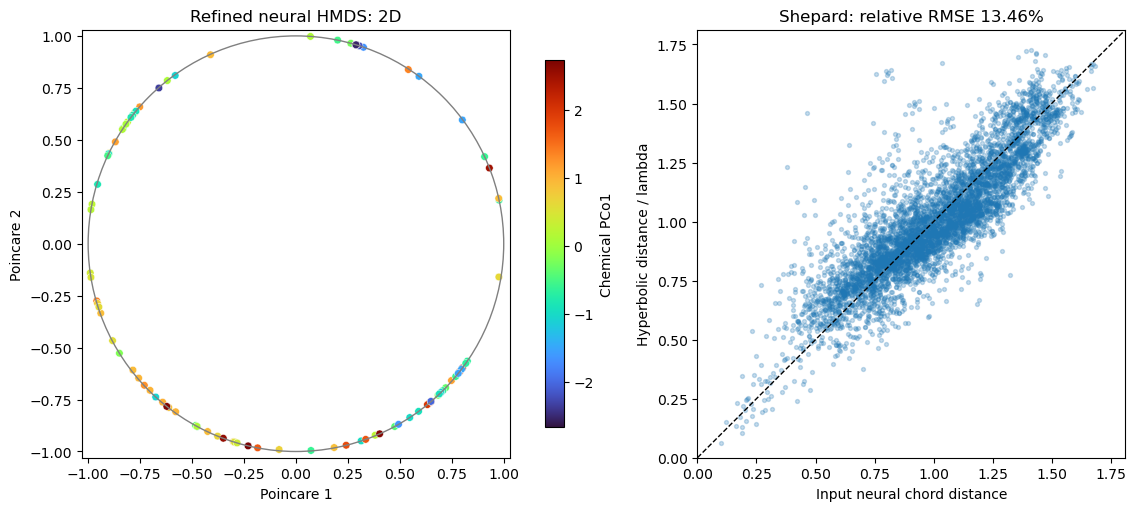

Colors summarize chemical PCo1 only; similar colors do not imply similar full chemical profiles.
本次二维模型从当前 D/V 随机初始化并完成拟合；未读取历史拟合。
已通过收敛和梯度检查；仍是局部解，不保证与历史存档相同或全局最优。
sigma 表示额外模型残差，不是坐标不确定性。Saved: h:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\neural_hmds_2d_20260922_163227_089663


In [78]:
from pathlib import Path
from datetime import datetime
import json
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Fit current inputs: random starts -> conditional fits -> lambda profile -> checks.
# MAX_BLOCKS is the budget PER conditional fit; reanchor every five blocks.
# The initial lambda bounds do not constrain the final estimated lambda.
HMDS2D_N_STARTS = 8
HMDS2D_SEED = 20260918
HMDS2D_INITIAL_MAX_ITER = 3000
HMDS2D_INITIAL_LAMBDA_BOUNDS = (0.05, 10.0)
HMDS2D_VARIANCE_FLOOR = 1e-10
HMDS2D_MAX_BLOCKS = 30
HMDS2D_ITERATIONS_PER_BLOCK = 2000
HMDS2D_MAX_PROFILE_STEPS = 30  # Numerical search budget; not a bound on lambda.
HMDS2D_GRADIENT_TOLERANCE = 1e-6
HMDS2D_PERTURB_AMPLITUDES = (0.0, 0.1, 0.3, 0.7)
HMDS2D_PERTURB_SEED = 20260930
HMDS2D_FISHER_RIDGE = 1e-7  # Optimizer scaling only; not a scientific penalty.

# Clear downstream state before any work: a failed new fit must not reuse old results.
hmds_refined_bundle = None
hmds_3d_bundle = None
hmds_3d_directory = None
required = ('hmds_D', 'hmds_V', 'hmds_pair_mask', 'hmds_bootstrap_parameters', 'chemical_rdm')
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f'Run the neural/chemical RDM and individual bootstrap cells first: {missing}')

hmds_project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)
                         if (p / 'notebook/neural_hmds.py').is_file())
if str(hmds_project_root / 'notebook') not in sys.path:
    sys.path.insert(0, str(hmds_project_root / 'notebook'))
import neural_hmds
import hmds_refinement
import chemical_colors
importlib.reload(neural_hmds)
importlib.reload(hmds_refinement)
importlib.reload(chemical_colors)
from chemical_colors import build_chemical_colors, mpl_colors, mpl_colorbar_kwargs
if 'chemical_color_mapping' not in globals() or 'scores' not in chemical_color_mapping:
    chemical_color_mapping = build_chemical_colors(chemical_rdm)

HMDS2D_OUTPUT_DIR = hmds_project_root / 'output/jupyter-notebook' / (
    'neural_hmds_2d_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f')
)
hmds_refined_bundle = neural_hmds.fit_neural_hmds_2d(
    hmds_D, hmds_V, hmds_pair_mask, hmds_bootstrap_parameters, HMDS2D_OUTPUT_DIR,
    n_starts=HMDS2D_N_STARTS, seed=HMDS2D_SEED,
    initial_max_iter=HMDS2D_INITIAL_MAX_ITER,
    initial_lambda_bounds=HMDS2D_INITIAL_LAMBDA_BOUNDS, variance_floor=HMDS2D_VARIANCE_FLOOR,
    max_blocks=HMDS2D_MAX_BLOCKS, iterations_per_block=HMDS2D_ITERATIONS_PER_BLOCK,
    gradient_tolerance=HMDS2D_GRADIENT_TOLERANCE,
    perturb_amplitudes=HMDS2D_PERTURB_AMPLITUDES, perturb_seed=HMDS2D_PERTURB_SEED,
    ridge_fraction=HMDS2D_FISHER_RIDGE, max_profile_steps=HMDS2D_MAX_PROFILE_STEPS,
)
hmds_refined_fit = hmds_refined_bundle['fit']
hmds_refined_reference = hmds_refined_bundle['reference']
hmds_refined_report = hmds_refined_bundle['report']
hmds_refined_coordinates = hmds_refined_fit['display_coordinates']
hmds_refined_summary = pd.Series({
    'n_samples': hmds_refined_report['n_samples'],
    'n_pairs': hmds_refined_report['n_pairs'],
    'dimension': 2,
    'lambda': hmds_refined_fit['diagnostics']['lambda_value'],
    'mean_nll': hmds_refined_fit['diagnostics']['mean_nll'],
    'relative_rmse_initial': hmds_refined_report['before']['relative_rmse'],
    'relative_rmse_final': hmds_refined_fit['diagnostics']['relative_rmse'],
    'joint_projected_gradient': hmds_refined_fit['diagnostics']['joint_projected_grad_inf'],
    'joint_gradient_converged': hmds_refined_fit['diagnostics']['joint_gradient_converged'],
    'gradient_parameters_checked': hmds_refined_report['gradient_checks']['checked_parameters'],
    'all_gradient_checks_passed': hmds_refined_report['gradient_checks']['all_passed'],
})
display(hmds_refined_bundle['runs'], hmds_refined_summary.to_frame('result'))
fig_refined, (ax_map, ax_pairs) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
refined_scatter = ax_map.scatter(*hmds_refined_coordinates.to_numpy().T,
                                **mpl_colors(chemical_color_mapping, hmds_refined_coordinates.index),
                                s=30, edgecolors='white', linewidths=.35)
ax_map.add_patch(plt.Circle((0, 0), 1, fill=False, color='gray'))
ax_map.set(xlim=(-1.03, 1.03), ylim=(-1.03, 1.03), aspect='equal',
           xlabel='Poincare 1', ylabel='Poincare 2', title='Refined neural HMDS: 2D')
fig_refined.colorbar(refined_scatter, ax=ax_map, **mpl_colorbar_kwargs(chemical_color_mapping), fraction=.035)
refined_pairs = hmds_refined_fit['pairs']
ax_pairs.scatter(refined_pairs.input_distance, refined_pairs.fitted_distance, s=8, alpha=.25)
refined_limit = refined_pairs[['input_distance', 'fitted_distance']].to_numpy().max() * 1.05
ax_pairs.plot([0, refined_limit], [0, refined_limit], 'k--', lw=1)
ax_pairs.set(xlim=(0, refined_limit), ylim=(0, refined_limit), aspect='equal',
             xlabel='Input neural chord distance', ylabel='Hyperbolic distance / lambda',
             title=f"Shepard: relative RMSE {hmds_refined_fit['diagnostics']['relative_rmse']:.2%}")
plt.show()
print(chemical_color_mapping['note'])
fig_refined.savefig(HMDS2D_OUTPUT_DIR / 'neural_hmds_2d.png', dpi=160)
chemical_colors.save_chemical_colors(chemical_color_mapping, HMDS2D_OUTPUT_DIR / 'color_reference')
saved_notebook = json.loads((hmds_project_root / 'notebook/03_chemical_neuron_bacteria.ipynb').read_text(encoding='utf-8'))
source_snapshot = next(cell['source'] for cell in saved_notebook['cells'] if cell.get('id') == '3da12cb4')
(HMDS2D_OUTPUT_DIR / 'neural_hmds_2d_generation.py').write_text(''.join(source_snapshot), encoding='utf-8')
print('本次二维模型从当前 D/V 随机初始化并完成拟合；未读取历史拟合。')
print('已通过收敛和梯度检查；仍是局部解，不保证与历史存档相同或全局最优。')
print('sigma 表示额外模型残差，不是坐标不确定性。Saved:', HMDS2D_OUTPUT_DIR)


### 神经 HMDS：从本次二维结果拟合三维模型

先完成 individual bootstrap 和上面的二维拟合；本单元提升本次二维结果到三维并重新优化。


In [79]:
# Recompute the complete 3D fit from 动物 bootstrap 单元 inputs; 二维神经 HMDS 结果单元 supplies the 2D warm start.
# Does NOT load any existing 3D fit or rerun bootstrap. Run 三维神经 HMDS 结果单元 afterwards to view it.
from pathlib import Path
from datetime import datetime
import pickle
from IPython.display import display

HMDS3D_START_AMPLITUDES = (0.1, 0.3, 0.7)
HMDS3D_START_SEED = 20260919
HMDS3D_PERTURB_AMPLITUDES = (0.0, 0.1, 0.3, 0.7)
HMDS3D_PERTURB_SEED = 20260930
HMDS3D_MAX_BLOCKS = 20
HMDS3D_ITERATIONS_PER_BLOCK = 1000
HMDS3D_GRADIENT_TOLERANCE = 1e-6  # Original parameter-unit convergence criterion.
HMDS3D_PERTURB_GRADIENT_TOLERANCE = 1e-7
HMDS3D_FISHER_RIDGE = 1e-7  # Optimizer scaling only; no penalty in the loss.

hmds_3d_project_root = next(
    p for p in (Path.cwd(), Path.cwd().parent)
    if (p / 'notebook/03_chemical_neuron_bacteria.ipynb').is_file()
)
# Clear prior 3D state; publish new state only after a successful fit.
hmds_3d_bundle = None
hmds_3d_directory = None
# Each execution has its own directory and preserves previous results.
HMDS3D_OUTPUT_DIR = hmds_3d_project_root / 'output/jupyter-notebook' / (
    'neural_hmds_3d_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f')
)


def generate_neural_hmds_3d(distance, variance, pair_mask, baseline_bundle,
                           bootstrap_parameters, project_root, output_directory, color_mapping):
    """Fit 3D coordinates, lambda and extra residual variance, check, then save.

    Inputs: aligned sample x sample DataFrames from 动物 bootstrap 单元, and the checked 2D
    bundle from 二维神经 HMDS 结果单元. The 2D input must describe exactly the same retained pairs.
    Lambda is free and positive; sample residual variances q are constrained >= 0.
    Failed convergence/gradient checks stop before publishing the final bundle.
    """
    import copy
    import hashlib
    import json
    import sys
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    from scipy.optimize import minimize
    from threadpoolctl import threadpool_limits

    ROOT, OUT = Path(project_root), Path(output_directory)
    if str(ROOT / 'notebook') not in sys.path:
        sys.path.insert(0, str(ROOT / 'notebook'))
    # A long-lived kernel may still cache the earlier 2D-only module.
    import importlib
    import hmds_refinement
    hmds_refinement = importlib.reload(hmds_refinement)
    reanchor_hmds, refine_hmds = hmds_refinement.reanchor_hmds, hmds_refinement.refine_hmds

    # Shared functions are independent of notebook ordering and historical fits.
    import neural_hmds
    neural_hmds = importlib.reload(neural_hmds)

    # Validate by sample labels, because the numerical anchor may reorder samples.
    if not isinstance(distance, pd.DataFrame) or not distance.index.is_unique:
        raise ValueError('distance must be a DataFrame with unique sample IDs')
    for matrix in (distance, variance, pair_mask):
        if not matrix.index.equals(distance.index) or not matrix.columns.equals(distance.index):
            raise ValueError('Distance, variance and mask must have identical row/column labels')
        if not np.allclose(matrix.to_numpy(), matrix.to_numpy().T, equal_nan=True):
            raise ValueError('Distance, variance and mask must be symmetric')
    if not all(pd.api.types.is_bool_dtype(dtype) for dtype in pair_mask.dtypes):
        raise ValueError('pair_mask must contain booleans')
    if np.diag(pair_mask.to_numpy()).any():
        raise ValueError('pair_mask diagonal must be False')
    if not isinstance(baseline_bundle, dict) or not baseline_bundle['fit']['diagnostics'].get('joint_gradient_converged', False):
        raise ValueError('Complete the current 2D fit and its convergence checks before the 3D fit')
    baseline = copy.deepcopy(baseline_bundle['fit'])
    baseref = copy.deepcopy(baseline_bundle['reference'])
    ids = baseref['coordinates'].index
    n = len(ids)
    if set(ids) != set(distance.index) or baseline['halfspace_coordinates'].shape != (n, 2):
        raise ValueError('The 2D warm start must contain the same samples in two dimensions')
    if not baseline['coordinates'].index.equals(ids):
        raise ValueError('The 2D fit and reference have different coordinate row order')
    observations = ['sample_i', 'sample_j', 'input_distance', 'bootstrap_variance']
    input_pairs = baseref['pairs'][observations].copy()
    ii = distance.index.get_indexer(input_pairs.sample_i)
    jj = distance.index.get_indexer(input_pairs.sample_j)
    retained = pair_mask.to_numpy()[ii, jj]
    if (ii < 0).any() or (jj < 0).any() or not retained.all():
        raise ValueError('The warm start contains absent or excluded pairs')
    if len(input_pairs) != np.triu(pair_mask.to_numpy(), 1).sum():
        raise ValueError('The current mask differs from the 2D warm start; update 二维神经 HMDS 结果单元 first')
    current = np.column_stack([distance.to_numpy()[ii, jj], variance.to_numpy()[ii, jj]])
    if not np.isfinite(current).all() or (current < 0).any():
        raise ValueError('Retained distances and variances must be finite and nonnegative')
    if not np.array_equal(current, input_pairs[['input_distance', 'bootstrap_variance']].to_numpy()):
        raise ValueError('Current 动物 bootstrap 单元 inputs differ from the 2D warm start; update that fit first')
    input_pairs[['input_distance', 'bootstrap_variance']] = current
    baseref['pairs'] = input_pairs
    baseref['parameters'].update(dimension=3, fixed_lambda=None,
                                 lambda_bounds=(0.0, np.inf), bootstrap=copy.deepcopy(bootstrap_parameters))
    if not HMDS3D_START_AMPLITUDES or not HMDS3D_PERTURB_AMPLITUDES:
        raise ValueError('At least one initial fit and one refinement are required')
    OUT.mkdir(parents=True, exist_ok=False)
    config = dict(start_amplitudes=HMDS3D_START_AMPLITUDES, start_seed=HMDS3D_START_SEED,
                  perturb_amplitudes=HMDS3D_PERTURB_AMPLITUDES, perturb_seed=HMDS3D_PERTURB_SEED,
                  max_blocks=HMDS3D_MAX_BLOCKS, iterations_per_block=HMDS3D_ITERATIONS_PER_BLOCK,
                  gradient_tolerance=HMDS3D_GRADIENT_TOLERANCE,
                  perturb_gradient_tolerance=HMDS3D_PERTURB_GRADIENT_TOLERANCE,
                  fisher_ridge=HMDS3D_FISHER_RIDGE)
    (OUT / 'configuration.json').write_text(json.dumps(config, indent=2), encoding='utf-8')
    (OUT / 'neural_hmds_used.py').write_bytes(Path(neural_hmds.__file__).read_bytes())
    # Archive source by persistent cell ID; insertion/reordering does not change it.
    saved_notebook = json.loads((ROOT / 'notebook/03_chemical_neuron_bacteria.ipynb').read_text(encoding='utf-8'))
    generation_source = next(cell['source'] for cell in saved_notebook['cells']
                             if cell.get('id') == 'a27d4d59')
    (OUT / 'neural_hmds_3d_generation.py').write_text(''.join(generation_source), encoding='utf-8')
    (OUT / 'hmds_refinement_used.py').write_bytes((ROOT / 'notebook/hmds_refinement.py').read_bytes())
    with (OUT / 'input_snapshot.pkl').open('wb') as handle:
        pickle.dump(dict(distance=distance, variance=variance, pair_mask=pair_mask,
                         baseline_bundle=baseline_bundle, bootstrap_parameters=bootstrap_parameters), handle)

    def run_fit(reference, label, tolerance):
        return refine_hmds(
            reference, neural_hmds.hmds_geometry, neural_hmds.hmds_loss_gradient, neural_hmds.hmds_projected_gradient,
            fixed_lambda=None, max_blocks=HMDS3D_MAX_BLOCKS,
            iterations_per_block=HMDS3D_ITERATIONS_PER_BLOCK,
            ridge_fraction=HMDS3D_FISHER_RIDGE, gradient_tolerance=tolerance,
            label=label, verbose=True,
        )

    starts, repeats = [], []
    with threadpool_limits(limits=1, user_api='blas'):
        # Lift the 2D solution into 3D, then optimize ALL non-anchor coordinates.
        for start, amplitude in enumerate(HMDS3D_START_AMPLITUDES):
            seed = HMDS3D_START_SEED + start
            rng = np.random.default_rng(seed)
            original_chart = baseline['halfspace_coordinates']
            chart = np.column_stack([original_chart[:, 0],
                np.exp(original_chart[:, -1]) * rng.normal(size=n) * amplitude,
                original_chart[:, -1]])
            chart[0] = 0
            ref = copy.deepcopy(baseref)
            ref['coordinates'] = pd.DataFrame(neural_hmds.hmds_chart_to_ball(chart), index=ids,
                                              columns=['Poincare1', 'Poincare2', 'Poincare3'])
            old_nc = (n - 1) * 2
            x = np.r_[chart[1:].ravel(), baseline['parameters_vector'][old_nc:]]
            ref['optimizer_result'].x = x
            ref = reanchor_hmds(ref, x, neural_hmds.hmds_geometry, neural_hmds.hmds_loss_gradient)
            fit = run_fit(ref, f'3D start {start + 1}/{len(HMDS3D_START_AMPLITUDES)}',
                          HMDS3D_GRADIENT_TOLERANCE)
            starts.append(dict(start=start, seed=seed, amplitude=amplitude, reference=ref, fit=fit))
            (OUT / 'multistart_results.pkl').write_bytes(pickle.dumps(starts))

        best_start = min(starts, key=lambda record: record['fit']['diagnostics']['mean_nll'])
        for start, amplitude in enumerate(HMDS3D_PERTURB_AMPLITUDES):
            seed = HMDS3D_PERTURB_SEED + start
            rng = np.random.default_rng(seed)
            ref = copy.deepcopy(best_start['reference'])
            x = best_start['fit']['parameters_vector'].copy()
            chart = best_start['fit']['halfspace_coordinates'].copy()
            # Isotropic local physical perturbation: horizontal dx = height * tangent dx.
            tangent = rng.normal(size=(n - 1, 3)) * amplitude
            chart[1:, :-1] += np.exp(chart[1:, -1, None]) * tangent[:, :-1]
            chart[1:, -1] += tangent[:, -1]
            x[:(n - 1) * 3] = chart[1:].ravel()
            ref['optimizer_result'].x = x
            fit = run_fit(ref, f'3D perturb {start + 1}/{len(HMDS3D_PERTURB_AMPLITUDES)}',
                          HMDS3D_PERTURB_GRADIENT_TOLERANCE)
            repeats.append(dict(seed=seed, amplitude=amplitude, reference=ref, fit=fit))
            (OUT / 'perturbation_results.pkl').write_bytes(pickle.dumps(repeats))

    # Check the lowest-loss result, center for display, then write the bundle and plots.
    all_runs=starts+repeats
    winner=min(all_runs,key=lambda record:record['fit']['diagnostics']['mean_nll'])
    fit=copy.deepcopy(winner['fit']);reference=winner['reference']
    ids=reference['coordinates'].index;n=len(ids);d=3;nc=(n-1)*d
    x=fit['parameters_vector'];pairs=reference['pairs'];pi=ids.get_indexer(pairs.sample_i);pj=ids.get_indexer(pairs.sample_j)
    def objective(values):
        return neural_hmds.hmds_loss_gradient(values,n,d,pi,pj,pairs.input_distance.to_numpy(),
            np.maximum(pairs.bootstrap_variance.to_numpy(),reference['parameters']['variance_floor']),reference['parameters']['variance_parameter_scale'])
    loss,g=objective(x);lower=np.full(len(x),-np.inf);upper=np.full(len(x),np.inf);lower[nc+1:]=0
    pg=neural_hmds.hmds_projected_gradient(x,g,lower,upper)
    if not np.isfinite(loss) or np.abs(pg).max() > HMDS3D_GRADIENT_TOLERANCE:
        raise RuntimeError('Lowest-loss run has not converged; inspect the saved run checkpoints')
    checkref=copy.deepcopy(reference);checkref['optimizer_result'].x=x.copy();checkref['optimizer_result'].fun=loss;checkref['optimizer_result'].jac=g.copy()
    checkref['parameters']['fixed_lambda']=float(np.exp(x[nc]))
    _,fd,_=neural_hmds.hmds_check_local_horizontal(checkref,ids[1:],float(np.exp(x[nc])),0)
    for row in fd:row['group']='horizontal'
    for k in np.r_[np.arange(d-1,nc,d),np.arange(nc,len(x))]:
        group='log_height' if k<nc else 'log_lambda' if k==nc else 'scaled_q'
        parameter=f'{ids[1+k//d]}:log_height' if k<nc else 'log_lambda' if k==nc else f'{ids[k-nc-1]}:scaled_q'
        for relative_step in (1e-4,1e-5,1e-6,1e-7):
            numerical,step,scheme=neural_hmds.hmds_finite_difference(objective,x,k,relative_step*max(1,abs(x[k])),lower,upper,loss)
            ratio=abs(numerical-g[k])/(1e-7+1e-3*max(abs(numerical),abs(g[k])))
            fd.append(dict(group=group,parameter=parameter,relative_step=relative_step,analytic=g[k],numerical=numerical,
                error_over_tolerance=ratio,agrees=bool(np.isfinite(ratio) and ratio<=1),usable=bool(np.isfinite(numerical)),note=scheme))
    fd=pd.DataFrame(fd);summary=[]
    for (group,parameter),rows in fd.groupby(['group','parameter'],sort=False):
        flags=rows.agrees.to_numpy(bool)
        summary.append(dict(group=group,parameter=parameter,agreeing_steps=int(flags.sum()),
            adjacent_steps_agree=bool(np.any(flags[:-1]&flags[1:])),best_error_over_tolerance=rows.error_over_tolerance.min()))
    summary=pd.DataFrame(summary)
    fd.to_csv(OUT/'gradient_steps.csv',index=False);summary.to_csv(OUT/'gradient_summary.csv',index=False)
    if len(summary) != len(x) or not summary.adjacent_steps_agree.all():
        raise RuntimeError('Numerical gradient checks failed; inspect gradient_summary.csv')

    # Display-only hyperbolic isometry: place the fitted Frechet mean at the origin.
    chart=fit['halfspace_coordinates'];origin=np.median(chart[:,:-1],axis=0);units=np.maximum(np.std(chart[:,:-1],axis=0),1.)
    ci=np.zeros(n,dtype=int);cj=np.arange(1,n+1)
    def centering_objective(z):
        center=np.r_[origin+units*z[:-1],z[-1]]
        distance,gradient,_=neural_hmds.hmds_geometry(np.vstack([center,chart]),ci,cj)
        grad=np.mean(distance[:,None]*gradient,axis=0);grad[:-1]*=units
        return .5*np.mean(distance**2),grad
    center_fit=minimize(centering_objective,np.r_[np.zeros(d-1),np.log(np.linalg.norm(units))],jac=True,method='L-BFGS-B',
        options={'maxiter':1000,'gtol':1e-9,'ftol':1e-14})
    center=np.r_[origin+units*center_fit.x[:-1],center_fit.x[-1]]
    display_chart=chart.copy();display_chart[:,:-1]=(chart[:,:-1]-center[:-1])*np.exp(-center[-1]);display_chart[:,-1]-=center[-1]
    ii,jj=np.triu_indices(n,1)
    isometry_error=float(np.max(np.abs(neural_hmds.hmds_geometry(chart,ii,jj)[0]-neural_hmds.hmds_geometry(display_chart,ii,jj)[0])))
    if not np.isfinite(isometry_error) or isometry_error >= 1e-8:
        raise RuntimeError('Display centering changed hyperbolic distances')
    ball=neural_hmds.hmds_chart_to_ball(display_chart)
    fit['coordinates']=pd.DataFrame(neural_hmds.hmds_chart_to_ball(chart),index=ids,columns=['Poincare1','Poincare2','Poincare3'])
    fit['display_coordinates']=pd.DataFrame(ball,index=ids,columns=['Poincare1','Poincare2','Poincare3'])
    fit['diagnostics'].update(joint_projected_grad_inf=float(np.abs(pg).max()),joint_gradient_converged=True,curvature_estimated=True)
    fit['display_coordinates'].to_csv(OUT/'embedding_display_coordinates.csv')
    fit['coordinates'].to_csv(OUT/'embedding_coordinates.csv');fit['pairs'].to_csv(OUT/'fitted_pairs.csv',index=False)
    fit['sigma'].rename('extra_residual_sigma').to_csv(OUT/'residual_sigma.csv')
    observations=['sample_i','sample_j','input_distance','bootstrap_variance']
    if not fit['pairs'][observations].equals(baseline['pairs'][observations]):
        raise ValueError('The fitted pair table changed from the verified input')
    comparison=pd.DataFrame([dict(dimension=dim,lambda_value=f['diagnostics']['lambda_value'],mean_nll=f['diagnostics']['mean_nll'],
        relative_rmse=f['diagnostics']['relative_rmse'],projected_gradient=f['diagnostics']['projected_grad_inf']) for dim,f in [(2,baseline),(3,fit)]]).set_index('dimension')
    comparison.to_csv(OUT/'dimension_comparison.csv')
    run_table=pd.DataFrame([dict(run=index,kind='lifted_2D' if index<len(starts) else 'local_perturbation',seed=r['seed'],
        amplitude=r['amplitude'],mean_nll=r['fit']['diagnostics']['mean_nll'],lambda_value=r['fit']['diagnostics']['lambda_value'],
        relative_rmse=r['fit']['diagnostics']['relative_rmse'],projected_gradient=r['fit']['diagnostics']['projected_grad_inf'],
        converged=r['fit']['diagnostics']['gradient_converged']) for index,r in enumerate(all_runs)])
    run_table.to_csv(OUT/'all_runs.csv',index=False)

    from chemical_colors import mpl_colors, plotly_colors, mpl_colorbar_kwargs, color_provenance
    chemical_color_mapping = color_mapping
    chemical_marker = plotly_colors(chemical_color_mapping, ids)
    chemical_marker.update(size=4.5, line=dict(width=.3, color='white'))
    chemical_marker['colorbar'].update(x=.49, len=.75, thickness=12)
    observed=fit['pairs'].input_distance.to_numpy();predicted=fit['pairs'].fitted_distance.to_numpy()
    maximum=float(max(observed.max(),predicted.max())*1.03)
    fig=make_subplots(rows=1,cols=2,specs=[[{'type':'scene'},{'type':'xy'}]],column_widths=[.56,.44],
        subplot_titles=['3D neural HMDS — drag to rotate','Shepard diagram'],horizontal_spacing=.1)
    u,v=np.meshgrid(np.linspace(0,2*np.pi,49),np.linspace(0,np.pi,25))
    fig.add_trace(go.Surface(x=np.cos(u)*np.sin(v),y=np.sin(u)*np.sin(v),z=np.cos(v),
        opacity=.055,colorscale=[[0,'#aaaaaa'],[1,'#aaaaaa']],showscale=False,hoverinfo='skip',name='Unit ball'),row=1,col=1)
    fig.add_trace(go.Scatter3d(x=ball[:,0],y=ball[:,1],z=ball[:,2],mode='markers',
        marker=chemical_marker,
        text=ids.to_numpy(), customdata=chemical_color_mapping['scores'].reindex(ids).to_numpy(),
        hovertemplate='%{text}<br>Chemical PCo1: %{customdata:.3f}<br>x=%{x:.4f}<br>y=%{y:.4f}<br>z=%{z:.4f}<extra></extra>',
        showlegend=False),row=1,col=1)
    fig.add_trace(go.Scattergl(x=observed,y=predicted,mode='markers',marker=dict(size=4,opacity=.28,color='#2676ae'),
        customdata=fit['pairs'][['sample_i','sample_j']].to_numpy().tolist(),
        hovertemplate='%{customdata[0]} – %{customdata[1]}<br>Observed=%{x:.4f}<br>Fitted=%{y:.4f}<extra></extra>',showlegend=False),row=1,col=2)
    fig.add_trace(go.Scatter(x=[0,maximum],y=[0,maximum],mode='lines',line=dict(color='black',dash='dash'),
        hoverinfo='skip',showlegend=False),row=1,col=2)
    fig.update_layout(height=650,template='plotly_white',meta=color_provenance(chemical_color_mapping),margin=dict(l=20,r=20,b=45,t=90),
        title=f'Neural HMDS: 3D | lambda={fit["diagnostics"]["lambda_value"]:.3f} | relative RMSE={fit["diagnostics"]["relative_rmse"]:.2%}',
        scene=dict(xaxis=dict(title='Poincare 1',range=[-1.05,1.05]),yaxis=dict(title='Poincare 2',range=[-1.05,1.05]),
            zaxis=dict(title='Poincare 3',range=[-1.05,1.05]),aspectmode='cube',camera=dict(eye=dict(x=1.5,y=1.5,z=1.1))))
    fig.update_xaxes(title_text='Observed neural distance',range=[0,maximum],row=1,col=2)
    fig.update_yaxes(title_text='Fitted hyperbolic distance / lambda',range=[0,maximum],scaleanchor='x',scaleratio=1,row=1,col=2)
    fig.write_json(OUT/'neural_hmds_3d.json')
    fig.write_html(OUT/'neural_hmds_3d.html',include_plotlyjs=True,full_html=True)

    preview=plt.figure(figsize=(11,4.8),constrained_layout=True)
    ax=preview.add_subplot(121,projection='3d');points=ax.scatter(ball[:,0],ball[:,1],ball[:,2],**mpl_colors(chemical_color_mapping, ids),s=20,depthshade=False)
    ax.set(xlabel='Poincare 1',ylabel='Poincare 2',zlabel='Poincare 3',xlim=(-1,1),ylim=(-1,1),zlim=(-1,1),title='3D neural HMDS (chemical PCo1 colors)');ax.set_box_aspect((1,1,1));preview.colorbar(points,ax=ax,shrink=.65,**mpl_colorbar_kwargs(chemical_color_mapping))
    ax=preview.add_subplot(122);ax.scatter(observed,predicted,s=5,alpha=.25);ax.plot([0,maximum],[0,maximum],'k--',lw=1)
    ax.set(xlabel='Observed neural distance',ylabel='Fitted distance',title=f'Shepard: relative RMSE {fit["diagnostics"]["relative_rmse"]:.2%}',aspect='equal',xlim=(0,maximum),ylim=(0,maximum))
    preview.savefig(OUT/'neural_hmds_3d_preview.png',dpi=160);plt.close(preview)
    report=dict(n_samples=n,n_pairs=len(pairs),dimension=3,selected_run=int(run_table.mean_nll.idxmin()),diagnostics=fit['diagnostics'],
        checked_parameters=len(summary),all_gradient_checks_passed=bool(summary.adjacent_steps_agree.all()),
        display_isometry_max_distance_error=isometry_error,
        relative_rmse_improvement_over_2d=float(1-fit['diagnostics']['relative_rmse']/baseline['diagnostics']['relative_rmse']),
        same_observed_pairs_and_variances_as_2d=True,bootstrap_recomputed=False,
        limitation='Lowest-loss local solution among the checked starts; not proof of a unique global optimum.',
        configuration=config, input_source='动物 bootstrap 单元 hmds_D/hmds_V/hmds_pair_mask; 二维神经 HMDS 结果单元 2D warm start',
        refinement_code_sha256=hashlib.sha256((ROOT/'notebook/hmds_refinement.py').read_bytes()).hexdigest())
    (OUT/'hmds_3d_result.pkl').write_bytes(pickle.dumps(dict(reference=reference,fit=fit,report=report,comparison=comparison,runs=run_table)))
    (OUT/'report.json').write_text(json.dumps(report,indent=2,default=str),encoding='utf-8')
    print('Saved:', OUT / 'hmds_3d_result.pkl', flush=True)
    return dict(reference=reference, fit=fit, report=report, comparison=comparison, runs=run_table)


required_inputs = ('hmds_D', 'hmds_V', 'hmds_pair_mask',
                   'hmds_bootstrap_parameters', 'hmds_refined_bundle', 'chemical_color_mapping')
missing_inputs = [name for name in required_inputs if name not in globals() or globals()[name] is None]
if missing_inputs:
    raise RuntimeError(f'Run 动物 bootstrap 单元 and 二维神经 HMDS 结果单元 first; missing inputs: {missing_inputs}')
hmds_3d_bundle = generate_neural_hmds_3d(
    hmds_D, hmds_V, hmds_pair_mask, hmds_refined_bundle,
    hmds_bootstrap_parameters, hmds_3d_project_root, HMDS3D_OUTPUT_DIR, chemical_color_mapping,
)
hmds_3d_directory = HMDS3D_OUTPUT_DIR
display(hmds_3d_bundle['runs'], hmds_3d_bundle['comparison'])

h:\Process_temporary\WJH\bacteria_analysis\.pixi\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


3D start 1/3 block=1: loss=-0.755459182, lambda=11.886, original gradient=0.0234, local gradient=0.0234
3D start 1/3 block=2: loss=-0.879806608, lambda=6.5495, original gradient=0.00222, local gradient=0.00222
3D start 1/3 block=3: loss=-0.920315891, lambda=6.2604, original gradient=0.0352, local gradient=0.0352
3D start 1/3 block=4: loss=-0.925959997, lambda=6.2535, original gradient=0.00088, local gradient=0.00088
3D start 1/3 block=5: loss=-0.928554435, lambda=6.2831, original gradient=0.00895, local gradient=0.00895
3D start 1/3 block=6: loss=-0.933550179, lambda=6.2564, original gradient=0.0157, local gradient=0.0157
3D start 1/3 block=7: loss=-0.941220199, lambda=6.1349, original gradient=0.0129, local gradient=0.0129
3D start 1/3 block=8: loss=-0.942911770, lambda=6.0403, original gradient=6.18e-05, local gradient=6.18e-05
3D start 1/3 block=9: loss=-0.942913654, lambda=6.0378, original gradient=2.74e-07, local gradient=2.74e-07
3D start 2/3 block=1: loss=-0.748964967, lambda=12

,run,kind,seed,amplitude,mean_nll,lambda_value,relative_rmse,projected_gradient,converged
0,0,lifted_2D,20260919,0.1,-0.942914,6.037761,0.099859,2.742968e-07,True
1,1,lifted_2D,20260920,0.3,-0.953376,5.923078,0.098206,8.522954e-08,True
2,2,lifted_2D,20260921,0.7,-0.946506,5.940667,0.100175,2.223048e-07,True
3,3,local_perturbation,20260930,0.0,-0.953376,5.923078,0.098206,3.079021e-08,True
4,4,local_perturbation,20260931,0.1,-0.953376,5.923078,0.098206,4.869998e-09,True
5,5,local_perturbation,20260932,0.3,-0.955483,5.900390,0.097970,4.630975e-08,True
6,6,local_perturbation,20260933,0.7,-0.954329,5.945080,0.098370,6.066479e-08,True


,lambda_value,mean_nll,relative_rmse,projected_gradient
dimension,,,,
2,17.785882,-0.656131,0.134644,8.448926e-09
3,5.900390,-0.955483,0.097970,4.630975e-08


### 神经 HMDS：绘制本次三维结果

使用上一个拟合单元产生的结果和图文件，不默认加载任何历史日期的存档。


In [80]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

# Fixed chemical reference determines color; each embedding keeps its own distances.
from pathlib import Path
import sys
import importlib
color_root = next(root for root in (Path.cwd(), Path.cwd().parent)
                  if (root / 'notebook/chemical_colors.py').is_file())
if str(color_root / 'notebook') not in sys.path:
    sys.path.insert(0, str(color_root / 'notebook'))
import chemical_colors
importlib.reload(chemical_colors)
from chemical_colors import build_chemical_colors, mpl_colors, plotly_colors, mpl_colorbar_kwargs
if 'chemical_color_mapping' not in globals() or 'scores' not in chemical_color_mapping:
    if 'chemical_rdm' not in globals():
        raise RuntimeError('Run 化学 RDM 单元 then the color setup in 二维 MDS 单元 or 化学配色单元; no neural fit is needed')
    chemical_color_mapping = build_chemical_colors(chemical_rdm)
# Reuse this frozen mapping even when plotting a different RDM or sample order.
# Run 化学配色单元 explicitly to replace the reference or colormap.

# The immediately preceding fit supplies both the bundle and its output directory.
if not isinstance(globals().get('hmds_3d_bundle'), dict) or globals().get('hmds_3d_directory') is None:
    raise RuntimeError('Run the current 2D and 3D fitting cells first; no historical fit is loaded automatically')
hmds_3d_fit = hmds_3d_bundle['fit']
hmds_3d_reference = hmds_3d_bundle['reference']
hmds_3d_coordinates = hmds_3d_fit['display_coordinates']
hmds_3d_report = hmds_3d_bundle['report']

display(hmds_3d_bundle['comparison'].style.format({
    'lambda_value': '{:.5f}', 'mean_nll': '{:.6f}',
    'relative_rmse': '{:.2%}', 'projected_gradient': '{:.2e}',
}))
display(pd.Series({
    'samples': hmds_3d_report['n_samples'],
    'observed pairs': hmds_3d_report['n_pairs'],
    'checked parameters': hmds_3d_report['checked_parameters'],
    'all numerical gradient checks passed': hmds_3d_report['all_gradient_checks_passed'],
    'joint gradient converged': hmds_3d_fit['diagnostics']['joint_gradient_converged'],
    'stop reason': hmds_3d_fit['diagnostics']['stop_reason'],
}, name='3D HMDS diagnostics').to_frame())

# Frechet-centered Poincare coordinates: centering preserves all distances.
# Colors use the fixed chemical PCo1 colors; the sphere is the ideal boundary, not a fitted bound.
# Shepard uses hyperbolic distance / lambda, not Euclidean distances in this ball.
hmds_3d_figure_spec = json.loads(
    (hmds_3d_directory / 'neural_hmds_3d.json').read_text(encoding='utf-8')
)
for trace in hmds_3d_figure_spec['data']:
    if trace.get('type') == 'scatter3d' and trace.get('mode') == 'markers':
        # Older saved figures store AID in customdata; newer ones store IDs in text.
        trace_ids = trace.get('text')
        if trace_ids is None:
            trace_ids = [row[0] for row in trace['customdata']]
        trace['marker'].update(plotly_colors(chemical_color_mapping, trace_ids))
        trace['marker']['colorbar'].update(x=.49, len=.75, thickness=12)
        trace['text'] = list(trace_ids)
        trace['customdata'] = chemical_color_mapping['scores'].reindex(trace_ids).tolist()
        trace['hovertemplate'] = '%{text}<br>Chemical PCo1: %{customdata:.3f}<br>x=%{x:.4f}<br>y=%{y:.4f}<br>z=%{z:.4f}<extra></extra>'
hmds_3d_figure_spec.setdefault('layout', {})['meta'] = chemical_colors.color_provenance(chemical_color_mapping)
display({'application/vnd.plotly.v1+json': hmds_3d_figure_spec}, raw=True)
print(chemical_color_mapping['note'])
print('拖动左图旋转；悬停查看 sample / AID。右图虚线为 y = x。')
print(f"3D 相对距离误差：{hmds_3d_fit['diagnostics']['relative_rmse']:.2%}；这是拟合误差，不是交叉验证误差。")
print('当前结果为已检查初始解中的最低 loss 局部解，尚不能证明全局最优。')
print('本次生成的交互图：', hmds_3d_directory / 'neural_hmds_3d.html')


,lambda_value,mean_nll,relative_rmse,projected_gradient
dimension,,,,
2,17.78588,-0.656131,13.46%,8.45e-09
3,5.90039,-0.955483,9.80%,4.63e-08


,3D HMDS diagnostics
samples,106
observed pairs,5253
checked parameters,422
all numerical gradient checks passed,True
joint gradient converged,True
stop reason,original projected-gradient criterion met


Colors summarize chemical PCo1 only; similar colors do not imply similar full chemical profiles.
拖动左图旋转；悬停查看 sample / AID。右图虚线为 y = x。
3D 相对距离误差：9.80%；这是拟合误差，不是交叉验证误差。
当前结果为已检查初始解中的最低 loss 局部解，尚不能证明全局最优。
本次生成的交互图： h:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\neural_hmds_3d_20260922_164053_099544\neural_hmds_3d.html


HTML 适合拖拽展示，但对于poster展示却不合适，需要生成一个PDF的版本，可以同时给3个projections

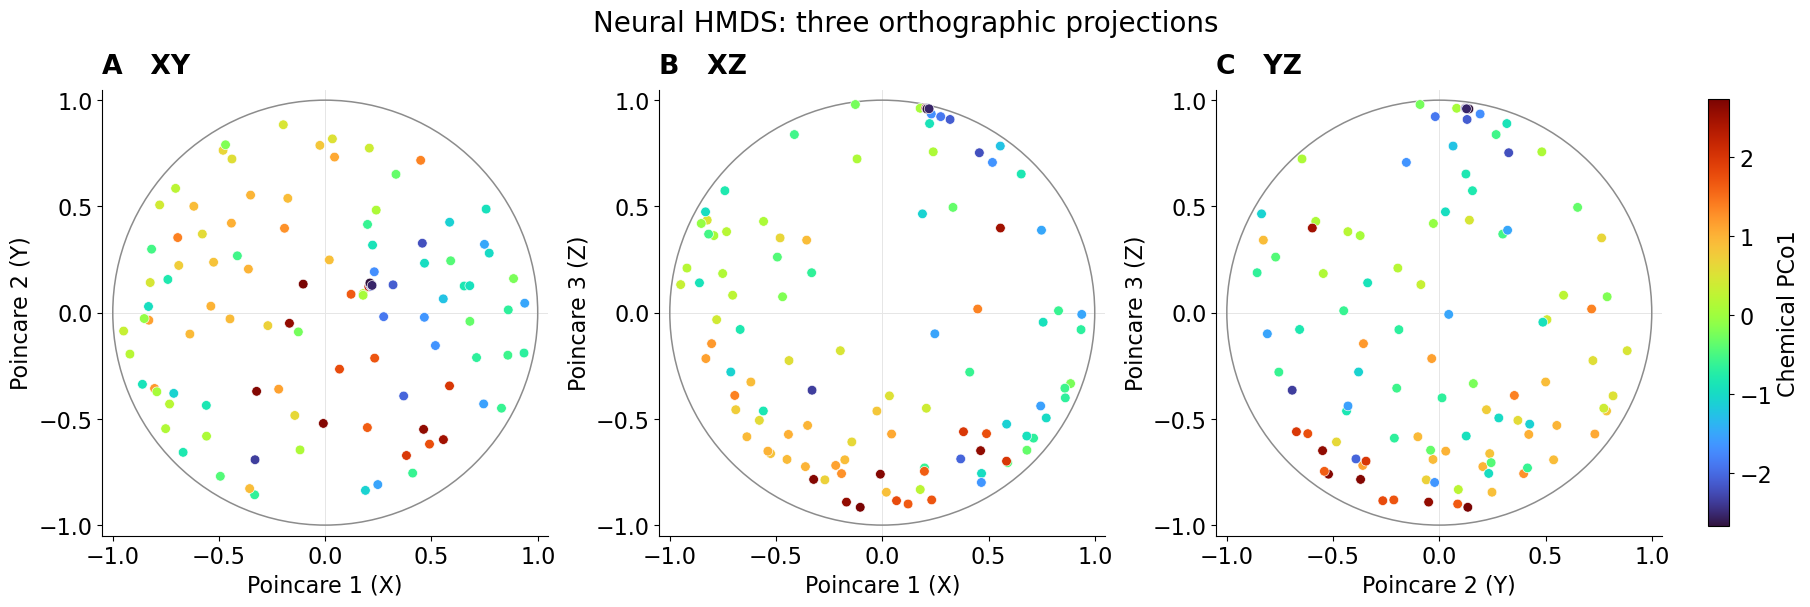

三个面板来自同一个三维拟合；二维投影上的点间距离不等于双曲距离。
Vector PDF: h:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\neural_hmds_3d_20260922_164053_099544\neural_hmds_3d_projections.pdf
300 dpi PNG: h:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\neural_hmds_3d_20260922_164053_099544\neural_hmds_3d_projections.png


In [81]:
# Poster export: orthographic XY / XZ / YZ views of the SAME fitted 3D model.
# Projected Euclidean separations are not fitted hyperbolic distances.
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from chemical_colors import mpl_colors, mpl_colorbar_kwargs, color_provenance

HMDS_PROJECTION_FIGSIZE = (18, 6)  # inches; PDF points/text remain vector graphics.
HMDS_PROJECTION_POINT_SIZE = 48
HMDS_PROJECTION_FONT_SIZE = 16
HMDS_PROJECTION_LABEL_IDS = ()  # Optional sample IDs to annotate, e.g. ('A001',).

if not isinstance(globals().get('hmds_3d_bundle'), dict) or globals().get('hmds_3d_directory') is None:
    raise RuntimeError('Run the current 3D HMDS fit and display cells first.')
if not isinstance(globals().get('chemical_color_mapping'), dict):
    raise RuntimeError('Run Cell 30 to prepare the shared chemical color mapping.')
projection_fit = hmds_3d_bundle['fit']
if not projection_fit['diagnostics'].get('joint_gradient_converged', False):
    raise RuntimeError('The current 3D HMDS fit has not passed its convergence checks.')
projection_coordinates = projection_fit['display_coordinates'].loc[
    :, ['Poincare1', 'Poincare2', 'Poincare3']
].copy()  # rows = stimulus IDs, columns = centered Poincare ball coordinates.
projection_xyz = projection_coordinates.to_numpy(dtype=float)
if not np.isfinite(projection_xyz).all() or (np.linalg.norm(projection_xyz, axis=1) > 1 + 1e-10).any():
    raise ValueError('Expected finite 3D coordinates inside the unit Poincare ball.')
unknown_labels = set(HMDS_PROJECTION_LABEL_IDS) - set(projection_coordinates.index)
if unknown_labels:
    raise ValueError(f'Unknown annotation IDs: {sorted(unknown_labels)}')
projection_colors = mpl_colors(chemical_color_mapping, projection_coordinates.index)
projection_planes = [(0, 1, 'A   XY'), (0, 2, 'B   XZ'), (1, 2, 'C   YZ')]
projection_axis_labels = ['Poincare 1 (X)', 'Poincare 2 (Y)', 'Poincare 3 (Z)']
projection_output_dir = Path(hmds_3d_directory)
if not projection_output_dir.is_dir():
    raise RuntimeError('The current 3D HMDS output directory is missing.')
hmds_projection_pdf = projection_output_dir / 'neural_hmds_3d_projections.pdf'
hmds_projection_png = projection_output_dir / 'neural_hmds_3d_projections.png'

with plt.rc_context({'font.size': HMDS_PROJECTION_FONT_SIZE, 'pdf.fonttype': 42,
                     'ps.fonttype': 42, 'axes.spines.top': False, 'axes.spines.right': False}):
    fig_hmds_projections, projection_axes = plt.subplots(
        1, 3, figsize=HMDS_PROJECTION_FIGSIZE, constrained_layout=True
    )
    for projection_ax, (first, second, title) in zip(projection_axes, projection_planes):
        projection_ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='0.55', lw=1.1))
        projection_ax.axhline(0, color='0.9', lw=.7, zorder=0)
        projection_ax.axvline(0, color='0.9', lw=.7, zorder=0)
        projection_scatter = projection_ax.scatter(
            projection_xyz[:, first], projection_xyz[:, second], **projection_colors,
            s=HMDS_PROJECTION_POINT_SIZE, edgecolors='white', linewidths=.45,
            alpha=1, rasterized=False, zorder=3,
        )
        projection_ax.set(xlim=(-1.05, 1.05), ylim=(-1.05, 1.05), aspect='equal',
                          xlabel=projection_axis_labels[first], ylabel=projection_axis_labels[second],
                          xticks=[-1, -.5, 0, .5, 1], yticks=[-1, -.5, 0, .5, 1])
        projection_ax.set_title(title, loc='left', fontweight='bold', pad=12)
        for sample_id in HMDS_PROJECTION_LABEL_IDS:
            point = projection_coordinates.loc[sample_id].to_numpy()
            projection_ax.annotate(str(sample_id), (point[first], point[second]),
                                   xytext=(4, 4), textcoords='offset points', fontsize=11)
    fig_hmds_projections.colorbar(
        projection_scatter, ax=projection_axes.tolist(), shrink=.8, fraction=.025, pad=.025,
        **mpl_colorbar_kwargs(chemical_color_mapping),
    )
    fig_hmds_projections.suptitle('Neural HMDS: three orthographic projections', fontsize=20)
    fig_hmds_projections.savefig(hmds_projection_pdf, bbox_inches='tight', facecolor='white',
                                metadata={'Title': 'Neural HMDS: three orthographic projections'})
    fig_hmds_projections.savefig(hmds_projection_png, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

projection_coordinates.to_csv(projection_output_dir / 'projection_source_coordinates.csv')
(projection_output_dir / 'projection_parameters.json').write_text(json.dumps({
    'source_fit_directory': str(projection_output_dir.resolve()),
    'source_coordinates': 'fit.display_coordinates', 'n_samples': len(projection_coordinates),
    'projection_planes': ['XY', 'XZ', 'YZ'], 'coordinate_transform': 'none; select coordinate pairs',
    'figure_size_inches': HMDS_PROJECTION_FIGSIZE, 'point_size': HMDS_PROJECTION_POINT_SIZE,
    'font_size': HMDS_PROJECTION_FONT_SIZE, 'annotated_ids': list(HMDS_PROJECTION_LABEL_IDS),
    'chemical_colors': color_provenance(chemical_color_mapping),
    'interpretation': 'Views of one 3D fit; projected distances do not preserve hyperbolic distances.',
}, indent=2, ensure_ascii=False), encoding='utf-8')
print('三个面板来自同一个三维拟合；二维投影上的点间距离不等于双曲距离。')
print('Vector PDF:', hmds_projection_pdf)
print('300 dpi PNG:', hmds_projection_png)


化学侧没有重复培养或测量数据时，不要通过重采样380个分子来制造“测量误差”。那改变的是化学特征集合，回答的是特征选择敏感性，不是同一化学谱的实验重复性。
每株菌对应一个可靠化学特征集合上的 log₂FC 向量：\mathbf L_i=(L_{i1},\ldots,L_{ip}).
可以用均方根距离 D^C_{ij}=\frac{1}{\sqrt p}\|\mathbf L_i-\mathbf L_j\|_2. 构建的RMS 比如cell10中构建的RDM

根据现有代码的尺度约定，令
$$
\widetilde D^C=aD^C,
\qquad
a=\frac{2}{\max_{i<j}D^C_{ij}}.
$$
针对目前的模型 \widetilde D^C_{ij}
\sim
\mathcal N\left(
\frac{\delta_H(\mathbf z_i,\mathbf z_j)}{\lambda},
\ \sigma_i^2+\sigma_j^2
\right),
可以先不提供经验距离方差，直接拟合；但不能把拟合得到的 \(\sigma_i\) 解释为LC–MS测量误差

In [70]:
# Fixed chemical reference determines color; each embedding keeps its own distances.
from pathlib import Path
import sys
import importlib
color_root = next(root for root in (Path.cwd(), Path.cwd().parent)
                  if (root / 'notebook/chemical_colors.py').is_file())
if str(color_root / 'notebook') not in sys.path:
    sys.path.insert(0, str(color_root / 'notebook'))
import chemical_colors
importlib.reload(chemical_colors)
from chemical_colors import build_chemical_colors, mpl_colors, plotly_colors, mpl_colorbar_kwargs
if 'chemical_color_mapping' not in globals() or 'scores' not in chemical_color_mapping:
    if 'chemical_rdm' not in globals():
        raise RuntimeError('Run 化学 RDM 单元 then the color setup in 二维 MDS 单元 or 化学配色单元; no neural fit is needed')
    chemical_color_mapping = build_chemical_colors(chemical_rdm)
# Reuse this frozen mapping even when plotting a different RDM or sample order.
# Run 化学配色单元 explicitly to replace the reference or colormap.

# Chemical overall HMDS: shared residual sigma, no empirical measurement variance.
# Input: 化学 RDM 单元 chemical_rdm (fixed-feature RMS log2FC; current shared bacterial set).
# Scale as 化学 HMDS 模型说明: a=2/max(D); pair variance=2*sigma**2, estimated from all residuals.
# Sigma is model approximation error, NOT LC-MS measurement error.
from pathlib import Path
from datetime import datetime
import hashlib
import importlib
import json
import sys
import numpy as np
import pandas as pd
from IPython.display import display

# Free-lambda 2D attempts did not pass numerical checks. This is a fixed-curvature 2D view.
CHEM_HMDS_FIXED_LAMBDA_2D = 10.0  # Explicit modeling choice, not a curvature estimate.
CHEM_HMDS_SEED = 20260919
CHEM_HMDS_INITIAL_LAMBDAS = (0.5, 2.0, 5.0)  # Initial values, not bounds.
CHEM_HMDS_MAX_BLOCKS = 20
CHEM_HMDS_ITERATIONS_PER_BLOCK = 1000
CHEM_HMDS_GRADIENT_TOLERANCE = 1e-6

if 'chemical_rdm' not in globals():
    raise RuntimeError('Run 化学 RDM 单元 first to construct the overall chemical RDM')
chemical_hmds_root = next(
    p for p in (Path.cwd(), Path.cwd().parent)
    if (p / 'notebook/03_chemical_neuron_bacteria.ipynb').is_file()
)
if str(chemical_hmds_root / 'notebook') not in sys.path:
    sys.path.insert(0, str(chemical_hmds_root / 'notebook'))
import chemical_hmds_polar
chemical_hmds_polar = importlib.reload(chemical_hmds_polar)
import chemical_hmds
chemical_hmds = importlib.reload(chemical_hmds)

# Import shared geometry directly; no historical neural fit is required.
import neural_hmds
neural_hmds = importlib.reload(neural_hmds)
chemical_hmds_output = chemical_hmds_root / 'output/jupyter-notebook' / (
    'chemical_hmds_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f')
)
chemical_hmds_bundle = chemical_hmds.fit_chemical_hmds(
    chemical_rdm,
    neural_hmds.hmds_geometry, neural_hmds.hmds_chart_to_ball,
    chemical_hmds_output, seed=CHEM_HMDS_SEED,
    initial_lambdas=CHEM_HMDS_INITIAL_LAMBDAS, max_blocks=CHEM_HMDS_MAX_BLOCKS,
    iterations_per_block=CHEM_HMDS_ITERATIONS_PER_BLOCK,
    gradient_tolerance=CHEM_HMDS_GRADIENT_TOLERANCE,
    fixed_lambda_2d=CHEM_HMDS_FIXED_LAMBDA_2D,
)
chemical_hmds_results = chemical_hmds_bundle['results']
chemical_hmds_summary = chemical_hmds_bundle['summary']
chemical_hmds_2d_coordinates = chemical_hmds_results[2]['coordinates']
chemical_hmds_3d_coordinates = chemical_hmds_results[3]['coordinates']
chemical_hmds_figure = chemical_hmds.plot_chemical_hmds(chemical_hmds_bundle, color_mapping=chemical_color_mapping)
chemical_colors.save_chemical_colors(chemical_color_mapping, chemical_hmds_output / 'color_reference')
(chemical_hmds_output / 'chemical_colors_used.py').write_bytes(
    (chemical_hmds_root / 'notebook/chemical_colors.py').read_bytes()
)
chemical_hmds_figure.write_html(chemical_hmds_output / 'chemical_hmds_2d_3d.html', include_plotlyjs=True)
chemical_hmds_figure.write_json(chemical_hmds_output / 'chemical_hmds_2d_3d.json')
(chemical_hmds_output / 'chemical_hmds_used.py').write_bytes(
    (chemical_hmds_root / 'notebook/chemical_hmds.py').read_bytes()
)
(chemical_hmds_output / 'chemical_hmds_polar_used.py').write_bytes(
    (chemical_hmds_root / 'notebook/chemical_hmds_polar.py').read_bytes()
)
(chemical_hmds_output / 'neural_hmds_used.py').write_bytes(Path(neural_hmds.__file__).read_bytes())
# Source snapshots use the persistent cell ID, independent of notebook ordering.
chemical_hmds_notebook = json.loads(
    (chemical_hmds_root / 'notebook/03_chemical_neuron_bacteria.ipynb').read_text(encoding='utf-8')
)
chemical_hmds_generation_source = next(cell['source'] for cell in chemical_hmds_notebook['cells']
                             if cell.get('id') == 'a05ebf75')
(chemical_hmds_output / 'chemical_hmds_generation.py').write_text(
    ''.join(chemical_hmds_generation_source), encoding='utf-8'
)

display(chemical_hmds_summary[[
    'relative_rmse', 'metric_mds_relative_rmse', 'lambda_value', 'mean_nll',
    'shared_sigma_original', 'lambda_fitted', 'gradient_inf', 'converged', 'gradient_checks_passed',
]])
display({'application/vnd.plotly.v1+json': json.loads(chemical_hmds_figure.to_json())}, raw=True)
print('2D lambda is FIXED for visualization; 3D lambda is fitted. This is not a comparison of two free-curvature optima.')
print('Shared sigma represents model residuals; no chemical measurement variance or bootstrap was invented.')
print('continuous chemical reference colors; drag the 3D panel to rotate. Shepard axes use original RMS log2FC units.')
print('Sample scope:', chemical_rdm.attrs.get('sample_scope', 'current chemical_rdm'))
print('Feature reliability:', chemical_rdm.attrs.get('reliability', 'not recorded'))
if not chemical_hmds_summary['converged'].all() or not chemical_hmds_summary['gradient_checks_passed'].all():
    print('Some diagnostics failed: treat the corresponding embedding as provisional; inspect summary.csv.')
print('Saved:', chemical_hmds_output / 'chemical_hmds_result.pkl')


h:\Process_temporary\WJH\bacteria_analysis\.pixi\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Chemical 2D start 1/3 block=1: loss=-0.76010670, lambda=10, gradient=4.11e-07
Chemical 2D start 2/3 block=1: loss=-0.73664630, lambda=10, gradient=0.000236
Chemical 2D start 2/3 block=2: loss=-0.73664631, lambda=10, gradient=4.06e-08
Chemical 2D start 3/3 block=1: loss=-0.70052366, lambda=10, gradient=3.15e-07
Chemical 3D start 1/3 block=1: loss=-0.50323435, lambda=21.386, gradient=0.121
Chemical 3D start 1/3 block=2: loss=-1.40182042, lambda=9.4902, gradient=9.29e-07
Chemical 3D start 2/3 block=1: loss=-1.40353850, lambda=9.4295, gradient=9.73e-07
Chemical 3D start 3/3 block=1: loss=-1.40353850, lambda=9.4295, gradient=1.19e-07


,relative_rmse,metric_mds_relative_rmse,lambda_value,mean_nll,shared_sigma_original,lambda_fitted,gradient_inf,converged,gradient_checks_passed
dimension,,,,,,,,,
2,0.091022,0.298531,10.000000,-0.760107,0.257977,False,4.114802e-07,True,True
3,0.047831,0.213014,9.429473,-1.403538,0.135563,True,1.185330e-07,True,True


2D lambda is FIXED for visualization; 3D lambda is fitted. This is not a comparison of two free-curvature optima.
Shared sigma represents model residuals; no chemical measurement variance or bootstrap was invented.
continuous chemical reference colors; drag the 3D panel to rotate. Shepard axes use original RMS log2FC units.
Sample scope: Neural/chemical ID intersection
Feature reliability: Unverified; numerical-validity-only exploratory baseline
Saved: h:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\chemical_hmds_20260921_192946_373155\chemical_hmds_result.pkl


若考虑共变性，发现了若干个稳定的共变组，可以建立：
$$
d_{\mathrm{block}}^2(i,j)
=
\frac1G\sum_{g=1}^{G}
\left[
\frac1{|G_g|}
\sum_{k\in G_g}(L_{ik}-L_{jk})^2
\right].
$$
这里假设各组不重叠；没有合适归属的分子可以保留为单独一组。这个距离使各组的平均平方差异获得相同的外层权重，降低“某组只是测到了更多成员，因此自动占据更大贡献”的影响。它保留每个分子的身份，因此不会像类别平均一样让前体和产物的相反变化互相抵消。

但这只是一个组等权的候选模型，不是客观正确的化学距离：分组本身需要稳定性支持，组等权也是一种选择，它也不能自动解决噪声和组内冗余问题。

Full chemical library: 299 bacteria x 380 fixed features
Neural-paired subset: 106 bacteria; grouping uses the full library


h:\Process_temporary\WJH\bacteria_analysis\.pixi\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Chemical block composition resampling: 50/1000
Chemical block composition resampling: 100/1000
Chemical block composition resampling: 150/1000
Chemical block composition resampling: 200/1000
Chemical block composition resampling: 250/1000
Chemical block composition resampling: 300/1000
Chemical block composition resampling: 350/1000
Chemical block composition resampling: 400/1000
Chemical block composition resampling: 450/1000
Chemical block composition resampling: 500/1000
Chemical block composition resampling: 550/1000
Chemical block composition resampling: 600/1000
Chemical block composition resampling: 650/1000
Chemical block composition resampling: 700/1000
Chemical block composition resampling: 750/1000
Chemical block composition resampling: 800/1000
Chemical block composition resampling: 850/1000
Chemical block composition resampling: 900/1000
Chemical block composition resampling: 950/1000
Chemical block composition resampling: 1000/1000


h:\Process_temporary\WJH\bacteria_analysis\.pixi\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Paired chemical relationship check: 100/1000
Paired chemical relationship check: 200/1000
Paired chemical relationship check: 300/1000
Paired chemical relationship check: 400/1000
Paired chemical relationship check: 500/1000
Paired chemical relationship check: 600/1000
Paired chemical relationship check: 700/1000
Paired chemical relationship check: 800/1000
Paired chemical relationship check: 900/1000
Paired chemical relationship check: 1000/1000


,value
n_samples,299.000000
n_features,380.000000
n_pairs,44551.000000
initial_groups,270.000000
n_groups,304.000000
multi_feature_groups,49.000000
singleton_groups,255.000000
constant_features,0.000000
singleton_total_weight,0.838816
largest_group,6.000000


,n_features,singleton,min_association,min_coassignment,mean_coassignment,original_total_weight,block_total_weight,per_feature_weight_ratio,original_mean_squared_contribution,block_mean_squared_contribution,original_contribution_share,block_contribution_share
block,,,,,,,,,,,,
C015,6,False,0.809062,0.950,0.977067,0.015789,0.003289,0.208333,0.014892,0.003102,0.000984,0.000193
C017,5,False,0.829153,0.865,0.944200,0.013158,0.003289,0.250000,0.019959,0.004990,0.001319,0.000310
C124,5,False,0.853960,0.999,0.999600,0.013158,0.003289,0.250000,0.003450,0.000863,0.000228,0.000054
C005,5,False,0.776668,0.970,0.984200,0.013158,0.003289,0.250000,0.053117,0.013279,0.003511,0.000824
C107,4,False,0.819552,0.955,0.977500,0.010526,0.003289,0.312500,0.008751,0.002735,0.000578,0.000170
C036,3,False,0.733975,0.841,0.894000,0.007895,0.003289,0.416667,0.061855,0.025773,0.004089,0.001600
C128,3,False,0.813224,0.852,0.901333,0.007895,0.003289,0.416667,0.219124,0.091302,0.014484,0.005668
C110,3,False,0.860369,0.863,0.908667,0.007895,0.003289,0.416667,0.007457,0.003107,0.000493,0.000193
C099,3,False,0.832216,0.998,0.998667,0.007895,0.003289,0.416667,0.109900,0.045792,0.007264,0.002843


,paired_subset_check
n_full_samples,299
n_paired_samples,106
n_features,380
within_block_pairs,119
multi_feature_groups,49
groups_passing_subset_check,43
groups_not_passing_subset_check,6
pairs_with_sign_reversal,0
pairs_undefined_in_subset,0
pairs_passing_subset_check,110


,within_block_pairs,paired_min_association,paired_min_relation_support,paired_all_signs_agree,paired_relationships_pass,paired_check_status
block,,,,,,
C003,1,0.839306,0.990,True,True,passes specified criteria
C004,1,0.966560,1.000,True,True,passes specified criteria
C005,10,0.660473,0.341,True,False,does not meet all criteria
C006,3,0.957785,1.000,True,True,passes specified criteria
C007,3,0.818545,0.991,True,True,passes specified criteria
C013,1,0.953961,1.000,True,True,passes specified criteria
C014,3,0.925788,1.000,True,True,passes specified criteria
C015,15,0.753432,0.846,True,True,passes specified criteria
C017,10,0.723586,0.649,True,False,does not meet all criteria


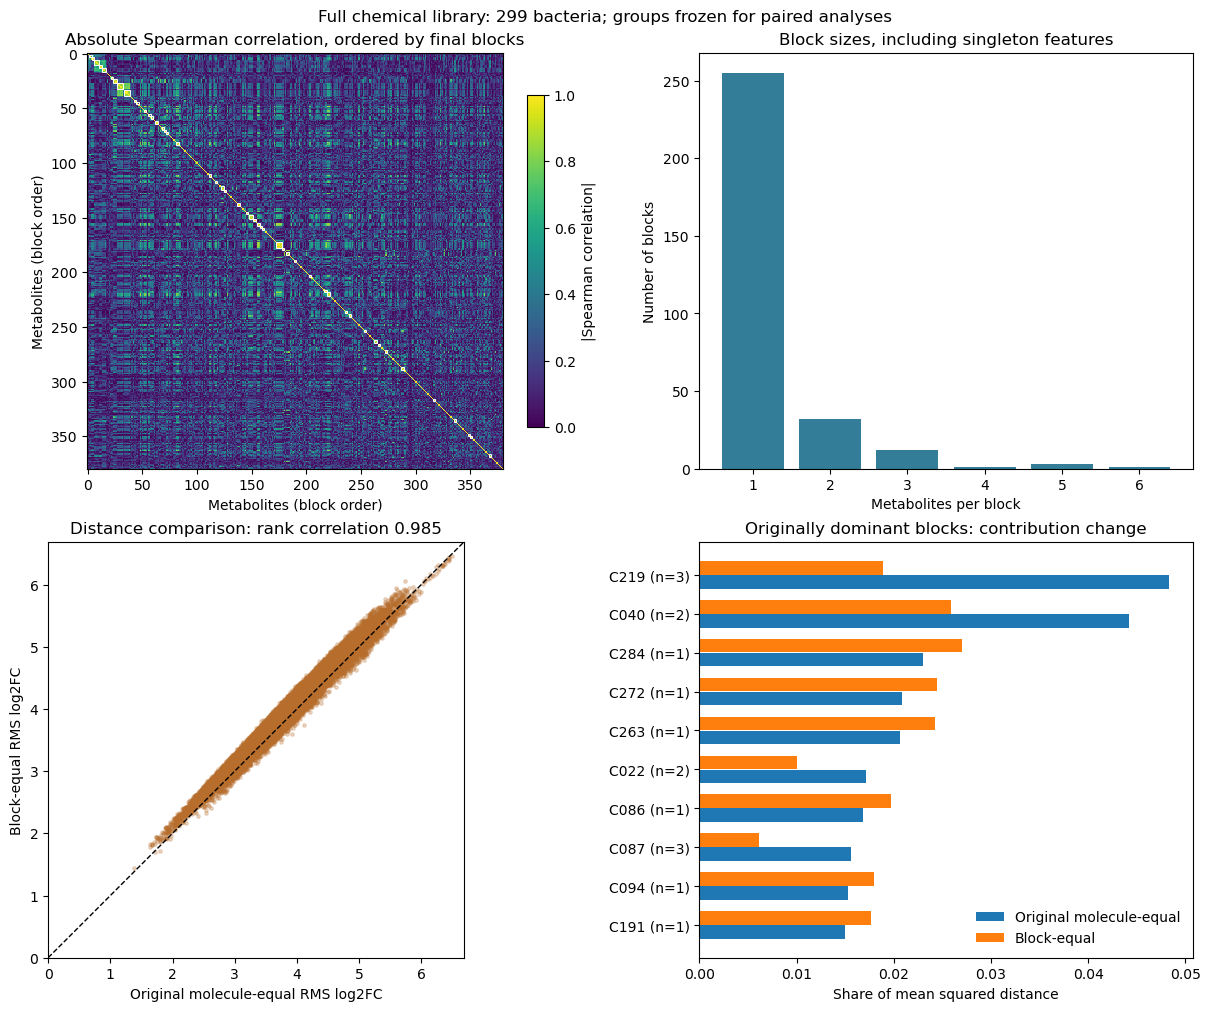

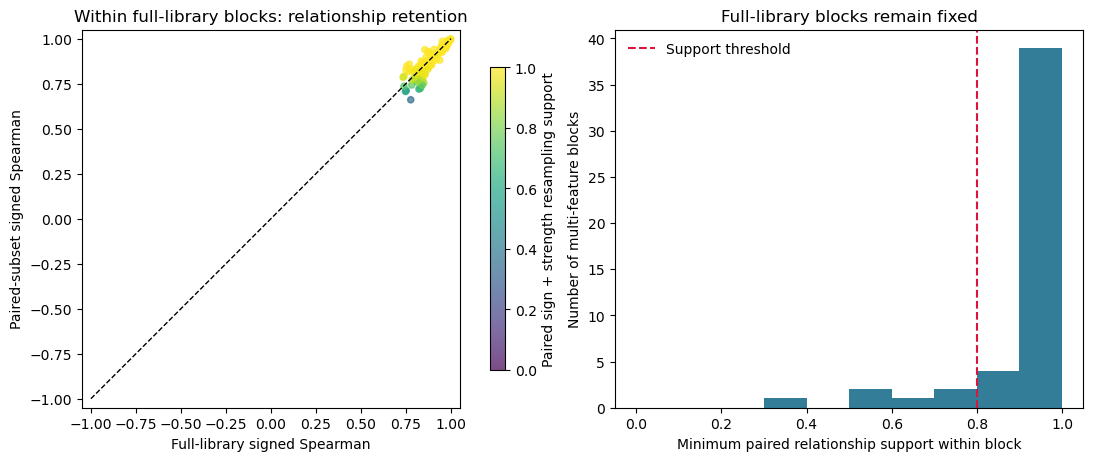

全库分组距离：chemical_block_rdm_all；后续神经关联使用配对子集：chemical_block_rdm_paired。
chemical_block_rdm 默认指向配对子集，与 neural_rdm_block_paired 同顺序；分组、特征和权重固定为全库结果。
当前 304 组，其中 49 个多分子组，255 个单分子组。
单分子组占新距离总特征权重的 83.9%；这不等于它们的实际距离贡献。
消除全局比例差异后的相对距离变化：2.51%。
这些是当前菌株集合和阈值下的探索性分组，不是已验证的代谢通路；重采样不代表测量误差。
全库 299 株，配对子集 106 株；43/49 个多分子组满足配对子集检查条件。
子集检查不重新分组、不改变权重，也不根据神经响应筛选组；未满足条件的组仍保留并标记。
全库稳定性是共分组频率；子集支持率是保持全库相关方向且达到相关强度阈值的频率，两者含义不同。
配对子集参与了全库发现，检查属于适用性描述，不是独立验证或神经关联显著性检验。
Saved: h:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\chemical_blocks_20260921_193107_764109\chemical_block_result.pkl


In [71]:
# 共变组距离说明: discover blocks using ALL bacterial rows of the chemical matrix.
# Freeze full-library features/groups/weights, check them in the neural-paired subset.
# Input: 化学 RDM 单元 chemical_fc_all and chemical_rms_distance; neural_rdm supplies paired IDs only.
# Resample bacterial rows to assess composition sensitivity, NOT LC-MS measurement error.
from pathlib import Path
from datetime import datetime
import hashlib
import importlib
import json
import pickle
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display

CHEM_BLOCK_ABSOLUTE_CORRELATION = True  # Include coordinated opposite-direction patterns.
CHEM_BLOCK_CORRELATION_THRESHOLD = 0.70
CHEM_BLOCK_STABILITY_THRESHOLD = 0.80  # Minimum within-block bootstrap coassignment.
CHEM_BLOCK_RESAMPLES = 1000
CHEM_BLOCK_SEED = 20260920
CHEM_BLOCK_SUBSET_RESAMPLES = 1000
CHEM_BLOCK_SUBSET_SEED = 20260921

if any(name not in globals() for name in ('chemical_fc_all', 'chemical_rms_distance', 'neural_rdm')):
    raise RuntimeError('Run 化学 RDM 单元 first: full chemical matrix, distance helper, and neural IDs are required')
chemical_block_root = next(
    root for root in (Path.cwd(), Path.cwd().parent)
    if (root / 'notebook/03_chemical_neuron_bacteria.ipynb').is_file()
)
if str(chemical_block_root / 'notebook') not in sys.path:
    sys.path.insert(0, str(chemical_block_root / 'notebook'))
import chemical_blocks
chemical_blocks = importlib.reload(chemical_blocks)

# Select the valid feature set ONCE across the entire chemical matrix.
# 化学 RDM 单元's earlier paired-only chemical_profiles/chemical_rdm remain intact.
chemical_full_profiles, chemical_full_rdm, chemical_full_feature_audit = chemical_rms_distance(
    chemical_fc_all, globals().get('RELIABLE_METABOLITES'),
)
chemical_full_rdm.attrs.update(raw_file=str(CHEMICAL_PATH), sheet=0,
                               sample_scope='Full chemical library: all matrix rows')
chemical_block_paired_ids = neural_rdm.index[neural_rdm.index.isin(chemical_full_profiles.index)]
chemical_block_unmatched_neural_ids = neural_rdm.index[~neural_rdm.index.isin(chemical_full_profiles.index)]
if len(chemical_block_paired_ids) < 3:
    raise ValueError('At least three matched bacteria are required for the subset check')
print(f'Full chemical library: {chemical_full_profiles.shape[0]} bacteria x {chemical_full_profiles.shape[1]} fixed features')
print(f'Neural-paired subset: {len(chemical_block_paired_ids)} bacteria; grouping uses the full library')

chemical_block_result = chemical_blocks.build_chemical_blocks(
    chemical_full_profiles, chemical_full_rdm,
    correlation_threshold=CHEM_BLOCK_CORRELATION_THRESHOLD,
    stability_threshold=CHEM_BLOCK_STABILITY_THRESHOLD,
    n_resamples=CHEM_BLOCK_RESAMPLES, seed=CHEM_BLOCK_SEED,
    absolute_correlation=CHEM_BLOCK_ABSOLUTE_CORRELATION,
)
chemical_block_result['parameters'].update(
    discovery_scope='All bacterial rows in chemical_fc_all',
    n_discovery_samples=len(chemical_full_profiles),
    feature_selection_scope='Positive finite FC across the entire chemical library',
)
chemical_block_subset_check = chemical_blocks.check_blocks_in_subset(
    chemical_block_result, chemical_block_paired_ids,
    n_resamples=CHEM_BLOCK_SUBSET_RESAMPLES, seed=CHEM_BLOCK_SUBSET_SEED,
)
chemical_block_result['paired_subset_check'] = chemical_block_subset_check
chemical_block_result['feature_selection_audit'] = chemical_full_feature_audit

# w_k = 1 / (G * size_of_block_k); d_block = pdist(log2FC * sqrt(w)).
# Group inference uses ranks; the distance uses original, unstandardized log2FC.
chemical_block_rdm_all = chemical_block_result['rdm']
chemical_block_rdm_paired = chemical_block_subset_check['rdm']
chemical_block_paired_baseline_rdm = chemical_block_subset_check['baseline_rdm']
chemical_block_paired_profiles = chemical_block_subset_check['profiles']
neural_rdm_block_paired = neural_rdm.loc[chemical_block_paired_ids, chemical_block_paired_ids].copy()
# Backward-compatible downstream variable always contains ONLY the paired subset.
chemical_block_rdm = chemical_block_rdm_paired
chemical_block_result['downstream_rdm_key'] = 'paired_subset_check.rdm'
assert chemical_block_rdm.index.equals(neural_rdm_block_paired.index)
chemical_block_groups = chemical_block_result['groups']
chemical_block_members = chemical_block_result['members']
chemical_block_summary = chemical_block_result['group_summary']
chemical_block_metrics = pd.Series(chemical_block_result['metrics'], name='value')

display(chemical_block_metrics.to_frame())
display(chemical_block_summary.sort_values('n_features', ascending=False).head(15))
display(pd.Series(chemical_block_subset_check['metrics'], name='paired_subset_check').to_frame())
display(chemical_block_subset_check['group_summary'].query('within_block_pairs > 0'))

chemical_block_output = chemical_block_root / 'output/jupyter-notebook' / (
    'chemical_blocks_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f')
)
chemical_block_output.mkdir(parents=True, exist_ok=False)
chemical_block_rdm.to_csv(chemical_block_output / 'chemical_block_rdm.csv')  # Paired-only alias.
chemical_block_rdm_all.to_csv(chemical_block_output / 'chemical_block_rdm_all.csv')
chemical_block_rdm_paired.to_csv(chemical_block_output / 'chemical_block_rdm_paired.csv')
chemical_full_rdm.to_csv(chemical_block_output / 'chemical_rms_rdm_all.csv')
chemical_block_paired_baseline_rdm.to_csv(chemical_block_output / 'chemical_rms_rdm_paired.csv')
chemical_full_feature_audit.to_csv(chemical_block_output / 'full_library_feature_audit.csv')
chemical_block_subset_check['pairs'].to_csv(chemical_block_output / 'paired_relationship_checks.csv', index=False)
chemical_block_subset_check['group_summary'].to_csv(chemical_block_output / 'paired_group_checks.csv')
(chemical_block_output / 'paired_check_parameters.json').write_text(
    json.dumps(chemical_block_subset_check['parameters'], ensure_ascii=False, indent=2), encoding='utf-8'
)
chemical_block_members.to_csv(chemical_block_output / 'feature_blocks_and_weights.csv')
chemical_block_summary.to_csv(chemical_block_output / 'group_summary.csv')
chemical_block_result['coassignment'].to_csv(chemical_block_output / 'resampling_coassignment.csv')
chemical_block_result['correlation'].to_csv(chemical_block_output / 'feature_spearman.csv')
chemical_block_result['code_sha256'] = hashlib.sha256(
    (chemical_block_root / 'notebook/chemical_blocks.py').read_bytes()
).hexdigest()
with (chemical_block_output / 'chemical_block_result.pkl').open('wb') as handle:
    pickle.dump(chemical_block_result, handle)
for name in ('metrics', 'parameters'):
    (chemical_block_output / f'{name}.json').write_text(
        json.dumps(chemical_block_result[name], indent=2, ensure_ascii=False, default=str), encoding='utf-8'
    )
(chemical_block_output / 'chemical_blocks_used.py').write_bytes(
    (chemical_block_root / 'notebook/chemical_blocks.py').read_bytes()
)
chemical_block_notebook = json.loads(
    (chemical_block_root / 'notebook/03_chemical_neuron_bacteria.ipynb').read_text(encoding='utf-8')
)
(chemical_block_output / 'chemical_blocks_generation.py').write_text(
    ''.join(next(cell['source'] for cell in chemical_block_notebook['cells'] if cell.get('id') == 'ee3a0719')), encoding='utf-8'
)

fig_chemical_blocks, axes_chemical_blocks = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
chemical_block_order = np.argsort(chemical_block_groups.to_numpy(), kind='stable')
chemical_block_correlation = chemical_block_result['correlation'].to_numpy()
ax = axes_chemical_blocks[0, 0]
image = ax.imshow(np.abs(chemical_block_correlation[np.ix_(chemical_block_order, chemical_block_order)]),
                  vmin=0, vmax=1, cmap='viridis', interpolation='nearest')
offset = 0
for group in sorted(chemical_block_groups.unique()):
    size = int((chemical_block_groups == group).sum())
    if size > 1:
        ax.add_patch(Rectangle((offset-.5, offset-.5), size, size, fill=False, ec='white', lw=.7))
    offset += size
ax.set(title='Absolute Spearman correlation, ordered by final blocks',
       xlabel='Metabolites (block order)', ylabel='Metabolites (block order)')
fig_chemical_blocks.colorbar(image, ax=ax, label='|Spearman correlation|', shrink=.8)

ax = axes_chemical_blocks[0, 1]
chemical_block_sizes = chemical_block_summary.n_features.value_counts().sort_index()
ax.bar(chemical_block_sizes.index, chemical_block_sizes.values, color='#337d98')
ax.set(title='Block sizes, including singleton features', xlabel='Metabolites per block', ylabel='Number of blocks')

chemical_block_upper = np.triu_indices(len(chemical_full_rdm), 1)
chemical_block_original_pairs = chemical_full_rdm.to_numpy()[chemical_block_upper]
chemical_block_weighted_pairs = chemical_block_rdm_all.to_numpy()[chemical_block_upper]
chemical_block_limit = 1.03 * max(chemical_block_original_pairs.max(), chemical_block_weighted_pairs.max())
ax = axes_chemical_blocks[1, 0]
ax.scatter(chemical_block_original_pairs, chemical_block_weighted_pairs, s=6, alpha=.25, color='#b76d2b')
ax.plot([0, chemical_block_limit], [0, chemical_block_limit], 'k--', lw=1)
ax.set(xlim=(0, chemical_block_limit), ylim=(0, chemical_block_limit), aspect='equal',
       xlabel='Original molecule-equal RMS log2FC', ylabel='Block-equal RMS log2FC',
       title=f"Distance comparison: rank correlation {chemical_block_metrics['distance_spearman']:.3f}")

ax = axes_chemical_blocks[1, 1]
chemical_block_top = chemical_block_summary.nlargest(10, 'original_contribution_share').iloc[::-1]
chemical_block_y = np.arange(len(chemical_block_top))
ax.barh(chemical_block_y-.18, chemical_block_top.original_contribution_share, height=.35, label='Original molecule-equal')
ax.barh(chemical_block_y+.18, chemical_block_top.block_contribution_share, height=.35, label='Block-equal')
ax.set(yticks=chemical_block_y,
       yticklabels=[f'{group} (n={int(row.n_features)})' for group, row in chemical_block_top.iterrows()],
       xlabel='Share of mean squared distance', title='Originally dominant blocks: contribution change')
ax.legend(frameon=False)
fig_chemical_blocks.suptitle(f'Full chemical library: {len(chemical_full_profiles)} bacteria; groups frozen for paired analyses')
fig_chemical_blocks.savefig(chemical_block_output / 'chemical_block_diagnostics.png', dpi=160)
plt.show()

# Applicability of the FULL-library molecular relationships in the paired subset.
fig_chemical_block_subset, chemical_block_subset_axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
chemical_block_pair_checks = chemical_block_subset_check['pairs']
ax = chemical_block_subset_axes[0]
scatter = ax.scatter(chemical_block_pair_checks.full_spearman, chemical_block_pair_checks.paired_spearman,
                     c=chemical_block_pair_checks.paired_relation_support, vmin=0, vmax=1,
                     cmap='viridis', s=20, alpha=.7)
ax.plot([-1, 1], [-1, 1], 'k--', lw=1)
ax.set(xlim=(-1.05, 1.05), ylim=(-1.05, 1.05), aspect='equal',
       xlabel='Full-library signed Spearman', ylabel='Paired-subset signed Spearman',
       title='Within full-library blocks: relationship retention')
fig_chemical_block_subset.colorbar(scatter, ax=ax, label='Paired sign + strength resampling support', shrink=.8)
ax = chemical_block_subset_axes[1]
chemical_block_multi_checks = chemical_block_subset_check['group_summary'].query('within_block_pairs > 0')
ax.hist(chemical_block_multi_checks.paired_min_relation_support, bins=np.linspace(0, 1, 11), color='#337d98')
ax.axvline(CHEM_BLOCK_STABILITY_THRESHOLD, color='crimson', ls='--', label='Support threshold')
ax.set(xlabel='Minimum paired relationship support within block', ylabel='Number of multi-feature blocks',
       title='Full-library blocks remain fixed')
ax.legend(frameon=False)
fig_chemical_block_subset.savefig(chemical_block_output / 'paired_relationship_diagnostics.png', dpi=160)
plt.show()

print('全库分组距离：chemical_block_rdm_all；后续神经关联使用配对子集：chemical_block_rdm_paired。')
print('chemical_block_rdm 默认指向配对子集，与 neural_rdm_block_paired 同顺序；分组、特征和权重固定为全库结果。')
print(f"当前 {int(chemical_block_metrics['n_groups'])} 组，其中 {int(chemical_block_metrics['multi_feature_groups'])} 个多分子组，"
      f"{int(chemical_block_metrics['singleton_groups'])} 个单分子组。")
print(f"单分子组占新距离总特征权重的 {chemical_block_metrics['singleton_total_weight']:.1%}；这不等于它们的实际距离贡献。")
print(f"消除全局比例差异后的相对距离变化：{chemical_block_metrics['scale_aligned_relative_change']:.2%}。")
print('这些是当前菌株集合和阈值下的探索性分组，不是已验证的代谢通路；重采样不代表测量误差。')
print(f"全库 {len(chemical_full_profiles)} 株，配对子集 {len(chemical_block_paired_ids)} 株；"
      f"{chemical_block_subset_check['metrics']['groups_passing_subset_check']}/"
      f"{chemical_block_subset_check['metrics']['multi_feature_groups']} 个多分子组满足配对子集检查条件。")
print('子集检查不重新分组、不改变权重，也不根据神经响应筛选组；未满足条件的组仍保留并标记。')
print('全库稳定性是共分组频率；子集支持率是保持全库相关方向且达到相关强度阈值的频率，两者含义不同。')
print('配对子集参与了全库发现，检查属于适用性描述，不是独立验证或神经关联显著性检验。')
print('Saved:', chemical_block_output / 'chemical_block_result.pkl')


Observation: 基于Spearman的相似性，使用绝对值将强正相关和强负相关都可以归在一组。分组使用完全连接层次聚类，目前是有放回地每次从 106 株菌中抽取106行，重新计算相关，重新聚类，重复200次，每对分子被分到同一组地概率需要大于0.8.最终得到了 310 组：51 个多分子组和 259 个单分子组。基于block的新距离与原距离的Spearman相似性在0.972。

切换为299个菌整体评价共变组，得到 49 个多分子组、255 个单分子组。

这里识别的是“允许同向或反向变化的统计共变组”，这样适合找出具有相似或相反菌株排序、信息高度关联的化学特征 ，即概括化学数据中的关联结构，避免把高度共变的多个特征当成多条彼此独立的证据。

将重采样重复1000次时，结果为309 组，其中 51 个多分子组，258 个单分子组。在cell37可以汇总一下组内的分子

In [72]:
# Summarize the CURRENT 化学共变组分析单元 result; do not recluster or rerun resampling.
from pathlib import Path
from datetime import datetime
import json
import numpy as np
import pandas as pd
from IPython.display import display

CHEM_GROUP_SHOW_SINGLETONS = False  # All groups are always retained in the saved full table.

if 'chemical_block_result' not in globals():
    raise RuntimeError('Run 化学共变组分析单元 first to obtain the current chemical block assignments')
chemical_group_source = chemical_block_result
chemical_group_assignments = chemical_group_source['groups'].copy()
chemical_group_statistics = chemical_group_source['group_summary'].copy()
if 'paired_subset_check' in chemical_group_source:
    chemical_group_statistics = chemical_group_statistics.join(
        chemical_group_source['paired_subset_check']['group_summary']
    )
if not chemical_group_assignments.index.is_unique or chemical_group_assignments.isna().any():
    raise ValueError('Each molecule must occur exactly once and have one group')

chemical_group_member_lists = chemical_group_assignments.groupby(chemical_group_assignments, sort=False).apply(
    lambda group: list(group.index)
)
chemical_group_members_summary = chemical_group_statistics.join(
    chemical_group_member_lists.rename('metabolites'), how='left'
)
if not np.array_equal(
    chemical_group_members_summary['metabolites'].map(len).to_numpy(),
    chemical_group_members_summary['n_features'].to_numpy(),
):
    raise ValueError('Group sizes and membership differ; rerun 化学共变组分析单元 before summarizing')
chemical_group_members_summary = chemical_group_members_summary.sort_values(
    ['n_features', 'block'], ascending=[False, True], kind='stable'
)
chemical_group_members_long = chemical_group_source['members'].copy()
chemical_group_members_long['n_features'] = chemical_group_members_long['block'].map(
    chemical_group_statistics['n_features']
)
chemical_group_members_long = chemical_group_members_long.sort_values(
    ['n_features', 'block'], ascending=[False, True], kind='stable'
)

# Read resampling metadata from the fitted result, not from an adjustable global setting.
chemical_group_run_info = dict(chemical_group_source['parameters'])
chemical_group_run_info.update(
    n_groups=len(chemical_group_members_summary),
    multi_feature_groups=int((chemical_group_members_summary.n_features > 1).sum()),
    singleton_groups=int((chemical_group_members_summary.n_features == 1).sum()),
    n_features=len(chemical_group_assignments),
)
print(f"当前结果：{chemical_group_run_info['n_resamples']} 次重采样；"
      f"{chemical_group_run_info['n_groups']} 组，"
      f"其中 {chemical_group_run_info['multi_feature_groups']} 个多分子组、"
      f"{chemical_group_run_info['singleton_groups']} 个单分子组。")
chemical_group_display = chemical_group_members_summary[
    ['n_features', 'metabolites', 'min_association', 'min_coassignment']
    + [column for column in ('paired_min_association', 'paired_min_relation_support', 'paired_relationships_pass')
       if column in chemical_group_members_summary.columns]
].copy()
if not CHEM_GROUP_SHOW_SINGLETONS:
    chemical_group_display = chemical_group_display.loc[chemical_group_display.n_features > 1]
chemical_group_display['metabolites'] = chemical_group_display['metabolites'].map(
    lambda names: '\n'.join(map(str, names))
)
chemical_group_correlation_label = (
    '组内最小 |Spearman|'
    if chemical_group_run_info['correlation'] == 'absolute Spearman'
    else '组内最小 Spearman'
)
chemical_group_display = chemical_group_display.rename(columns={
    'n_features': '分子数', 'metabolites': '组内分子',
    'min_association': chemical_group_correlation_label,
    'min_coassignment': '全库最低共分组频率',
    'paired_min_association': '配对子集最低相关强度',
    'paired_min_relation_support': '配对子集最低关系支持率',
    'paired_relationships_pass': '配对子集满足条件',
})
display(chemical_group_display.style.format({
    chemical_group_correlation_label: '{:.3f}', '全库最低共分组频率': '{:.1%}',
    '配对子集最低相关强度': '{:.3f}', '配对子集最低关系支持率': '{:.1%}',
}, na_rep='—', escape='html').set_properties(**{'white-space': 'pre-wrap', 'text-align': 'left'}))

chemical_group_root = next(
    root for root in (Path.cwd(), Path.cwd().parent)
    if (root / 'notebook/03_chemical_neuron_bacteria.ipynb').is_file()
)
chemical_group_output = chemical_group_root / 'output/jupyter-notebook' / (
    'chemical_group_members_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f')
)
chemical_group_output.mkdir(parents=True, exist_ok=False)
chemical_group_export = chemical_group_members_summary.copy()
chemical_group_export['metabolites'] = chemical_group_export['metabolites'].map(
    lambda names: '\n'.join(map(str, names))
)
chemical_group_export.to_csv(chemical_group_output / 'all_group_members.csv', encoding='utf-8-sig')
chemical_group_export.loc[chemical_group_export.n_features > 1].to_csv(
    chemical_group_output / 'multi_feature_group_members.csv', encoding='utf-8-sig'
)
chemical_group_members_long.to_csv(chemical_group_output / 'molecule_to_group.csv', encoding='utf-8-sig')
(chemical_group_output / 'group_members.json').write_text(
    json.dumps({group: list(map(str, names)) for group, names in chemical_group_member_lists.items()},
               ensure_ascii=False, indent=2), encoding='utf-8'
)
(chemical_group_output / 'source_parameters.json').write_text(
    json.dumps(chemical_group_run_info, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('上表默认显示全部多分子组；所有组（含单分子组）已保存在 chemical_group_members_summary 和完整 CSV 中。')
print('组号沿用当前 化学共变组分析单元 全库分组；不同样本范围或重采样次数生成的同名组不一定具有相同成员。')
if 'paired_subset_check' in chemical_group_source:
    print('分组发现使用全库；配对子集列仅检查已有关系，不重新分组或删除分子。')
print('Saved:', chemical_group_output / 'all_group_members.csv')


当前结果：1000 次重采样；304 组，其中 49 个多分子组、255 个单分子组。


,分子数,组内分子,组内最小 |Spearman|,全库最低共分组频率,配对子集最低相关强度,配对子集最低关系支持率,配对子集满足条件
block,,,,,,,
C015,6,Conjugated linoleic acids (CLA) Erucic Acid Lignoceric Acid Linoleic acid Linoelaidic acid Arachidic Acid,0.809,95.0%,0.753,84.6%,True
C005,5,Glycochenodeoxycholic acid (GCDCA) Glycocholic acid (GCA) Glycodeoxycholic acid (GDCA) Glycohyodeoxycholic acid Glycoursodeoxycholic acid (GUDCA),0.777,97.0%,0.660,34.1%,False
C017,5,Petroselinic acid Elaidic Acid Oleic acid Palmitic acid Stearic acid,0.829,86.5%,0.724,64.9%,False
C124,5,Alloisoleucine Isoleucine Leucine Norleucine Phenylalanine,0.854,99.9%,0.800,97.3%,True
C107,4,Beta-Alanine Alanine Hydroxyproline Sarcosine,0.820,95.5%,0.773,89.1%,True
C006,3,Tauro-α-muricholic acid (α-TMCA) Tauro-β-muricholic acid (β-TMCA) Tauro-α-muricholic acid (ω-TMCA),0.962,100.0%,0.958,100.0%,True
C007,3,Taurochenodeoxycholic acid (TCDCA) Taurodeoxycholic acid (TDCA) Taurohyodeoxycholic acid,0.765,97.2%,0.819,99.1%,True
C014,3,Azelaic acid p-Cresyl sulfate Quinoline,0.873,100.0%,0.926,100.0%,True
C036,3,Indole-3-lactic Acid p-Hydroxymandelic acid Phenyllactic acid,0.734,84.1%,0.785,92.3%,True


上表默认显示全部多分子组；所有组（含单分子组）已保存在 chemical_group_members_summary 和完整 CSV 中。
组号沿用当前 cell35 全库分组；不同样本范围或重采样次数生成的同名组不一定具有相同成员。
分组发现使用全库；配对子集列仅检查已有关系，不重新分组或删除分子。
Saved: h:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\chemical_group_members_20260921_193109_391682\all_group_members.csv


Paired RDM: (106, 106); 380 molecules; 304 full-library blocks
Retained flagged blocks: ['C005', 'C017', 'C022', 'C033', 'C125', 'C133']


,within_block_pairs,paired_min_association,paired_min_relation_support,paired_all_signs_agree,paired_relationships_pass,paired_check_status
block,,,,,,
C005,10,0.660473,0.341,True,False,does not meet all criteria
C017,10,0.723586,0.649,True,False,does not meet all criteria
C022,1,0.706703,0.569,True,False,does not meet all criteria
C033,1,0.711928,0.589,True,False,does not meet all criteria
C125,1,0.736005,0.743,True,False,does not meet all criteria
C133,1,0.742530,0.739,True,False,does not meet all criteria


h:\Process_temporary\WJH\bacteria_analysis\.pixi\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Chemical 2D start 1/3 block=1: loss=-0.77024893, lambda=10, gradient=2.44e-07
Chemical 2D start 2/3 block=1: loss=-0.76942042, lambda=10, gradient=5.52e-07
Chemical 2D start 3/3 block=1: loss=-0.66478415, lambda=10, gradient=4.28e-07
Chemical 3D start 1/3 block=1: loss=-1.39006113, lambda=9.994, gradient=1.16e-06
Chemical 3D start 1/3 block=2: loss=-1.39006113, lambda=9.994, gradient=1.41e-07
Chemical 3D start 2/3 block=1: loss=-1.38777002, lambda=10.037, gradient=7.43e-07
Chemical 3D start 3/3 block=1: loss=-1.39043759, lambda=9.9949, gradient=2.83e-07


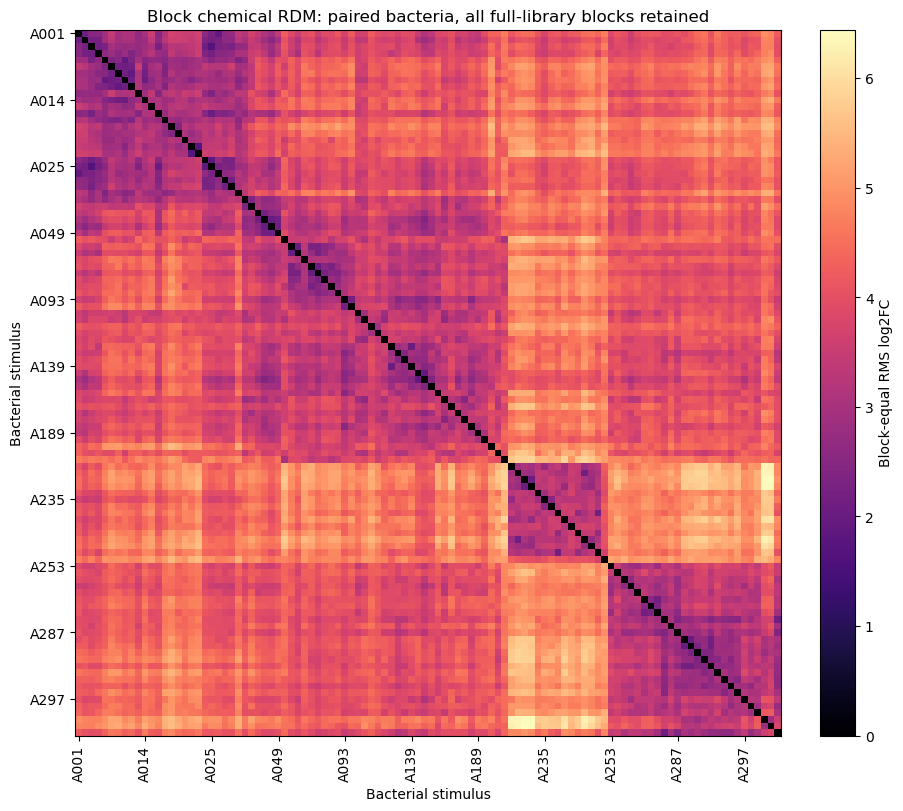

,relative_rmse,metric_mds_relative_rmse,lambda_value,lambda_fitted,shared_sigma_original,gradient_inf,converged,gradient_checks_passed
dimension,,,,,,,,
2,0.087586,0.304917,10.000000,False,0.255185,2.436668e-07,True,True
3,0.047107,0.218484,9.994939,True,0.137249,2.828272e-07,True,True


relative_rmse  lambda_value  lambda_fitted  \
distance_definition     dimension                                               
Molecule-equal (cell33) 2               0.091022     10.000000          False   
                        3               0.047831      9.429473           True   
Block-equal (cell38)    2               0.087586     10.000000          False   
                        3               0.047107      9.994939           True   

                                   converged  gradient_checks_passed  
distance_definition     dimension                                     
Molecule-equal (cell33) 2               True                    True  
                        3               True                    True  
Block-equal (cell38)    2               True                    True  
                        3               True                    True

比较的是各自输入 RDM 的重建误差；不能仅据此判定哪一种化学距离更正确。
六个标记组和全部其他组均保留；只改变分子权重，不重新分组。后续神经关联仍使用这 106 株配对菌。
2D lambda 固定为 10；3D lambda 自由拟合。共享 sigma 表示模型残差，不是化学测量误差。
Saved: h:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\chemical_block_hmds_20260921_193109_457215\chemical_block_hmds_result.pkl


In [73]:
# Fixed chemical reference determines color; each embedding keeps its own distances.
from pathlib import Path
import sys
import importlib
color_root = next(root for root in (Path.cwd(), Path.cwd().parent)
                  if (root / 'notebook/chemical_colors.py').is_file())
if str(color_root / 'notebook') not in sys.path:
    sys.path.insert(0, str(color_root / 'notebook'))
import chemical_colors
importlib.reload(chemical_colors)
from chemical_colors import build_chemical_colors, mpl_colors, plotly_colors, mpl_colorbar_kwargs
if 'chemical_color_mapping' not in globals() or 'scores' not in chemical_color_mapping:
    if 'chemical_rdm' not in globals():
        raise RuntimeError('Run 化学 RDM 单元 then the color setup in 二维 MDS 单元 or 化学配色单元; no neural fit is needed')
    chemical_color_mapping = build_chemical_colors(chemical_rdm)
# Reuse this frozen mapping even when plotting a different RDM or sample order.
# Run 化学配色单元 explicitly to replace the reference or colormap.

# Reconstruct the paired block-chemical RDM using ALL full-library blocks.
# Retain groups flagged by the subset check; do not refit groups or change their weights.
# HMDS matches 单分子等权化学 HMDS 单元: shared residual sigma; fixed 2D lambda; freely fitted 3D lambda.
from pathlib import Path
from datetime import datetime
import importlib
import json
import pickle
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CHEM_BLOCK_HMDS_FIXED_LAMBDA_2D = 10.0
CHEM_BLOCK_HMDS_SEED = 20260919
CHEM_BLOCK_HMDS_INITIAL_LAMBDAS = (0.5, 2.0, 5.0)
CHEM_BLOCK_HMDS_MAX_BLOCKS = 20
CHEM_BLOCK_HMDS_ITERATIONS_PER_BLOCK = 1000
CHEM_BLOCK_HMDS_GRADIENT_TOLERANCE = 1e-6

if 'chemical_block_result' not in globals() or 'paired_subset_check' not in chemical_block_result:
    raise RuntimeError('Run the full-library version of 化学共变组分析单元 first')
if 'neural_rdm' not in globals():
    raise RuntimeError('Neural sample IDs are needed to define the paired subset')
chemical_block_hmds_root = next(
    root for root in (Path.cwd(), Path.cwd().parent)
    if (root / 'notebook/03_chemical_neuron_bacteria.ipynb').is_file()
)
if str(chemical_block_hmds_root / 'notebook') not in sys.path:
    sys.path.insert(0, str(chemical_block_hmds_root / 'notebook'))
import chemical_blocks
import chemical_hmds_polar
import chemical_hmds
chemical_blocks = importlib.reload(chemical_blocks)
chemical_hmds_polar = importlib.reload(chemical_hmds_polar)
chemical_hmds = importlib.reload(chemical_hmds)

chemical_block_hmds_source = chemical_block_result
chemical_block_hmds_ids = neural_rdm.index[
    neural_rdm.index.isin(chemical_block_hmds_source['input_profiles'].index)
]
if not chemical_block_hmds_ids.equals(chemical_block_hmds_source['paired_subset_check']['rdm'].index):
    raise ValueError('Paired sample IDs changed; rerun 化学共变组分析单元 before fitting')
chemical_block_hmds_profiles = chemical_block_hmds_source['input_profiles'].loc[chemical_block_hmds_ids]
chemical_block_hmds_groups = chemical_block_hmds_source['groups'].copy()  # ALL groups, including flagged groups.
chemical_block_hmds_rdm, chemical_block_hmds_weights = chemical_blocks.equal_block_distance(
    chemical_block_hmds_profiles, chemical_block_hmds_groups,
)
if not chemical_block_hmds_weights.equals(chemical_block_hmds_source['members']['block_feature_weight']):
    raise ValueError('Weights differ from full-library discovery')
if not np.allclose(chemical_block_hmds_rdm,
                   chemical_block_hmds_source['paired_subset_check']['rdm'], rtol=1e-12, atol=1e-12):
    raise ValueError('Recomputed block RDM differs from the frozen full-library RDM submatrix')
chemical_block_hmds_rdm.attrs.update(chemical_block_hmds_source['paired_subset_check']['rdm'].attrs)
chemical_block_hmds_rdm.attrs.update(flagged_groups_retained=True,
                                     sample_scope='Paired subset; frozen full-library blocks and feature weights')
chemical_block_hmds_checks = chemical_block_hmds_source['paired_subset_check']['group_summary']
chemical_block_hmds_flagged = chemical_block_hmds_checks.loc[
    chemical_block_hmds_checks.paired_relationships_pass.eq(False).fillna(False)
].copy()
assert chemical_block_hmds_flagged.index.isin(chemical_block_hmds_groups.unique()).all()
print(f'Paired RDM: {chemical_block_hmds_rdm.shape}; '
      f'{chemical_block_hmds_profiles.shape[1]} molecules; {chemical_block_hmds_groups.nunique()} full-library blocks')
print('Retained flagged blocks:', chemical_block_hmds_flagged.index.tolist())
display(chemical_block_hmds_flagged)

# Import shared geometry directly; no historical neural fit is required.
import neural_hmds
neural_hmds = importlib.reload(neural_hmds)
chemical_block_hmds_output = chemical_block_hmds_root / 'output/jupyter-notebook' / (
    'chemical_block_hmds_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f')
)
chemical_block_hmds_bundle = chemical_hmds.fit_chemical_hmds(
    chemical_block_hmds_rdm,
    neural_hmds.hmds_geometry, neural_hmds.hmds_chart_to_ball,
    chemical_block_hmds_output, seed=CHEM_BLOCK_HMDS_SEED,
    initial_lambdas=CHEM_BLOCK_HMDS_INITIAL_LAMBDAS, max_blocks=CHEM_BLOCK_HMDS_MAX_BLOCKS,
    iterations_per_block=CHEM_BLOCK_HMDS_ITERATIONS_PER_BLOCK,
    gradient_tolerance=CHEM_BLOCK_HMDS_GRADIENT_TOLERANCE,
    fixed_lambda_2d=CHEM_BLOCK_HMDS_FIXED_LAMBDA_2D,
)
chemical_block_hmds_bundle['block_definition'] = dict(
    groups=chemical_block_hmds_groups, feature_weights=chemical_block_hmds_weights,
    discovery_parameters=chemical_block_hmds_source['parameters'].copy(),
    paired_group_checks=chemical_block_hmds_checks.copy(),
    retained_flagged_groups=chemical_block_hmds_flagged.index.tolist(),
    n_discovery_samples=len(chemical_block_hmds_source['input_profiles']),
    n_paired_samples=len(chemical_block_hmds_ids),
)
chemical_block_hmds_summary = chemical_block_hmds_bundle['summary']
# Coordinates for downstream matched analyses use the ORIGINAL neural sample order.
chemical_block_hmds_2d_coordinates = chemical_block_hmds_bundle['results'][2]['coordinates'].reindex(chemical_block_hmds_ids)
chemical_block_hmds_3d_coordinates = chemical_block_hmds_bundle['results'][3]['coordinates'].reindex(chemical_block_hmds_ids)

chemical_block_hmds_rdm.to_csv(chemical_block_hmds_output / 'paired_block_rdm.csv')
chemical_block_hmds_groups.to_csv(chemical_block_hmds_output / 'full_library_groups.csv')
chemical_block_hmds_weights.to_csv(chemical_block_hmds_output / 'full_library_feature_weights.csv')
chemical_block_hmds_flagged.to_csv(chemical_block_hmds_output / 'retained_flagged_groups.csv')
chemical_block_hmds_2d_coordinates.to_csv(chemical_block_hmds_output / 'embedding_2d_neural_order.csv')
chemical_block_hmds_3d_coordinates.to_csv(chemical_block_hmds_output / 'embedding_3d_neural_order.csv')
# Replace the generic bundle with the same fit plus its full grouping provenance.
with (chemical_block_hmds_output / 'chemical_hmds_result.pkl').open('wb') as handle:
    pickle.dump(chemical_block_hmds_bundle, handle)
with (chemical_block_hmds_output / 'chemical_block_hmds_result.pkl').open('wb') as handle:
    pickle.dump(chemical_block_hmds_bundle, handle)
for filename in ('chemical_blocks.py', 'chemical_hmds.py', 'chemical_hmds_polar.py', 'chemical_colors.py'):
    (chemical_block_hmds_output / filename.replace('.py', '_used.py')).write_bytes(
        (chemical_block_hmds_root / 'notebook' / filename).read_bytes()
    )
(chemical_block_hmds_output / 'neural_hmds_used.py').write_bytes(Path(neural_hmds.__file__).read_bytes())
# Source snapshots use the persistent cell ID, independent of notebook ordering.
chemical_block_hmds_notebook = json.loads(
    (chemical_block_hmds_root / 'notebook/03_chemical_neuron_bacteria.ipynb').read_text(encoding='utf-8')
)
chemical_block_hmds_generation_source = next(cell['source'] for cell in chemical_block_hmds_notebook['cells']
                             if cell.get('id') == '36509527')
(chemical_block_hmds_output / 'chemical_block_hmds_generation.py').write_text(
    ''.join(chemical_block_hmds_generation_source), encoding='utf-8'
)

fig_chemical_block_rdm, ax_chemical_block_rdm = plt.subplots(figsize=(9, 8), constrained_layout=True)
chemical_block_rdm_image = ax_chemical_block_rdm.imshow(chemical_block_hmds_rdm, cmap='magma', vmin=0)
chemical_block_rdm_ticks = np.arange(0, len(chemical_block_hmds_rdm), 10)
ax_chemical_block_rdm.set(xticks=chemical_block_rdm_ticks, yticks=chemical_block_rdm_ticks,
                          xticklabels=chemical_block_hmds_ids[chemical_block_rdm_ticks],
                          yticklabels=chemical_block_hmds_ids[chemical_block_rdm_ticks],
                          xlabel='Bacterial stimulus', ylabel='Bacterial stimulus',
                          title='Block chemical RDM: paired bacteria, all full-library blocks retained')
ax_chemical_block_rdm.tick_params(axis='x', labelrotation=90)
fig_chemical_block_rdm.colorbar(chemical_block_rdm_image, ax=ax_chemical_block_rdm, label='Block-equal RMS log2FC')
fig_chemical_block_rdm.savefig(chemical_block_hmds_output / 'paired_block_rdm.png', dpi=160)
plt.show()

display(chemical_block_hmds_summary[[
    'relative_rmse', 'metric_mds_relative_rmse', 'lambda_value', 'lambda_fitted',
    'shared_sigma_original', 'gradient_inf', 'converged', 'gradient_checks_passed',
]])
chemical_block_hmds_figure = chemical_hmds.plot_chemical_hmds(chemical_block_hmds_bundle, color_mapping=chemical_color_mapping)
chemical_colors.save_chemical_colors(chemical_color_mapping, chemical_block_hmds_output / 'color_reference')
for annotation in chemical_block_hmds_figure.layout.annotations:
    annotation.text = annotation.text.replace('Chemical HMDS', 'Block chemical HMDS')
for row in (1, 2):
    chemical_block_hmds_figure.update_xaxes(title_text='Observed block RMS log2FC distance', row=row, col=2)
chemical_block_hmds_figure.write_html(chemical_block_hmds_output / 'block_chemical_hmds_2d_3d.html', include_plotlyjs=True)
chemical_block_hmds_figure.write_json(chemical_block_hmds_output / 'block_chemical_hmds_2d_3d.json')
display({'application/vnd.plotly.v1+json': json.loads(chemical_block_hmds_figure.to_json())}, raw=True)

# Compare to an existing 单分子等权化学 HMDS 单元 fit only when it used the same samples and feature set.
if 'chemical_hmds_bundle' in globals():
    chemical_block_hmds_old_input = chemical_hmds_bundle['input_rdm']
    chemical_block_hmds_baseline = chemical_block_hmds_source['paired_subset_check']['baseline_rdm']
    chemical_block_hmds_matching_baseline = (
        set(chemical_block_hmds_old_input.index) == set(chemical_block_hmds_ids)
        and np.allclose(chemical_block_hmds_old_input.loc[chemical_block_hmds_ids, chemical_block_hmds_ids],
                        chemical_block_hmds_baseline, rtol=1e-10, atol=1e-12)
    )
    if chemical_block_hmds_matching_baseline:
        chemical_block_hmds_comparison = pd.concat({
            'Molecule-equal (单分子等权化学 HMDS 单元)': chemical_hmds_bundle['summary'],
            'Block-equal (组等权化学 HMDS 单元)': chemical_block_hmds_summary,
        }, names=['distance_definition', 'dimension'])[
            ['relative_rmse', 'lambda_value', 'lambda_fitted', 'converged', 'gradient_checks_passed']
        ]
        display(chemical_block_hmds_comparison)
        chemical_block_hmds_comparison.to_csv(chemical_block_hmds_output / 'molecule_vs_block_embedding_summary.csv')
        print('比较的是各自输入 RDM 的重建误差；不能仅据此判定哪一种化学距离更正确。')

print('六个标记组和全部其他组均保留；只改变分子权重，不重新分组。后续神经关联仍使用这 106 株配对菌。')
print('2D lambda 固定为 10；3D lambda 自由拟合。共享 sigma 表示模型残差，不是化学测量误差。')
if not chemical_block_hmds_summary.converged.all() or not chemical_block_hmds_summary.gradient_checks_passed.all():
    print('部分诊断未通过：相应 embedding 为暂定结果，需查看 summary.csv 和梯度检查。')
print('Saved:', chemical_block_hmds_output / 'chemical_block_hmds_result.pkl')


Observation: 由于两个RDM本身比较接近，embedding也不会有太大区别。但直接用AID作为colormap其实是失真的，数字代表的距离无法真正表示bac之间的差别，幸运的是，我们有data\16S.aln.trim.fa.treefile 16s rna sequence差异，可以将该差异表示为colormap，重新进行上述neural以及block chemical hmds嵌入，上面的cell中可以直接修改colormap

原 16S tree 配色已备份为独立 Python 脚本。
备份入口：`notebook/backup_16s_colormap_20260921_155010/generate_16s_colormap.py`；同目录保留原始 旧配色备份 和两个 helper 的快照。
当前主图配色改由 化学配色说明 描述的 chemical reference 定义；运行 化学配色单元 可生成固定颜色及 AID 对照图。
二维 MDS 单元 的配色初始化也可从 化学 RDM 单元 的 chemical_rdm 建立默认映射；之后各图复用该映射。


16S tree 的 12 个切分组是在特定切树规则下的系统发育分组，本质可以研究这些系统发育分组是否对应神经响应差异，但与我的目标即比较化学与神经表征并不相符。AID 编号或编号顺序是尚不清楚来源的人工排列 我不能说明编号中的相邻关系代表什么，不能用AID的数值或顺序作为主图的生物学颜色依据。建议由chemical定义颜色，由各自距离定义位置，即：
$$
\underbrace{D_{\mathrm{chemical}}^{\mathrm{reference}}
\longrightarrow \text{化学分组或化学轴}
\longrightarrow \text{每株菌的固定颜色}}_{\text{仅使用 chemical}}
$$

$$
\underbrace{D_{\mathrm{neural}},\ D_{\mathrm{chemical}},\ D_{\mathrm{block}}
\longrightarrow \text{各自的 MDS/HMDS 坐标}}_{\text{分别确定点的位置}}
$$
图的逻辑为先用化学数据为菌株赋予可解释的视觉标签，再观察这些标签在神经表征空间中如何分布。根据 chemical distance 生成 colormap需要明确生成规则：先化学聚类，再给每组一种颜色或者取 chemical PCo1，再映射连续颜色


,chemical_PCo1,normalized_score,color_hex
sample_id,,,
A300,-2.667374,0.000000,#30123b
A302,-2.534000,0.024682,#382568
A290,-2.391823,0.050992,#3e3891
A291,-2.346602,0.059360,#3f3e9d
A293,-2.203308,0.085878,#4350be
...,...,...,...
A226,2.579677,0.970992,#930c01
A238,2.595559,0.973931,#900b01
A232,2.673112,0.988283,#840702


Chemical PCo1: 21.9% of positive inertia
Negative inertia fraction: 0.00%


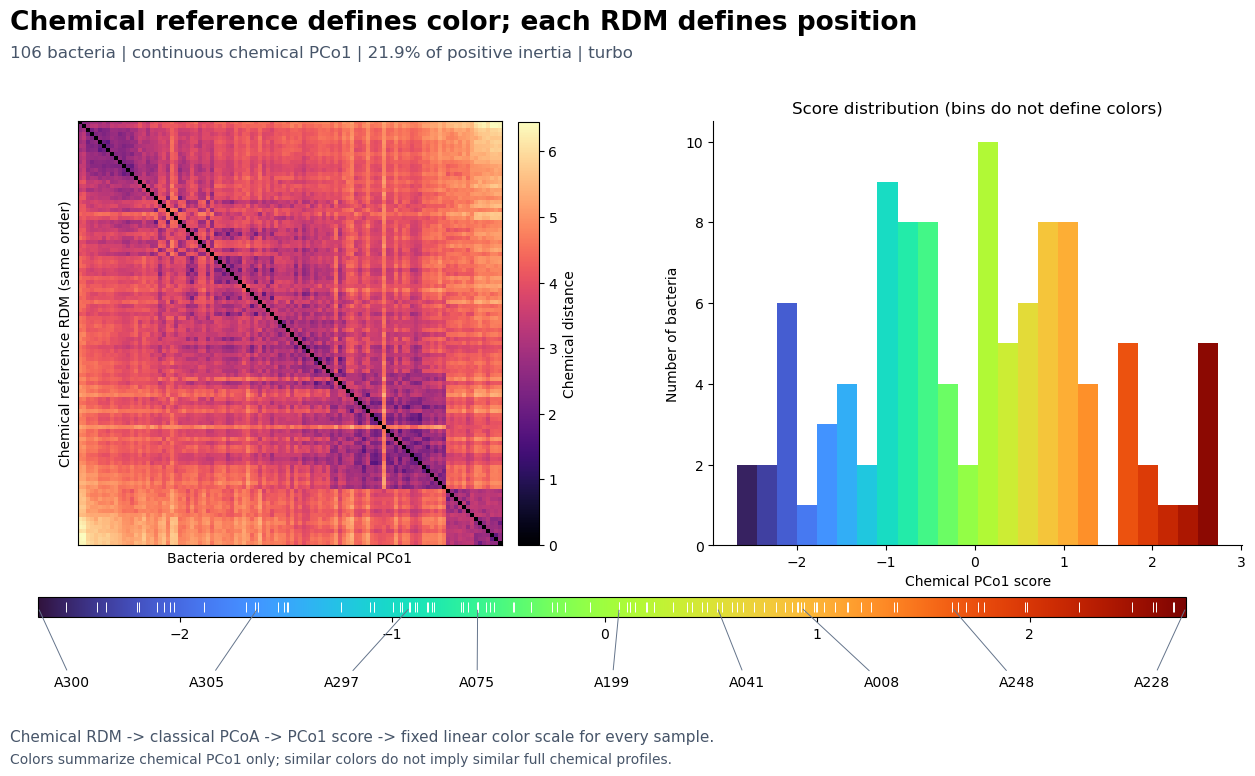

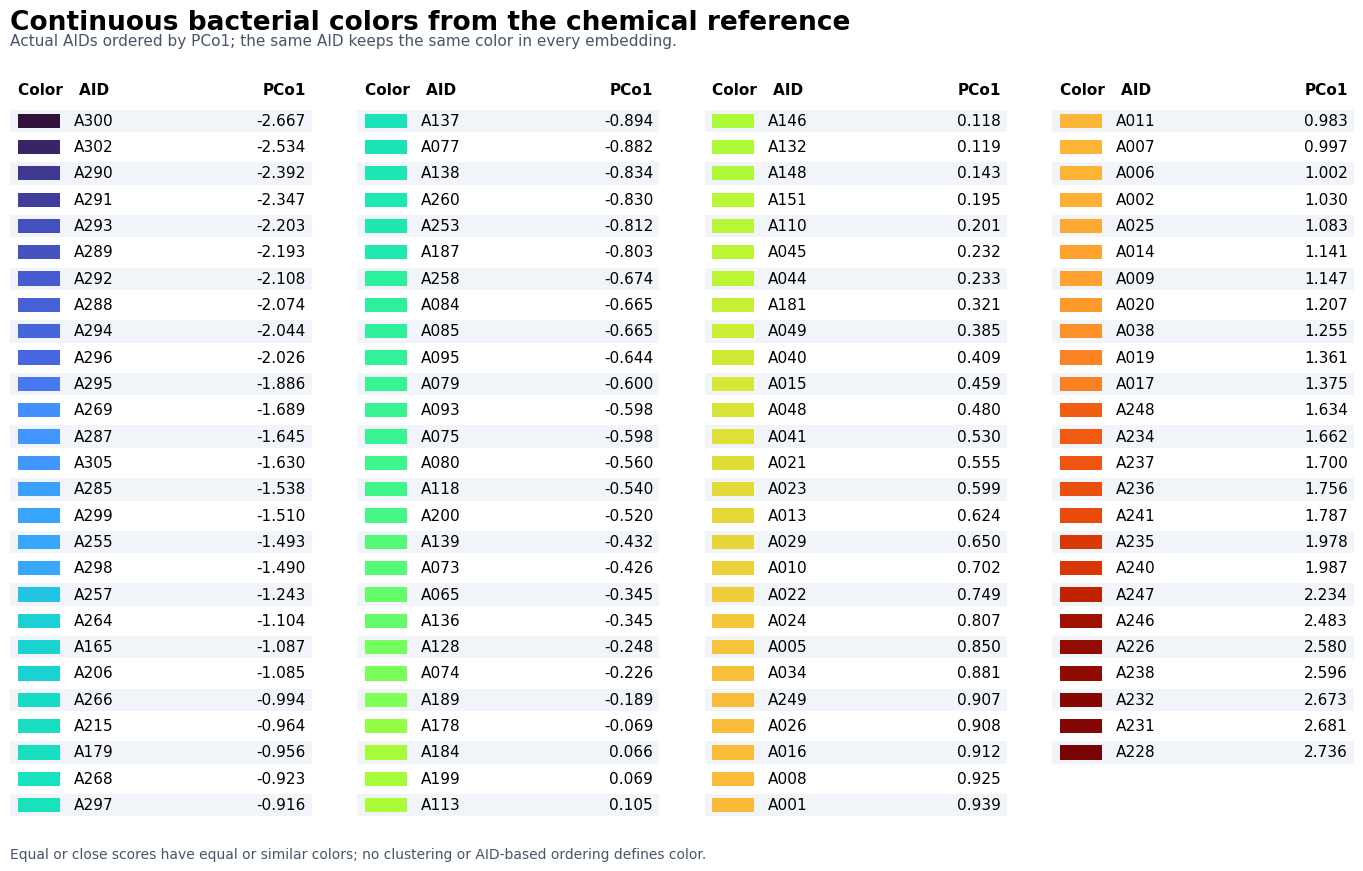

Colors summarize chemical PCo1 only; similar colors do not imply similar full chemical profiles.
Chemical reference hash: 130be07f460bd7eafa2d864e104ada6b53876557f3fbb11f23f7010e6e229d72
Feature reliability: Unverified; numerical-validity-only exploratory baseline
Chemical embedding color separation is expected by construction, not independent association evidence.
Saved: h:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\chemical_continuous_colors_20260921_193221_132407


In [74]:
# 化学配色说明: learn fixed colors from chemical data ONLY, then reuse them in all embeddings.
# This cell runs chemical PCoA and plotting only; no MDS/HMDS optimization.
from pathlib import Path
from datetime import datetime
import importlib
import sys
import matplotlib.pyplot as plt
from IPython.display import display

CHEMICAL_COLOR_CMAP = 'turbo'  # Continuous chemical PCo1 colors; no grouping.
if 'chemical_rdm' not in globals():
    raise RuntimeError('Run 化学 RDM 单元 first to define the molecule-equal chemical reference RDM')
color_root = next(root for root in (Path.cwd(), Path.cwd().parent)
                  if (root / 'notebook/chemical_colors.py').is_file())
if str(color_root / 'notebook') not in sys.path:
    sys.path.insert(0, str(color_root / 'notebook'))
import chemical_colors
import plot_chemical_colors
import chemical_hmds
importlib.reload(chemical_colors)
importlib.reload(plot_chemical_colors)
importlib.reload(chemical_hmds)
from chemical_colors import build_chemical_colors, mpl_colors, plotly_colors, mpl_colorbar_kwargs

# Explicitly replace the reference only when this cell is run.
# The function copies chemical_rdm; later edits to other RDMs cannot alter its colors.
chemical_color_mapping = build_chemical_colors(
    chemical_rdm, cmap_name=CHEMICAL_COLOR_CMAP,
    reference_name='化学 RDM 单元 molecule-equal RMS log2FC; fixed shared-bacteria reference',
)
chemical_color_figure, chemical_color_key_figure, chemical_color_members = (
    plot_chemical_colors.plot_chemical_colors(chemical_color_mapping)
)
chemical_color_output = color_root / 'output/jupyter-notebook' / (
    'chemical_continuous_colors_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f')
)
chemical_color_output.mkdir(parents=True, exist_ok=False)
chemical_colors.save_chemical_colors(chemical_color_mapping, chemical_color_output)
chemical_color_figure.savefig(chemical_color_output / 'chemical_color_reference.png', dpi=180)
chemical_color_key_figure.savefig(chemical_color_output / 'all_aid_chemical_colors.png', dpi=180)
for filename in ('chemical_colors.py', 'plot_chemical_colors.py'):
    (chemical_color_output / filename.replace('.py', '_used.py')).write_bytes(
        (color_root / 'notebook' / filename).read_bytes()
    )
display(chemical_color_members)
print(f"Chemical PCo1: {chemical_color_mapping['positive_inertia_fraction']:.1%} of positive inertia")
print(f"Negative inertia fraction: {chemical_color_mapping['negative_inertia_fraction']:.2%}")
plt.show()
print(chemical_color_mapping['note'])
print('Chemical reference hash:', chemical_color_mapping['reference_sha256'])
print('Feature reliability:', chemical_color_mapping['reference_metadata'].get('reliability', 'not recorded'))
print('Chemical embedding color separation is expected by construction, not independent association evidence.')
print('Saved:', chemical_color_output)
